#  Draft Prediction Professional Modeling Notebook

This notebook builds a full machine learning workflow for ranking draft candidates by their probability of being drafted.

The workflow is designed for three goals:

1. **Reliable validation**  
   Every fitted transformation is learned inside the training fold only. This protects the score from leakage and makes the validation result more credible.

2. **Strong ranking performance**  
   The final prediction is selected using out-of-fold evidence. The notebook compares base models, blends, rank-based strategies, and a leakage-safe meta model.

3. **Clear technical presentation**  
   The notebook includes visual diagnostics for data quality, missingness, feature behavior, model accuracy, ROC-AUC, calibration, drift, errors, feature selection, and final submission quality.

The final output is one file only:

`submission.csv`


## Executive Summary

The task is a binary ranking problem. Each player receives a probability score that represents how likely the player is to be drafted.

The final workflow uses a controlled hybrid approach:

- Raw data validation and sample-submission contract checks.
- Exploratory visuals to understand class balance, missingness, athletic measurements, and position structure.
- Feature engineering based on football logic, including body composition, speed, explosiveness, agility, workout completion, position-relative deltas, and z-scores.
- Leakage-safe preprocessing inside every validation fold.
- Repeated Stratified K-Fold validation with averaged OOF predictions.
- Multiple model families, including linear, boosting, bagging, and randomized tree models.
- OOF-only blend selection and stacking.
- Accuracy, ROC-AUC, calibration, drift, error, and submission diagnostics.




## Table of Contents

1. Project Setup and Reproducibility  
2. Data Loading  
3. Data Integrity and Sanity Checks  
4. Dataset Contract and Visual Overview  
5. Exploratory Visual Review  
6. Feature Engineering Rationale  
7. Leakage-Safe Fold Preprocessing  
8. Repeated Cross-Validation Design  
9. Level 1 Model Diagnostics  
10. Base Model Accuracy Diagnostics  
11. Leakage-Safe Stacking  
12. OOF Blend Optimization  
13. Ablation Study  
14. Stability Diagnostics  
15. Feature Selection Study  
16. Feature Explanation  
17. Train-Test Drift Analysis  
18. Calibration Diagnostics  
19. Error Analysis  
20. Final Submission  
21. Validation Safety and Score Discipline  
22. Final Decision Box  
23. Runtime Summary


## 1. Project Setup and Reproducibility

This section imports the required packages, fixes random seeds, and prints library versions.

A reproducible notebook needs controlled randomness because cross-validation, tree-based models, and ensemble optimization all include stochastic components.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import glob
import time
import math
import platform
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, roc_curve, precision_recall_curve, average_precision_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from scipy.stats import ks_2samp
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

SEED = 42
N_SPLITS = 5
N_REPEATS = 3
np.random.seed(SEED)

COLORS = {
    'blue': '#2563EB',
    'orange': '#F97316',
    'green': '#16A34A',
    'red': '#DC2626',
    'navy': '#0F172A',
    'gray': '#64748B',
    'light': '#E2E8F0',
    'purple': '#7A4CC2',
    'teal': '#0F766E',
    'yellow': '#CA8A04'
}

start_time = time.time()

version_rows = [
    ['Python', platform.python_version()],
    ['pandas', pd.__version__],
    ['numpy', np.__version__]
]

try:
    import sklearn
    version_rows.append(['scikit-learn', sklearn.__version__])
except Exception:
    pass

if HAS_LGBM:
    version_rows.append(['LightGBM', lgb.__version__])
if HAS_XGB:
    version_rows.append(['XGBoost', xgb.__version__])
if HAS_SHAP:
    version_rows.append(['SHAP', shap.__version__])

version_df = pd.DataFrame(version_rows, columns=['Package', 'Version'])
display(version_df)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#CBD5E1',
    'axes.labelcolor': '#0F172A',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.color': '#334155',
    'ytick.color': '#334155',
    'font.size': 10,
    'legend.frameon': False,
    'grid.color': '#E2E8F0',
    'grid.linewidth': 0.8
})


def style_axis(ax, title=None, xlabel=None, ylabel=None, grid_axis='x'):
    if title is not None:
        ax.set_title(title, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis=grid_axis, alpha=0.45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return ax


def annotate_horizontal_bars(ax, values, offset=0.002, fmt='{:.4f}'):
    for i, value in enumerate(values):
        ax.text(value + offset, i, fmt.format(value), va='center', fontweight='bold', color=COLORS['navy'])


def annotate_vertical_bars(ax, values, fmt='{:.4f}'):
    upper = max(values) if len(values) else 0
    offset = max(upper * 0.015, 0.002)
    for i, value in enumerate(values):
        ax.text(i, value + offset, fmt.format(value), ha='center', fontweight='bold', color=COLORS['navy'])


,Package,Version
0,Python,3.10.20
1,pandas,2.2.2
2,numpy,1.26.4
3,scikit-learn,1.4.2
4,LightGBM,4.6.0
5,XGBoost,3.2.0


## 2. Data Loading

This section loads `train.csv`, `test.csv`, and `sample_submission.csv`.

The notebook keeps the sample submission as the contract for the final file. The final output must match its columns, row count, and ID order.

In [3]:
def find_file(patterns, required=True):
    for pattern in patterns:
        matches = sorted(glob.glob(pattern))
        if matches:
            return matches[0]
    if required:
        raise FileNotFoundError(f'No file found for patterns: {patterns}')
    return None

train_path = find_file(['train.csv', 'train*.csv', '/content/train.csv', '/content/train*.csv', '/mnt/data/train*.csv', '/mnt/data/run_fullorder/train.csv'])
test_path = find_file(['test.csv', 'test*.csv', '/content/test.csv', '/content/test*.csv', '/mnt/data/test*.csv', '/mnt/data/run_fullorder/test.csv'])
sample_path = find_file(['sample_submission.csv', 'sample_submission*.csv', '/content/sample_submission.csv', '/content/sample_submission*.csv', '/mnt/data/sample_submission*.csv', '/mnt/data/run_fullorder/sample_submission.csv'])

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

TARGET = 'Drafted'
ID_COL = 'Id'

if TARGET in test.columns:
    test = test.drop(columns=[TARGET])

print(f'Train path: {train_path}')
print(f'Test path: {test_path}')
print(f'Sample submission path: {sample_path}')
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Sample submission shape: {sample_submission.shape}')

display(train.head())
display(test.head())

Train path: train.csv
Test path: test.csv
Sample submission path: sample_submission.csv
Train shape: (2781, 16)
Test shape: (696, 15)
Sample submission shape: (696, 2)


,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position
0,2781,2017,22.0,Pittsburgh,1.9558,136.077711,5.27,76.20,21.0,289.56,8.39,5.09,offense,offensive_lineman,OG
1,2782,2013,22.0,William & Mary,1.7780,83.460996,4.51,102.87,14.0,335.28,6.82,3.84,defense,defensive_back,CB
2,2783,2018,21.0,Alabama,1.8542,103.419060,4.52,101.60,14.0,327.66,NaN,4.34,offense,backs_receivers,RB
3,2784,2009,21.0,Georgia,1.8034,98.429544,4.50,90.17,25.0,292.10,6.84,4.27,offense,backs_receivers,RB
4,2785,2018,23.0,Alabama,1.8288,83.914588,4.36,80.01,13.0,302.26,6.93,4.40,defense,defensive_back,CB


### 2.1 Column Family Definition

This cell defines the numeric, categorical, workout, grouping, and target-encoding column families immediately after loading the data.

Defining these families early prevents execution-order errors and makes every later visual or modeling block use the same project contract.


In [4]:
RAW_NUMERIC_COLS = [c for c in ['Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle'] if c in train.columns]
WORKOUT_COLS = [c for c in ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle'] if c in train.columns]
CATEGORICAL_COLS = [c for c in ['School', 'Player_Type', 'Position_Type', 'Position'] if c in train.columns]
TARGET_ENCODING_COLS = [c for c in ['School', 'Position', 'Position_Type'] if c in train.columns]
GROUP_COLS = [c for c in ['Position', 'Position_Type', 'Player_Type'] if c in train.columns]

column_family_summary = pd.DataFrame({
    'Column family': ['Raw numeric', 'Workout measurements', 'Categorical', 'Target encoding candidates', 'Group statistics candidates'],
    'Columns used': [', '.join(RAW_NUMERIC_COLS), ', '.join(WORKOUT_COLS), ', '.join(CATEGORICAL_COLS), ', '.join(TARGET_ENCODING_COLS), ', '.join(GROUP_COLS)],
    'Count': [len(RAW_NUMERIC_COLS), len(WORKOUT_COLS), len(CATEGORICAL_COLS), len(TARGET_ENCODING_COLS), len(GROUP_COLS)]
})

display(column_family_summary)

,Column family,Columns used,Count
0,Raw numeric,"Year, Age, Height, Weight, Sprint_40yd, Vertic...",10
1,Workout measurements,"Sprint_40yd, Vertical_Jump, Bench_Press_Reps, ...",6
2,Categorical,"School, Player_Type, Position_Type, Position",4
3,Target encoding candidates,"School, Position, Position_Type",3
4,Group statistics candidates,"Position, Position_Type, Player_Type",3


**Insight**

The sample submission defines the required delivery shape. The modeling pipeline can become complex, but the final handoff stays simple: one probability column aligned to the test IDs.

## 3. Data Integrity and Sanity Checks

These checks run before any modeling step.

They confirm that the target is valid, IDs are unique, the sample submission matches test rows, and the final prediction contract is clear.

In [5]:
def build_check_table(train_df, test_df, sample_df):
    checks = []
    checks.append(['Target column exists in train', TARGET in train_df.columns])
    checks.append(['ID column exists in train', ID_COL in train_df.columns])
    checks.append(['ID column exists in test', ID_COL in test_df.columns])
    checks.append(['Sample contains ID column', ID_COL in sample_df.columns])
    checks.append(['Sample contains target column', TARGET in sample_df.columns])
    checks.append(['Train IDs are unique', not train_df[ID_COL].duplicated().any()])
    checks.append(['Test IDs are unique', not test_df[ID_COL].duplicated().any()])
    checks.append(['Sample row count equals test row count', len(sample_df) == len(test_df)])
    checks.append(['Train target is binary', set(train_df[TARGET].dropna().unique()).issubset({0, 1})])
    checks.append(['No duplicated full rows in train', not train_df.duplicated().any()])
    return pd.DataFrame(checks, columns=['Check', 'Passed'])

integrity_report = build_check_table(train, test, sample_submission)
display(integrity_report)

if not integrity_report['Passed'].all():
    raise ValueError('Data integrity checks failed.')

,Check,Passed
0,Target column exists in train,True
1,ID column exists in train,True
2,ID column exists in test,True
3,Sample contains ID column,True
4,Sample contains target column,True
5,Train IDs are unique,True
6,Test IDs are unique,True
7,Sample row count equals test row count,True
8,Train target is binary,True
9,No duplicated full rows in train,True


**Insight**

A strong model is not useful if the final file has the wrong shape or ID order. These checks protect the delivery before training starts.

## 4. Dataset Contract and Visual Overview

This section turns the raw file structure into a visual contract.

The goal is to check the project shape before modeling begins:

- Training rows and test rows
- Target balance
- Numeric coverage
- Categorical coverage
- Missingness intensity
- Submission contract

A strong notebook should make these checks visible, not hidden inside code.


### 4.1 Project Contract Dashboard

This visual summarizes the full modeling contract.

It confirms how many rows are available, which target rate the model learns from, and whether the submission file has the expected shape.


,Metric,Value
0,Train rows,2781.0000
1,Test rows,696.0000
2,Train columns,16.0000
3,Test columns,15.0000
4,Target positive rate,0.5602
5,Numeric input columns,10.0000
6,Categorical input columns,4.0000
7,Workout columns,6.0000
8,Sample submission rows,696.0000


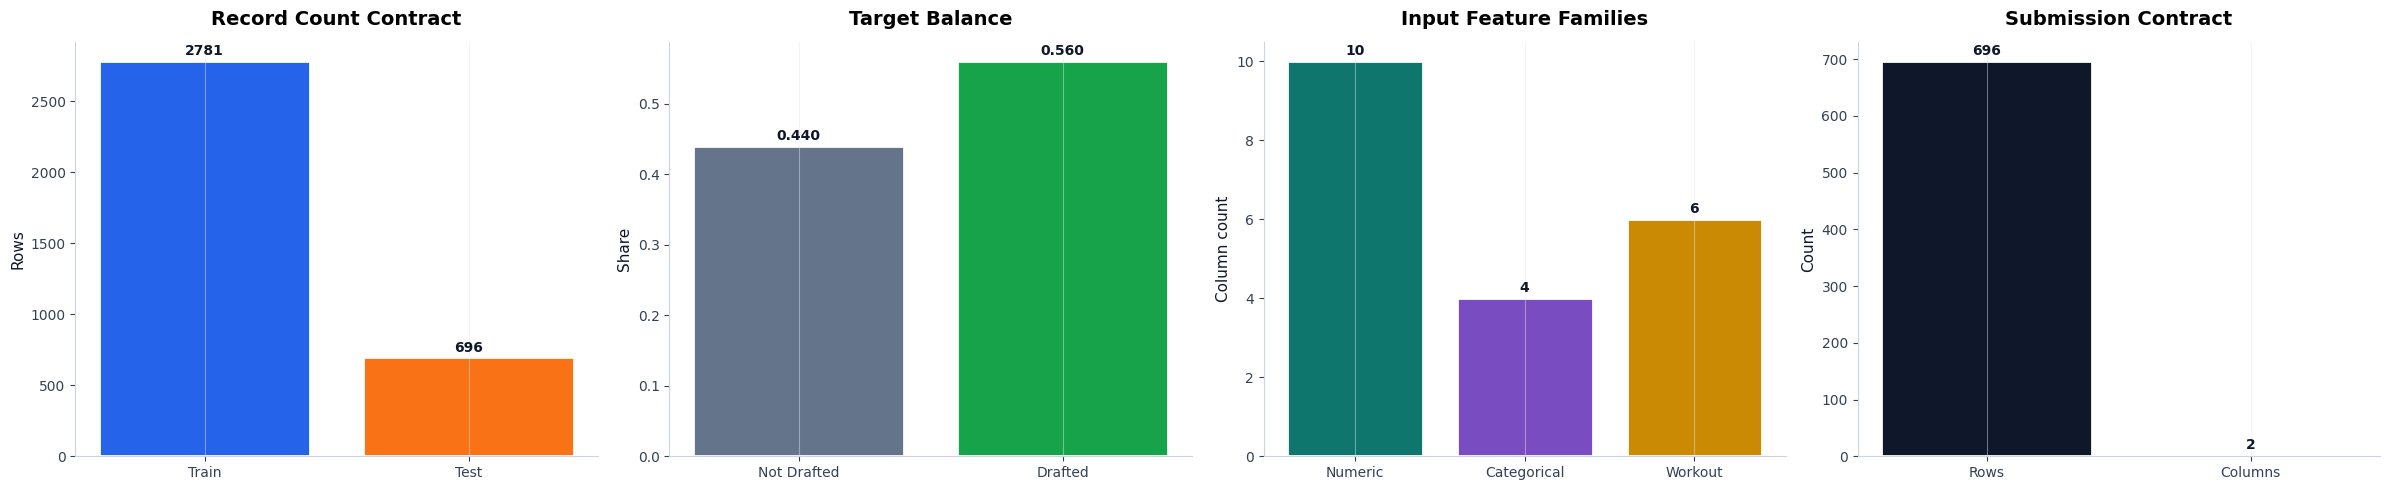

Insight: The project has a compact training set and a fixed sample-submission contract. This makes validation discipline and probability ranking more important than aggressive feature expansion.


In [6]:
contract_metrics = pd.DataFrame({
    'Metric': [
        'Train rows',
        'Test rows',
        'Train columns',
        'Test columns',
        'Target positive rate',
        'Numeric input columns',
        'Categorical input columns',
        'Workout columns',
        'Sample submission rows'
    ],
    'Value': [
        len(train),
        len(test),
        train.shape[1],
        test.shape[1],
        round(float(train[TARGET].mean()), 4),
        len(RAW_NUMERIC_COLS),
        len(CATEGORICAL_COLS),
        len(WORKOUT_COLS),
        len(sample_submission)
    ]
})

display(contract_metrics)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].bar(['Train', 'Test'], [len(train), len(test)], color=[COLORS['blue'], COLORS['orange']], edgecolor='white', linewidth=2)
style_axis(axes[0], 'Record Count Contract', ylabel='Rows')
annotate_vertical_bars(axes[0], [len(train), len(test)], fmt='{:.0f}')

balance = train[TARGET].value_counts(normalize=True).sort_index()
axes[1].bar(['Not Drafted', 'Drafted'], [balance.get(0, 0), balance.get(1, 0)], color=[COLORS['gray'], COLORS['green']], edgecolor='white', linewidth=2)
style_axis(axes[1], 'Target Balance', ylabel='Share')
annotate_vertical_bars(axes[1], [balance.get(0, 0), balance.get(1, 0)], fmt='{:.3f}')

coverage_values = [len(RAW_NUMERIC_COLS), len(CATEGORICAL_COLS), len(WORKOUT_COLS)]
axes[2].bar(['Numeric', 'Categorical', 'Workout'], coverage_values, color=[COLORS['teal'], COLORS['purple'], COLORS['yellow']], edgecolor='white', linewidth=2)
style_axis(axes[2], 'Input Feature Families', ylabel='Column count')
annotate_vertical_bars(axes[2], coverage_values, fmt='{:.0f}')

sample_contract = [len(sample_submission), sample_submission.shape[1]]
axes[3].bar(['Rows', 'Columns'], sample_contract, color=[COLORS['navy'], COLORS['red']], edgecolor='white', linewidth=2)
style_axis(axes[3], 'Submission Contract', ylabel='Count')
annotate_vertical_bars(axes[3], sample_contract, fmt='{:.0f}')

plt.tight_layout()
plt.show()

print('Insight: The project has a compact training set and a fixed sample-submission contract. This makes validation discipline and probability ranking more important than aggressive feature expansion.')


,Feature Type,Count,Share
0,Numeric,10,66.7
1,Categorical,4,26.7
2,Identifier,1,6.7


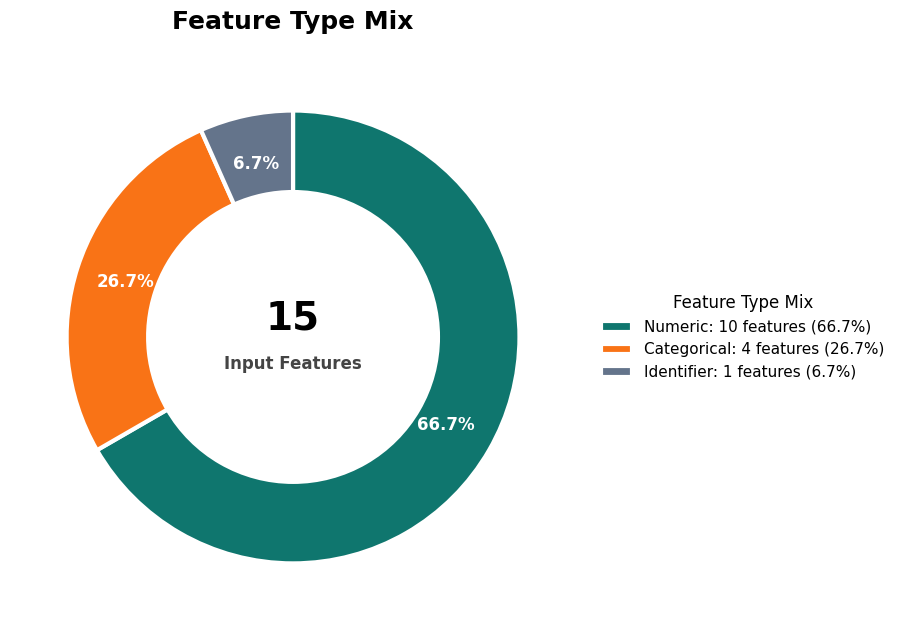

Insight: Identifier columns are separated from numeric features, so the feature mix now reflects the real modeling inputs without double-counting Id.


In [7]:
if 'TARGET' not in globals():
    TARGET = 'Drafted'

plot_colors = {
    'Numeric': COLORS.get('teal', '#3AA6B9'),
    'Categorical': COLORS.get('orange', '#F25F3A'),
    'Identifier': COLORS.get('gray', '#7A828A')
}

identifier_cols = [c for c in ['Id'] if c in train.columns]
excluded_cols = [TARGET] + identifier_cols

feature_cols = [c for c in train.columns if c not in excluded_cols]

numeric_cols_mix = train[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_cols_mix = train[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

feature_counts = pd.Series({
    'Numeric': len(numeric_cols_mix),
    'Categorical': len(categorical_cols_mix),
    'Identifier': len(identifier_cols)
})

feature_counts = feature_counts[feature_counts > 0]
total_features = int(feature_counts.sum())

feature_mix_table = pd.DataFrame({
    'Feature Type': feature_counts.index,
    'Count': feature_counts.values,
    'Share': (feature_counts.values / total_features * 100).round(1)
})

display(feature_mix_table)

fig, ax = plt.subplots(figsize=(8.5, 7))

wedges, texts, autotexts = ax.pie(
    feature_counts.values,
    labels=None,
    startangle=90,
    counterclock=False,
    autopct=lambda pct: f'{pct:.1f}%',
    pctdistance=0.78,
    colors=[plot_colors[label] for label in feature_counts.index],
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 3,
        'width': 0.36
    }
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.text(
    0,
    0.08,
    f'{total_features}',
    ha='center',
    va='center',
    fontsize=28,
    fontweight='bold'
)

ax.text(
    0,
    -0.12,
    'Input Features',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    color='#444444'
)

legend_labels = [
    f'{feature_type}: {count} features ({share:.1f}%)'
    for feature_type, count, share in zip(
        feature_mix_table['Feature Type'],
        feature_mix_table['Count'],
        feature_mix_table['Share']
    )
]

ax.legend(
    wedges,
    legend_labels,
    title='Feature Type Mix',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Feature Type Mix',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.tight_layout()
plt.show()

print('Insight: Identifier columns are separated from numeric features, so the feature mix now reflects the real modeling inputs without double-counting Id.')

### 4.2 Target Rate by Football Context

The target rate can vary by role and position group.

This visual checks whether context variables carry signal before any complex modeling begins.


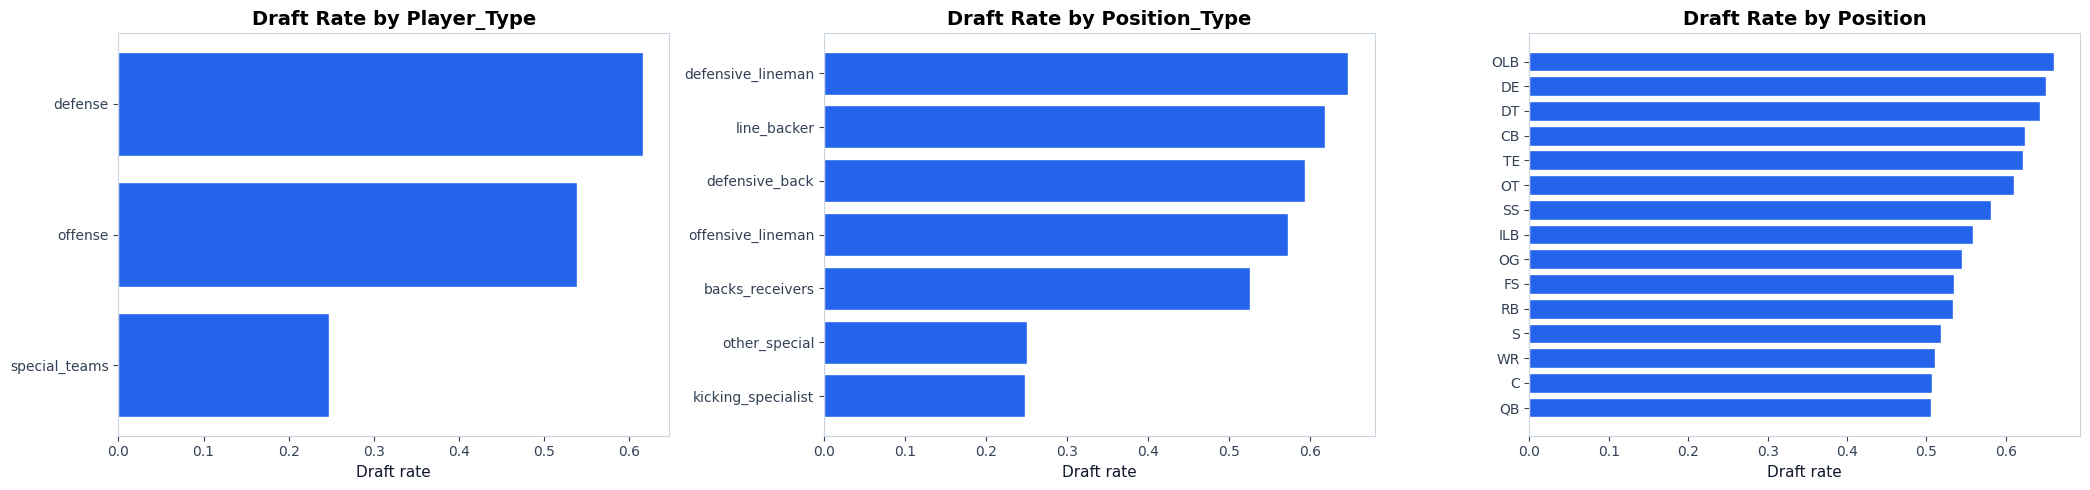

Insight: Context variables are useful when they describe a football role. They should be handled with fold-safe frequency encoding and optional OOF target encoding, not with raw ID-like memorization.


In [8]:
context_cols = [c for c in ['Player_Type', 'Position_Type', 'Position'] if c in train.columns]
fig, axes = plt.subplots(1, len(context_cols), figsize=(7 * len(context_cols), 5))
if len(context_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, context_cols):
    tmp = train.groupby(col)[TARGET].agg(['mean', 'count']).reset_index()
    tmp = tmp[tmp['count'] >= 10].sort_values('mean', ascending=False).head(15)
    ax.barh(tmp[col][::-1], tmp['mean'][::-1], color=COLORS['blue'], edgecolor='white')
    ax.set_title(f'Draft Rate by {col}')
    ax.set_xlabel('Draft rate')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Insight: Context variables are useful when they describe a football role. They should be handled with fold-safe frequency encoding and optional OOF target encoding, not with raw ID-like memorization.')


### 4.3 Missingness Signal Dashboard

Missing values in combine data can be informative.

Some players skip drills, some positions do not emphasize every test, and some records are incomplete.

This visual checks both feature-level and row-level missingness.


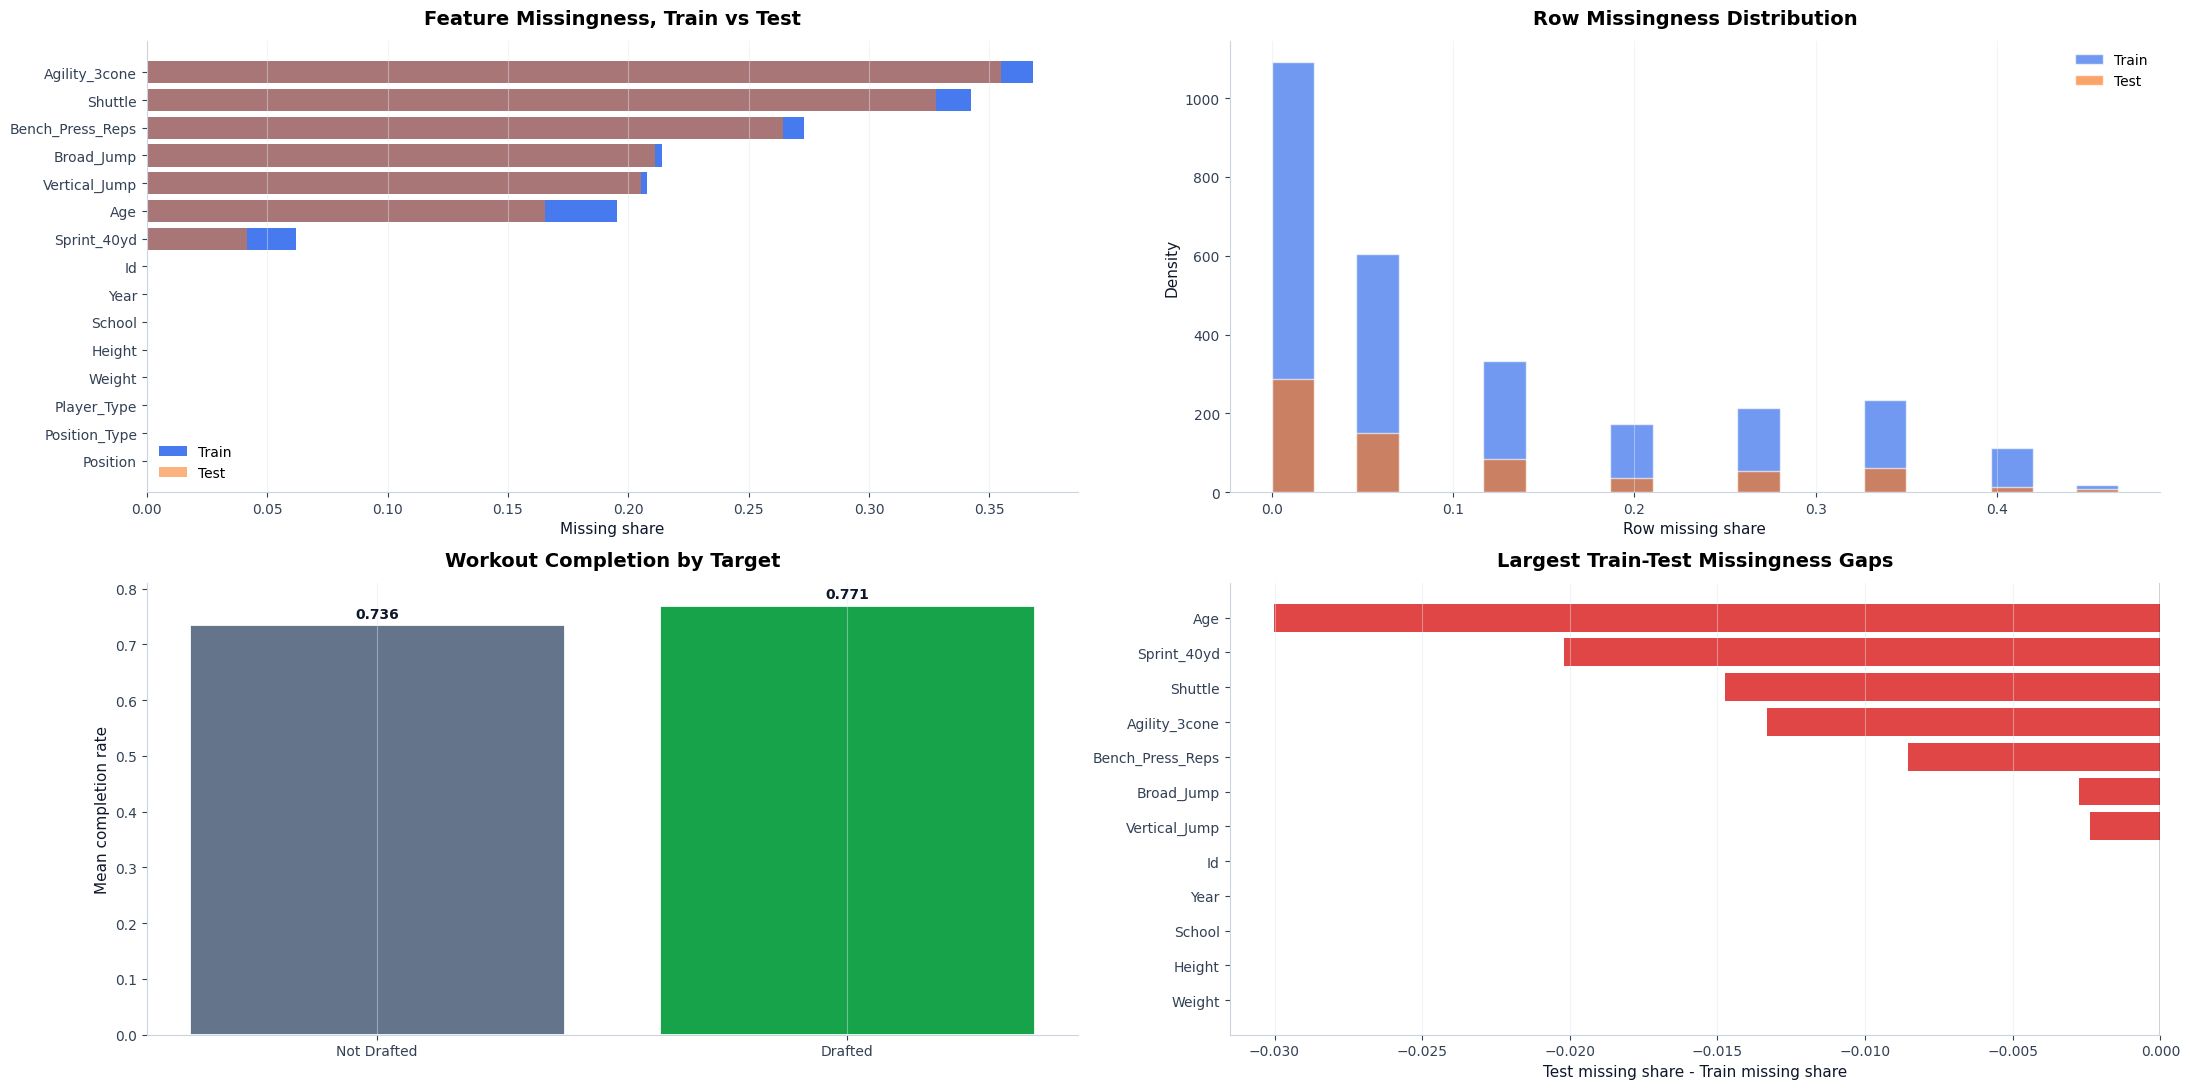

Insight: Missingness is not only a data quality issue. Workout completion can carry scouting signal, and train-test missingness gaps highlight where fold-safe indicators and imputation are necessary.


In [9]:
feature_train = train.drop(columns=[TARGET]).copy()
feature_test = test.copy()
missing_train = feature_train.isna().mean().sort_values(ascending=False)
missing_test = feature_test.isna().mean().reindex(missing_train.index).fillna(0)
missing_compare = pd.DataFrame({'Train': missing_train, 'Test': missing_test}).reset_index().rename(columns={'index': 'Feature'})

row_missing_train = feature_train.isna().mean(axis=1)
row_missing_test = feature_test.isna().mean(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(22, 11))

axes[0, 0].barh(missing_compare['Feature'][::-1], missing_compare['Train'][::-1], color=COLORS['blue'], alpha=0.85, label='Train')
axes[0, 0].barh(missing_compare['Feature'][::-1], missing_compare['Test'][::-1], color=COLORS['orange'], alpha=0.55, label='Test')
style_axis(axes[0, 0], 'Feature Missingness, Train vs Test', xlabel='Missing share', grid_axis='x')
axes[0, 0].legend()

axes[0, 1].hist(row_missing_train, bins=20, alpha=0.65, color=COLORS['blue'], label='Train', edgecolor='white')
axes[0, 1].hist(row_missing_test, bins=20, alpha=0.65, color=COLORS['orange'], label='Test', edgecolor='white')
style_axis(axes[0, 1], 'Row Missingness Distribution', xlabel='Row missing share', ylabel='Density')
axes[0, 1].legend()

if len(WORKOUT_COLS) > 0:
    workout_completion = train[WORKOUT_COLS].notna().mean(axis=1)
else:
    workout_completion = pd.Series(0, index=train.index)

completion_by_target = train.assign(Workout_Completion=workout_completion).groupby(TARGET)['Workout_Completion'].mean()
axes[1, 0].bar(['Not Drafted', 'Drafted'], [completion_by_target.get(0, 0), completion_by_target.get(1, 0)], color=[COLORS['gray'], COLORS['green']], edgecolor='white', linewidth=2)
style_axis(axes[1, 0], 'Workout Completion by Target', ylabel='Mean completion rate')
annotate_vertical_bars(axes[1, 0], [completion_by_target.get(0, 0), completion_by_target.get(1, 0)], fmt='{:.3f}')

missing_gap = (missing_compare['Test'] - missing_compare['Train']).abs().sort_values(ascending=False)
gap_features = missing_compare.loc[missing_gap.index].head(12)
axes[1, 1].barh(gap_features['Feature'][::-1], (gap_features['Test'] - gap_features['Train'])[::-1], color=COLORS['red'], alpha=0.85)
style_axis(axes[1, 1], 'Largest Train-Test Missingness Gaps', xlabel='Test missing share - Train missing share', grid_axis='x')
axes[1, 1].axvline(0, color=COLORS['navy'], linewidth=1)

plt.tight_layout()
plt.show()

print('Insight: Missingness is not only a data quality issue. Workout completion can carry scouting signal, and train-test missingness gaps highlight where fold-safe indicators and imputation are necessary.')


## 5. Exploratory Visual Review

This section gives a visual understanding of the data before modeling.

The goal is not only presentation. Each chart is used to make a practical modeling decision: how to handle imbalance, missing values, drift, feature scaling, and position-specific patterns.

### 5.1 Dataset Size and Target Balance

This visualization shows the number of rows in train and test, then shows the target distribution inside train.

Class balance matters because ROC-AUC is less sensitive to the decision threshold, but model calibration and final ranking can still be affected by the positive rate.

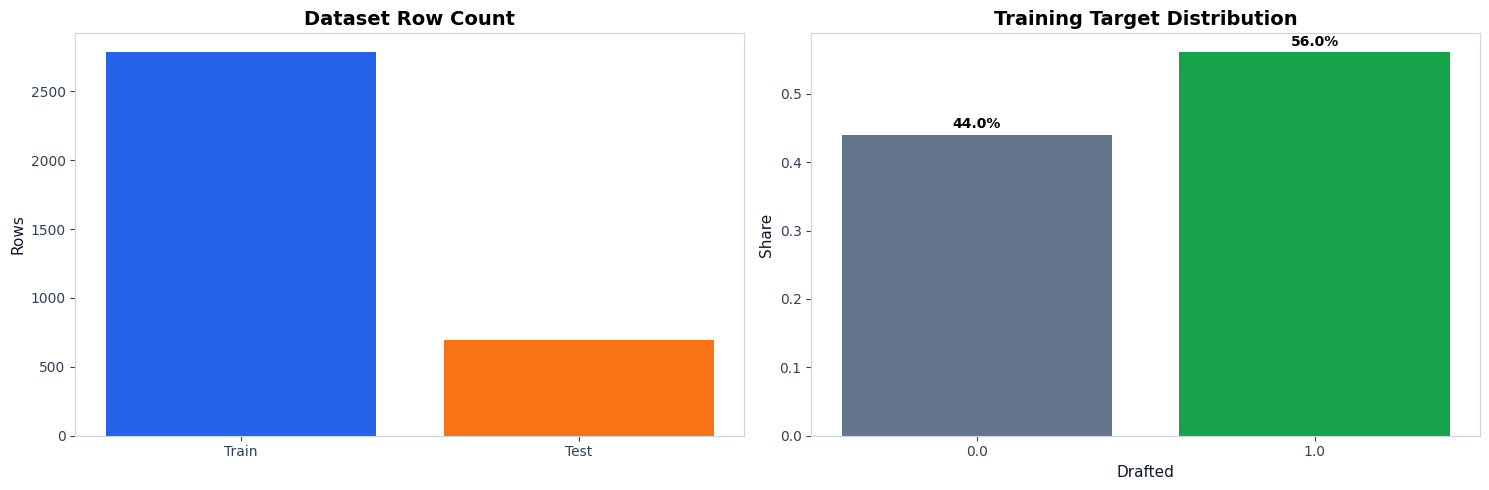

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(['Train', 'Test'], [len(train), len(test)], color=[COLORS['blue'], COLORS['orange']])
axes[0].set_title('Dataset Row Count')
axes[0].set_ylabel('Rows')

balance = train[TARGET].value_counts(normalize=True).sort_index()
axes[1].bar(balance.index.astype(str), balance.values, color=[COLORS['gray'], COLORS['green']])
axes[1].set_title('Training Target Distribution')
axes[1].set_xlabel('Drafted')
axes[1].set_ylabel('Share')
for i, v in enumerate(balance.values):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight**

The test set is smaller than the train set, so each test prediction has high impact. The target distribution sets a useful reference for calibration, but the final ROC-AUC score mainly depends on whether stronger draft candidates receive higher probabilities.

### 5.2 Missing Values by Feature

This chart shows where the data is incomplete.

Missingness is treated as signal because missing combine metrics can reflect which players attended or skipped specific tests.

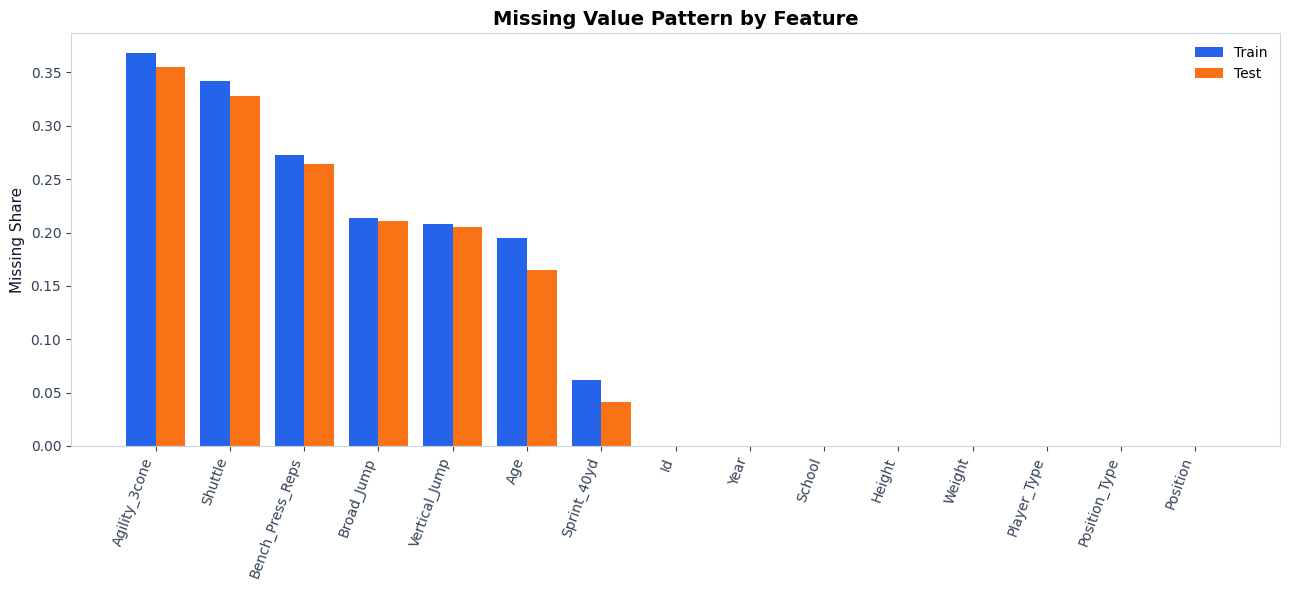

In [11]:
missing_train = train.drop(columns=[TARGET]).isna().mean().sort_values(ascending=False)
missing_test = test.isna().mean().reindex(missing_train.index)
missing_df = pd.DataFrame({'Train': missing_train, 'Test': missing_test}).fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(missing_df))
width = 0.4
ax.bar(x - width / 2, missing_df['Train'], width, label='Train', color=COLORS['blue'])
ax.bar(x + width / 2, missing_df['Test'], width, label='Test', color=COLORS['orange'])
ax.set_xticks(x)
ax.set_xticklabels(missing_df.index, rotation=70, ha='right')
ax.set_ylabel('Missing Share')
ax.set_title('Missing Value Pattern by Feature')
ax.legend()
plt.tight_layout()
plt.show()

**Insight**

Missing values are not removed. The pipeline creates missing indicators and fits imputation inside each fold so validation rows never influence the imputation model.

### 5.3 Numeric Feature Distribution Alignment

This plot compares train and test distributions for the main athletic measurements.

Large distribution differences can reduce public score because the model learns from one population and predicts on another.

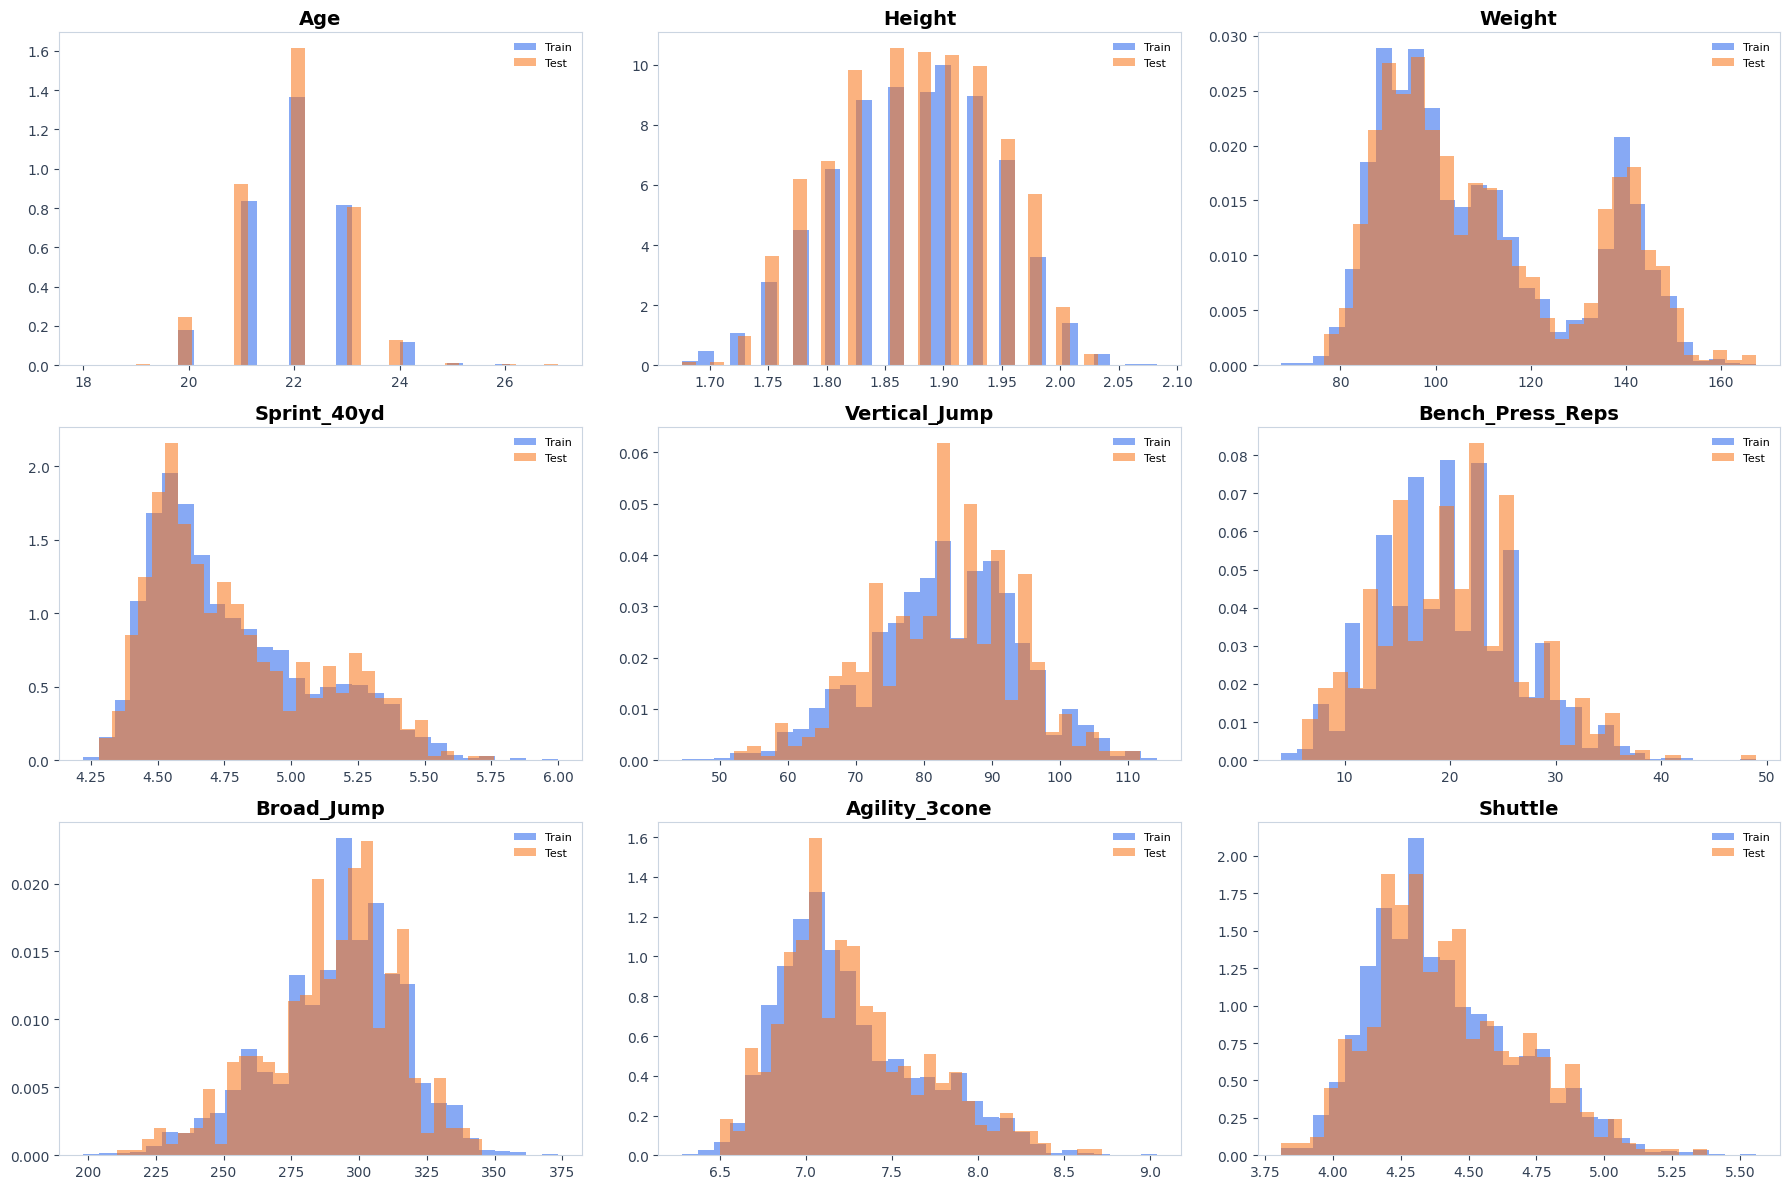

In [12]:
key_numeric_preview = ['Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']
key_numeric_preview = [c for c in key_numeric_preview if c in train.columns and c in test.columns]

rows = math.ceil(len(key_numeric_preview) / 3)
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(key_numeric_preview):
    axes[i].hist(train[col].dropna(), bins=30, alpha=0.55, density=True, color=COLORS['blue'], label='Train')
    axes[i].hist(test[col].dropna(), bins=30, alpha=0.55, density=True, color=COLORS['orange'], label='Test')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Insight**

The model needs fold-safe distribution-aware features such as ranks, group-relative deltas, and z-scores. These features reduce dependence on raw scales and help the test rows land in a comparable representation.

### 5.4 Position and Position Type Coverage

This view checks how players are distributed across positions.

Position is central because a good sprint time for an offensive lineman does not mean the same thing as the same sprint time for a wide receiver.

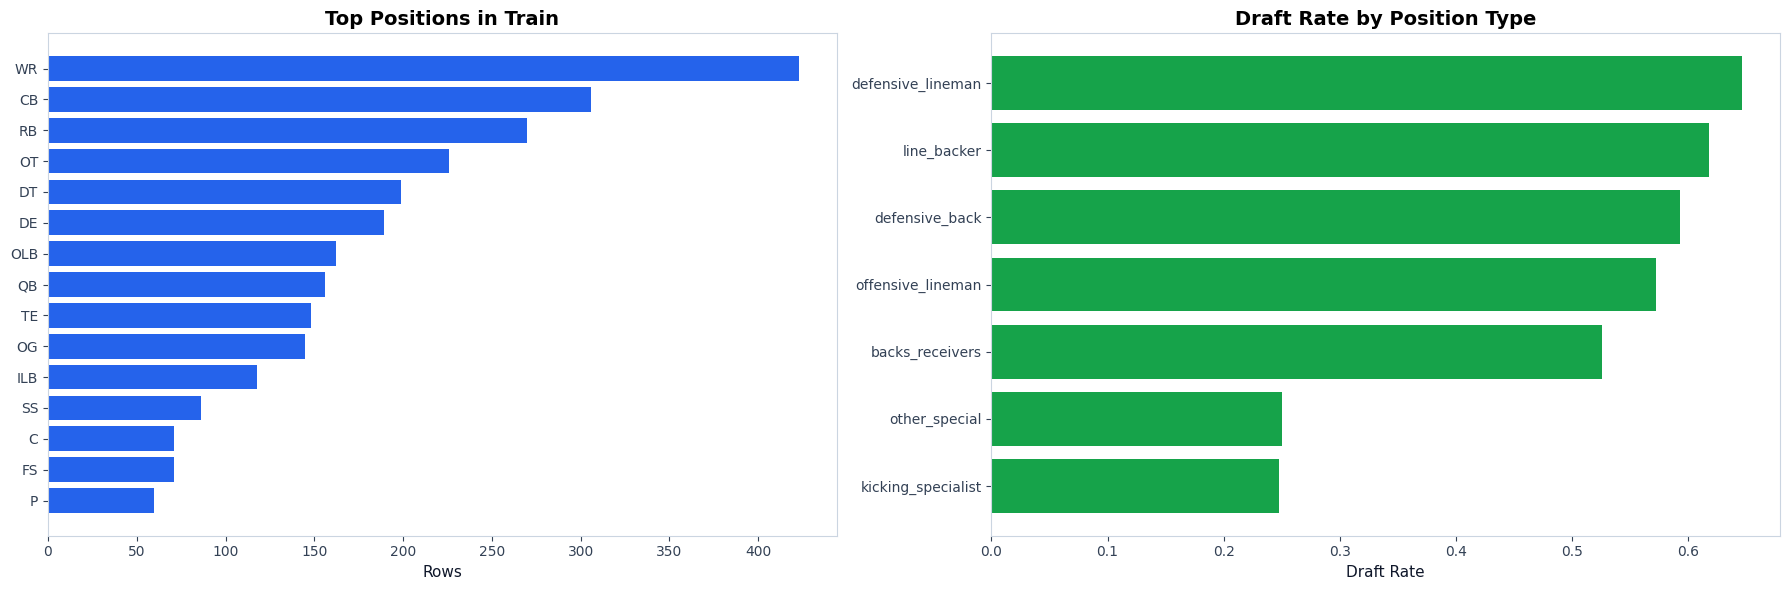

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

position_counts = train['Position'].value_counts().head(15)
axes[0].barh(position_counts.index[::-1], position_counts.values[::-1], color=COLORS['blue'])
axes[0].set_title('Top Positions in Train')
axes[0].set_xlabel('Rows')

if 'Position_Type' in train.columns:
    pos_type_rate = train.groupby('Position_Type')[TARGET].mean().sort_values()
    axes[1].barh(pos_type_rate.index, pos_type_rate.values, color=COLORS['green'])
    axes[1].set_title('Draft Rate by Position Type')
    axes[1].set_xlabel('Draft Rate')

plt.tight_layout()
plt.show()

**Insight**

Position-aware modeling is required. The notebook therefore creates fold-safe position medians, position z-scores, and position deltas inside each training fold.

### 5.5 Athletic Profile Map

This visualization creates a simple two-dimensional view of speed and power.

It helps explain why composite features are useful. Draft potential is often a combined signal, not one isolated measurement.

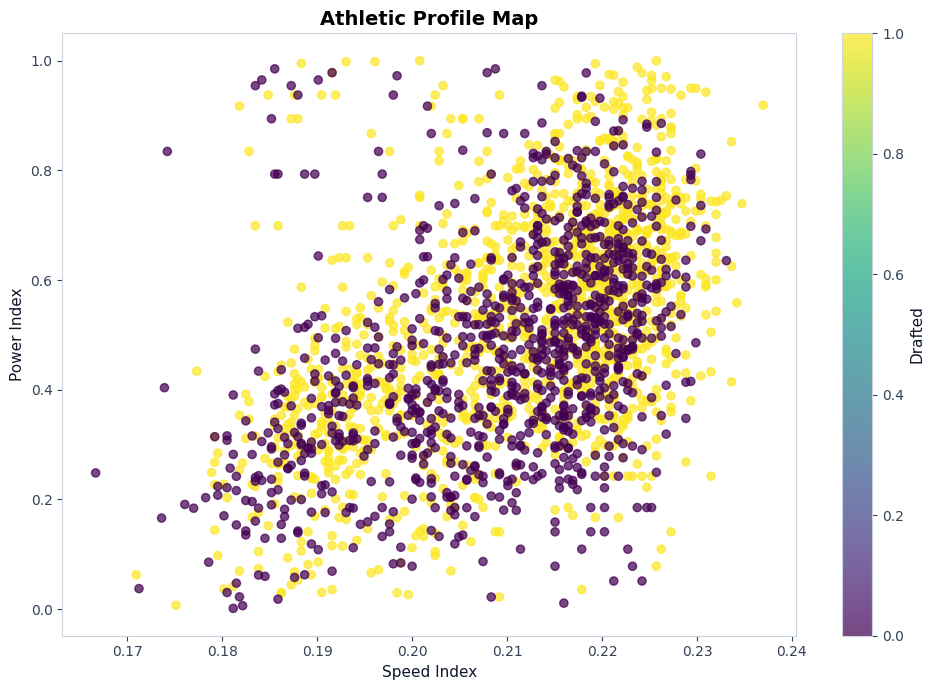

In [14]:
preview = train.copy()
preview['BMI_preview'] = preview['Weight'] / (preview['Height'] ** 2)
preview['Speed_Index_preview'] = 1 / preview['Sprint_40yd']
preview['Power_Index_preview'] = preview[['Vertical_Jump', 'Broad_Jump', 'Bench_Press_Reps']].rank(pct=True).mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    preview['Speed_Index_preview'],
    preview['Power_Index_preview'],
    c=preview[TARGET],
    cmap='viridis',
    alpha=0.72,
    s=35
)
ax.set_title('Athletic Profile Map')
ax.set_xlabel('Speed Index')
ax.set_ylabel('Power Index')
plt.colorbar(scatter, ax=ax, label='Drafted')
plt.tight_layout()
plt.show()

**Insight**

The separation is not perfect, but the drafted players tend to occupy stronger athletic zones. This supports using engineered ratios and composite metrics rather than only raw combine columns.

### 5.6 Numeric Correlation Map

This plot checks redundancy between numeric columns.

Highly correlated features can increase model instability, especially when the train set is not large.

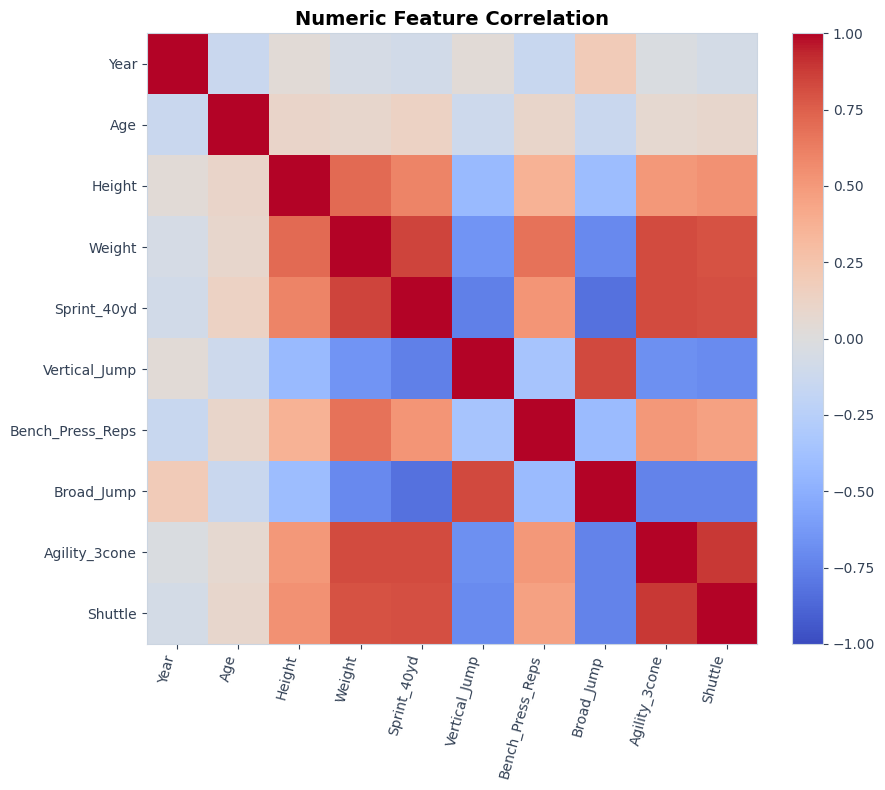

In [15]:
numeric_corr_cols = [c for c in train.select_dtypes(include=np.number).columns if c not in [ID_COL, TARGET]]
corr = train[numeric_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_corr_cols)))
ax.set_yticks(range(len(numeric_corr_cols)))
ax.set_xticklabels(numeric_corr_cols, rotation=75, ha='right')
ax.set_yticklabels(numeric_corr_cols)
ax.set_title('Numeric Feature Correlation')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 5.7 Numeric Feature Distribution Grid

This grid compares key physical measurements between drafted and non-drafted players.

It helps identify whether the signal is mostly linear, threshold-based, or interaction-based.


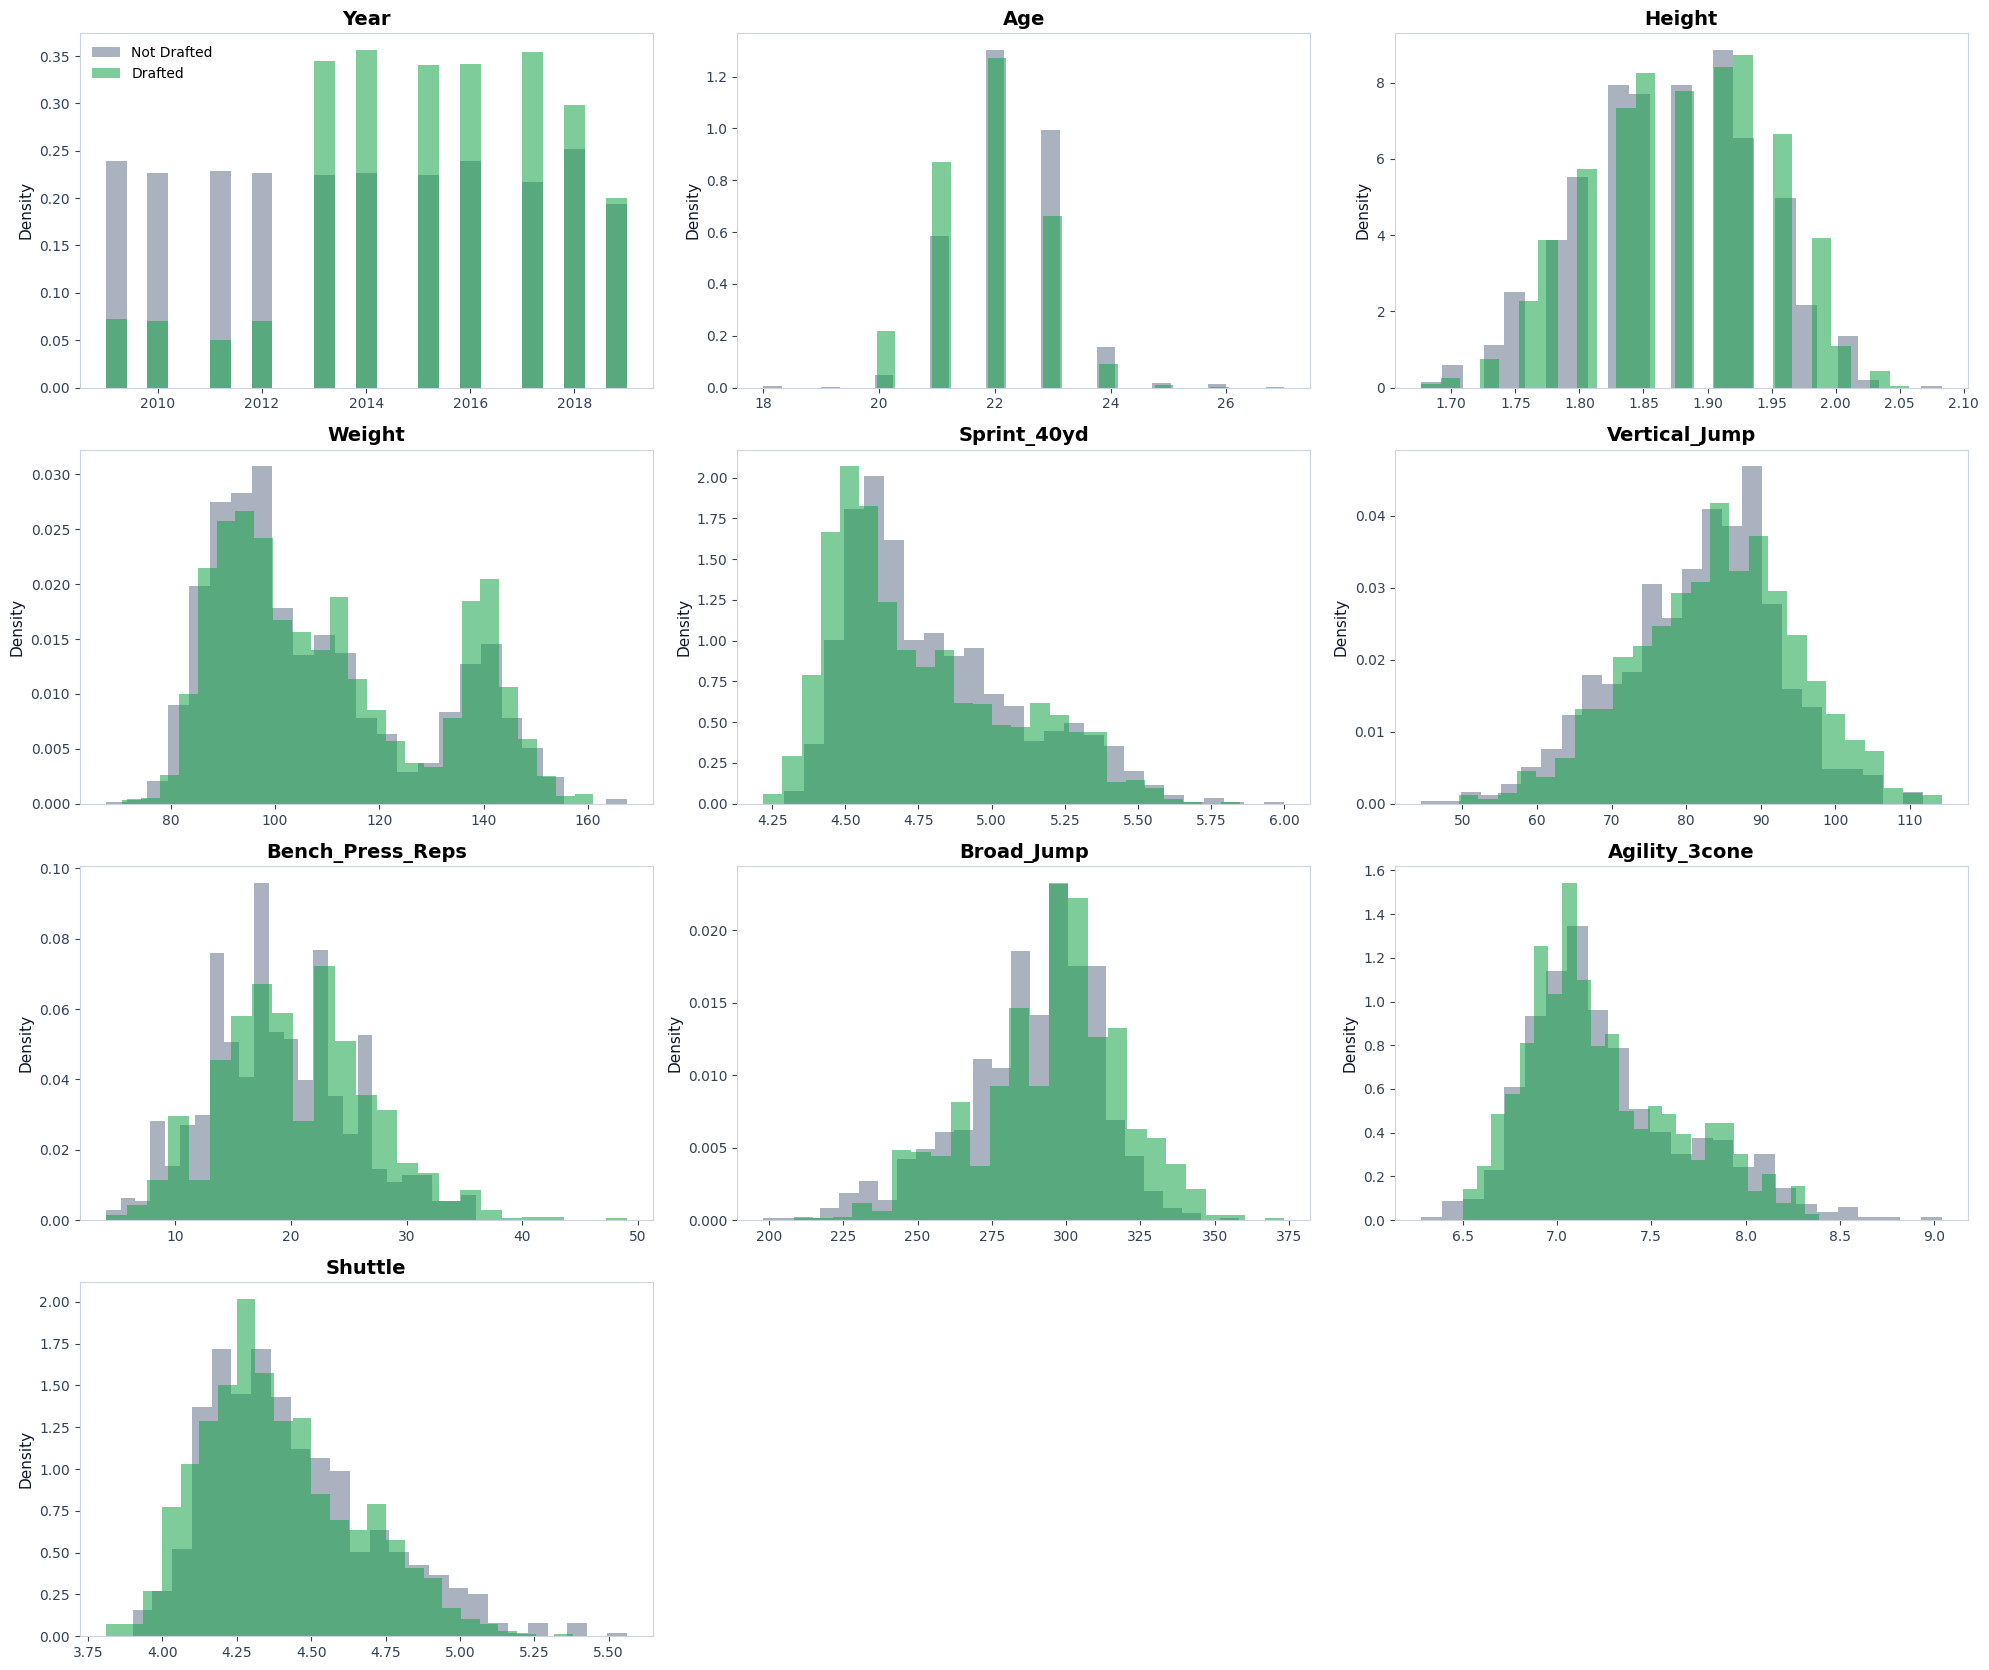

Insight: Overlapping distributions explain why a single feature is not enough. The model needs ratios, position-relative features, and calibrated blending to improve ranking quality.


In [16]:
plot_cols = [c for c in RAW_NUMERIC_COLS if c in train.columns]
cols_per_row = 3
rows = math.ceil(len(plot_cols) / cols_per_row)
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 4.2 * rows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, plot_cols):
    a = train.loc[train[TARGET] == 0, col].dropna()
    b = train.loc[train[TARGET] == 1, col].dropna()
    ax.hist(a, bins=25, alpha=0.55, density=True, color=COLORS['gray'], label='Not Drafted')
    ax.hist(b, bins=25, alpha=0.55, density=True, color=COLORS['green'], label='Drafted')
    ax.set_title(col)
    ax.set_ylabel('Density')
for ax in axes[len(plot_cols):]:
    ax.axis('off')
axes[0].legend()
plt.tight_layout()
plt.show()

print('Insight: Overlapping distributions explain why a single feature is not enough. The model needs ratios, position-relative features, and calibrated blending to improve ranking quality.')


### 5.8 Athletic Profile Radar by Target

This visual compresses the main combine tests into percentile-like profiles.

It shows whether drafted players differ as a group across speed, power, size, and agility dimensions.


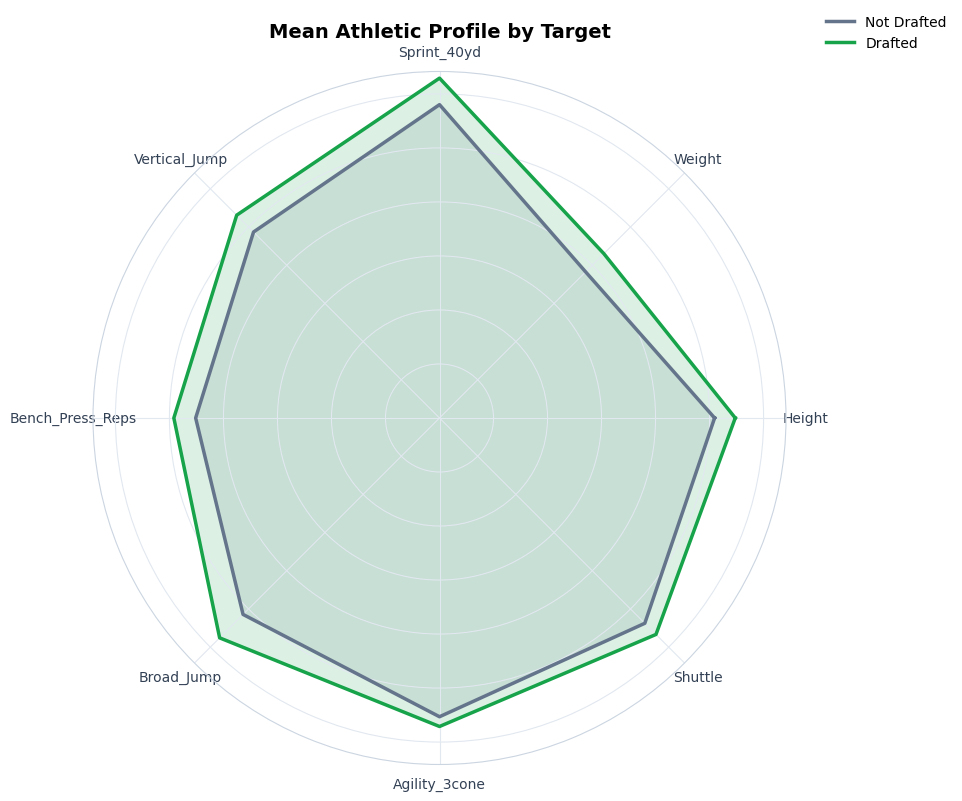

Insight: The radar view supports using role-adjusted athletic indexes instead of raw combine values alone, because performance direction differs across tests and positions.


In [17]:
profile_features = [c for c in ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle'] if c in train.columns]
profile = train[profile_features + [TARGET]].copy()
profile_scaled = profile.copy()
for col in profile_features:
    values = profile[col]
    lo = values.quantile(0.05)
    hi = values.quantile(0.95)
    profile_scaled[col] = ((values.clip(lo, hi) - lo) / (hi - lo + 1e-9)).fillna(0.5)
for col in ['Sprint_40yd', 'Agility_3cone', 'Shuttle']:
    if col in profile_scaled.columns:
        profile_scaled[col] = 1 - profile_scaled[col]
radar = profile_scaled.groupby(TARGET)[profile_features].mean()
labels = profile_features
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)
for cls, color, label in [(0, COLORS['gray'], 'Not Drafted'), (1, COLORS['green'], 'Drafted')]:
    values = radar.loc[cls].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2.5, label=label)
    ax.fill(angles, values, color=color, alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])
ax.set_title('Mean Athletic Profile by Target')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.show()

print('Insight: The radar view supports using role-adjusted athletic indexes instead of raw combine values alone, because performance direction differs across tests and positions.')


**Insight**

The final preprocessing removes highly correlated duplicates inside each fold. This keeps the feature set strong while reducing overfitting risk.

## 6. Feature Engineering Rationale

The feature set is designed to represent how scouts compare players.

- **BMI** uses `Weight / Height²` because height is measured in meters and weight is measured in kilograms.  
- **Speed indices** convert lower sprint time into higher athletic value.  
- **Power indices** combine vertical jump, broad jump, and bench press.  
- **Position z-scores** compare a player to similar players instead of comparing all positions together.  
- **Workout completion rate** captures whether a player has enough measurable combine data.  
- **Frequency encoding** helps the model learn rare and common schools or positions without high-cardinality one-hot expansion.  
- **Target encoding** is used only in an OOF-safe way and is restricted to meaningful categorical columns.

No feature is built from the player ID. ID is only used to align the final submission.

### 6.1 Core Feature Functions

This cell defines deterministic feature construction.

These features do not fit anything on the full dataset. They only transform row-level values using mathematical relationships.

In [18]:
RAW_NUMERIC_COLS = [c for c in ['Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle'] if c in train.columns]
WORKOUT_COLS = [c for c in ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle'] if c in train.columns]
CATEGORICAL_COLS = [c for c in ['School', 'Player_Type', 'Position_Type', 'Position'] if c in train.columns]
TARGET_ENCODING_COLS = [c for c in ['School', 'Position', 'Position_Type'] if c in train.columns]
GROUP_COLS = [c for c in ['Position', 'Position_Type', 'Player_Type'] if c in train.columns]


def safe_divide(a, b):
    a = pd.Series(a).astype(float)
    b = pd.Series(b).astype(float).replace(0, np.nan)
    return a / b

def clean_numeric_frame(df):
    clean = df.copy()

    for col in clean.columns:
        if clean[col].dtype == 'bool':
            clean[col] = clean[col].astype(int)

    clean = clean.replace([np.inf, -np.inf], np.nan)

    for col in clean.columns:
        if not pd.api.types.is_numeric_dtype(clean[col]):
            clean[col] = pd.to_numeric(clean[col], errors='coerce')

    clean = clean.replace([np.inf, -np.inf], np.nan)

    return clean


def add_base_features(df):
    out = df.copy()
    for col in RAW_NUMERIC_COLS:
        if col not in out.columns:
            out[col] = np.nan
    out['BMI'] = safe_divide(out['Weight'], out['Height'] ** 2)
    out['Height_Weight_Ratio'] = safe_divide(out['Height'], out['Weight'])
    out['Speed_Index'] = safe_divide(1, out['Sprint_40yd'])
    out['Agility_Index'] = safe_divide(1, out['Agility_3cone'] + out['Shuttle'])
    out['Explosiveness_Index'] = out[['Vertical_Jump', 'Broad_Jump']].mean(axis=1)
    out['Power_Mass_Index'] = safe_divide(out['Vertical_Jump'] + out['Broad_Jump'] + out['Bench_Press_Reps'], out['Weight'])
    out['Speed_Weight_Index'] = safe_divide(out['Weight'], out['Sprint_40yd'])
    out['Size_Index'] = out['Height'] * out['Weight']
    out['Burst_Score'] = safe_divide(out['Vertical_Jump'] + out['Broad_Jump'], out['Sprint_40yd'])
    out['Strength_Mass_Ratio'] = safe_divide(out['Bench_Press_Reps'], out['Weight'])
    out['Size_Speed_Balance'] = safe_divide(out['Height'] * out['Weight'], out['Sprint_40yd'])
    out['Explosive_Mass_Balance'] = safe_divide(out['Vertical_Jump'] * out['Broad_Jump'], out['Weight'])
    out['Agility_Load_Index'] = out['Weight'] * (out['Agility_3cone'] + out['Shuttle'])
    out['Age_Adjusted_Speed'] = safe_divide(out['Speed_Index'], out['Age'])
    out['Age_Adjusted_Power'] = safe_divide(out['Power_Mass_Index'], out['Age'])
    out['Age_Adjusted_Burst'] = safe_divide(out['Burst_Score'], out['Age'])
    out['Jump_Efficiency'] = safe_divide(out['Vertical_Jump'], out['Broad_Jump'])
    out['Lower_Body_Power'] = out[['Vertical_Jump', 'Broad_Jump']].prod(axis=1)
    out['Upper_Lower_Balance'] = safe_divide(out['Bench_Press_Reps'], out['Explosiveness_Index'])
    out['Workout_Completion_Rate'] = out[WORKOUT_COLS].notna().mean(axis=1) if len(WORKOUT_COLS) else 0
    out['Missing_Count'] = out[RAW_NUMERIC_COLS].isna().sum(axis=1)
    for col in RAW_NUMERIC_COLS:
        out[f'{col}_Missing'] = out[col].isna().astype(int)
    return out


### 6.2 Feature Family Map

The engineered features are grouped by football meaning.

The design avoids ID-derived variables and focuses on measurable player attributes.


,Feature family,Main reason
0,Size and body composition,NFL roles have different body profiles.
1,Speed and acceleration,Speed is a direct evaluation signal for many p...
2,Explosiveness and power,Jump and bench tests describe burst and strength.
3,Agility and change of direction,Agility separates similar athletic profiles.
4,Workout coverage,Missing drills can carry evaluation context.
5,Position-relative deltas,Raw numbers need position context.
6,Position-relative z-scores,Z-scores normalize position-specific expectati...
7,Fold-safe categorical frequency,Frequency encodes category reliability without...
8,Optional OOF target encoding,Target signal is allowed only when generated o...


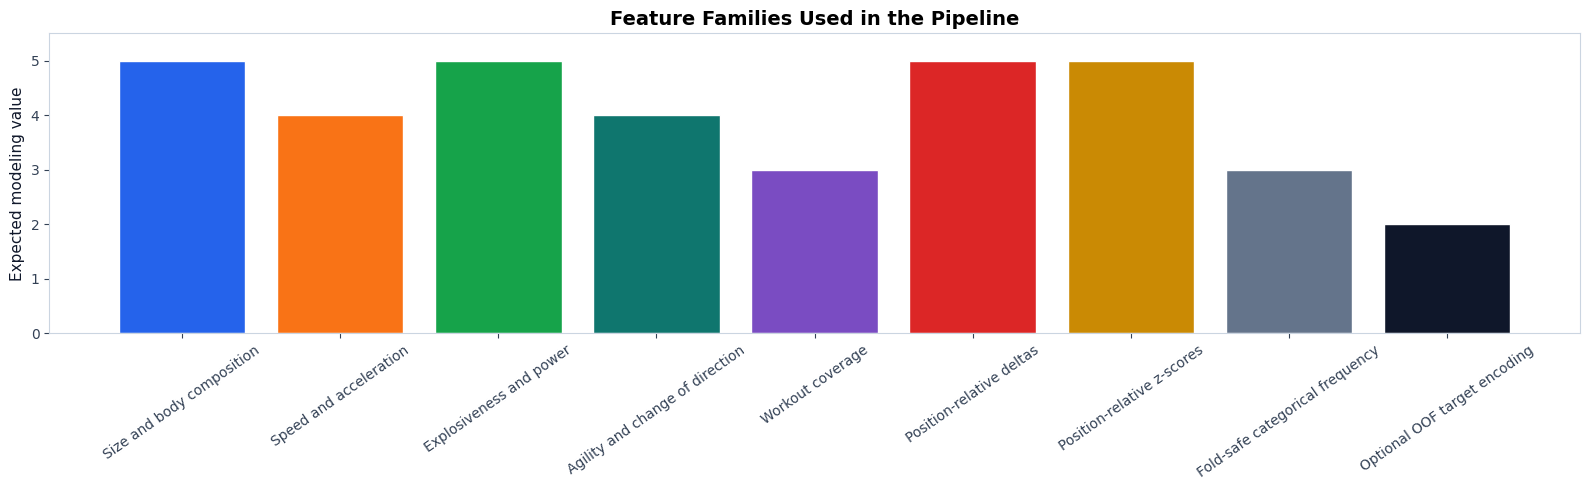

Insight: The strongest feature families are not the largest ones. Position-relative deltas and z-scores are valuable because they compare each player against the correct football context.


In [19]:
feature_family_table = pd.DataFrame({
    'Feature family': [
        'Size and body composition',
        'Speed and acceleration',
        'Explosiveness and power',
        'Agility and change of direction',
        'Workout coverage',
        'Position-relative deltas',
        'Position-relative z-scores',
        'Fold-safe categorical frequency',
        'Optional OOF target encoding'
    ],
    'Main reason': [
        'NFL roles have different body profiles.',
        'Speed is a direct evaluation signal for many positions.',
        'Jump and bench tests describe burst and strength.',
        'Agility separates similar athletic profiles.',
        'Missing drills can carry evaluation context.',
        'Raw numbers need position context.',
        'Z-scores normalize position-specific expectations.',
        'Frequency encodes category reliability without target labels.',
        'Target signal is allowed only when generated out-of-fold.'
    ]
})

display(feature_family_table)

fig, ax = plt.subplots(figsize=(16, 5))
family_strength = [5, 4, 5, 4, 3, 5, 5, 3, 2]
ax.bar(feature_family_table['Feature family'], family_strength, color=[COLORS['blue'], COLORS['orange'], COLORS['green'], COLORS['teal'], COLORS['purple'], COLORS['red'], COLORS['yellow'], COLORS['gray'], COLORS['navy']], edgecolor='white')
ax.set_title('Feature Families Used in the Pipeline')
ax.set_ylabel('Expected modeling value')
ax.set_ylim(0, 5.5)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

print('Insight: The strongest feature families are not the largest ones. Position-relative deltas and z-scores are valuable because they compare each player against the correct football context.')


### 6.3 Linear Signal Check

A strong Robust Logistic model suggests that part of the signal is approximately linear after scaling.

This visual checks whether drafted and non-drafted players separate across compact athletic indexes.


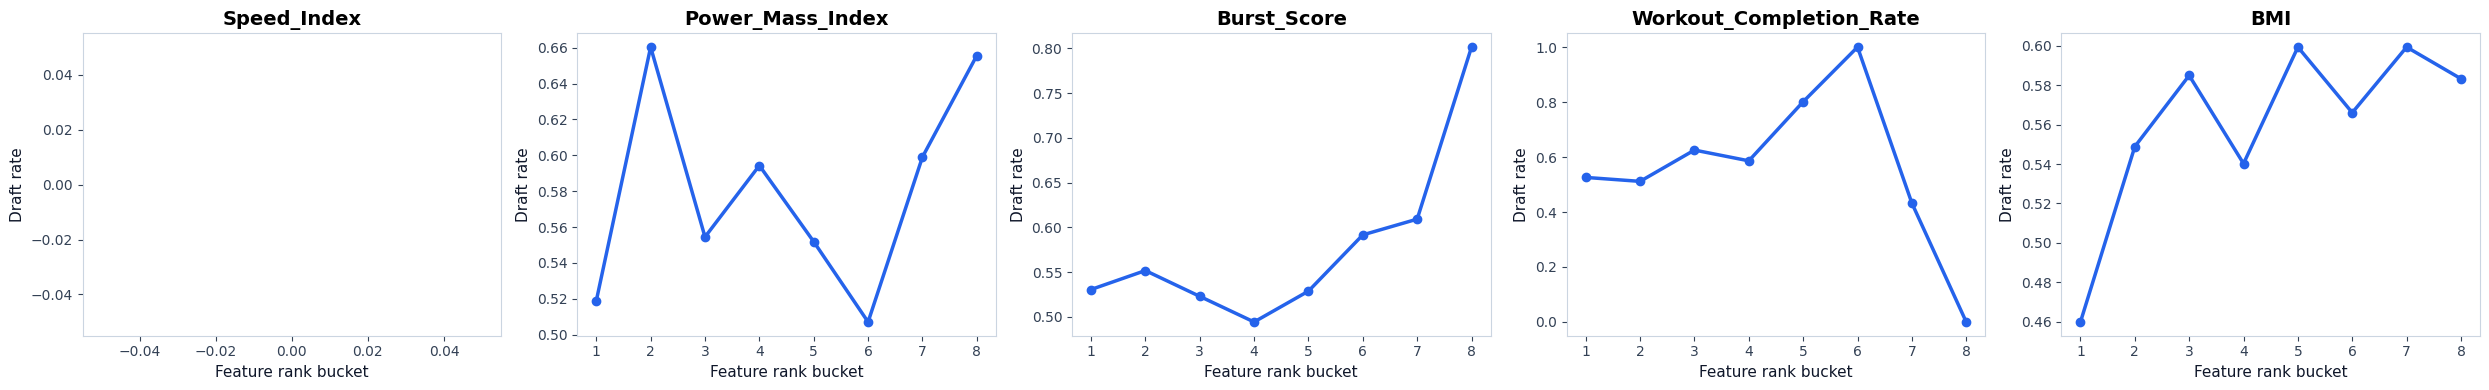

Insight: If draft rate moves consistently across rank buckets, linear models can be strong contributors. This is why the final ensemble keeps Robust Logistic and tests robust-heavy blends.


In [20]:
linear_view = add_base_features(train)
linear_cols = [c for c in ['Speed_Index', 'Power_Mass_Index', 'Burst_Score', 'Workout_Completion_Rate', 'BMI'] if c in linear_view.columns]
fig, axes = plt.subplots(1, len(linear_cols), figsize=(5 * len(linear_cols), 4))
if len(linear_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, linear_cols):
    temp = linear_view[[col, TARGET]].dropna().copy()
    if len(temp) > 0:
        bins = pd.qcut(temp[col].rank(method='first'), q=8, duplicates='drop')
        grouped = temp.groupby(bins)[TARGET].mean()
        ax.plot(range(1, len(grouped) + 1), grouped.values, marker='o', linewidth=2.5, color=COLORS['blue'])
        ax.set_title(col)
        ax.set_xlabel('Feature rank bucket')
        ax.set_ylabel('Draft rate')
plt.tight_layout()
plt.show()

print('Insight: If draft rate moves consistently across rank buckets, linear models can be strong contributors. This is why the final ensemble keeps Robust Logistic and tests robust-heavy blends.')


**Insight**

The feature logic avoids artificial identifiers. It describes athletic profile, positional context, measurement completeness, and test-year structure.

## 7. Leakage-Safe Fold Preprocessing

This is the most important technical section.

Every fitted transformation is learned from the training part of a fold only. Validation rows are transformed using statistics learned from that fold's training rows.

This protects against validation leakage from:

- KNN imputation  
- group medians  
- group means and standard deviations  
- percentile ranks  
- frequency encoding  
- target encoding  
- feature selection

### 7.1 Fold Context Fitting

This cell fits all fold-specific statistics on the training fold only.

The resulting context is then reused to transform validation and test rows.

In [21]:
def fit_fold_context(X, y=None, options=None):
    if options is None:
        options = {}
    base = add_base_features(X)
    numeric_cols = [c for c in base.select_dtypes(include=np.number).columns if c not in [ID_COL, TARGET]]
    group_cols = [c for c in GROUP_COLS if c in base.columns]
    cat_cols = [c for c in CATEGORICAL_COLS if c in base.columns]
    context = {
        'options': options,
        'numeric_cols': numeric_cols,
        'group_cols': group_cols,
        'cat_cols': cat_cols,
        'global_median': base[numeric_cols].median(numeric_only=True).to_dict(),
        'rank_values': {},
        'freq_maps': {},
        'group_medians': {},
        'group_means': {},
        'group_stds': {}
    }
    rank_cols = [c for c in numeric_cols if c not in [ID_COL]]
    for col in rank_cols:
        vals = base[col].dropna().astype(float).values
        context['rank_values'][col] = np.sort(vals)
    for col in cat_cols:
        context['freq_maps'][col] = base[col].astype(str).value_counts(normalize=True).to_dict()
    for group in group_cols:
        context['group_medians'][group] = {}
        context['group_means'][group] = {}
        context['group_stds'][group] = {}
        for col in numeric_cols:
            grouped = base.groupby(group)[col]
            context['group_medians'][group][col] = grouped.median()
            context['group_means'][group][col] = grouped.mean()
            context['group_stds'][group][col] = grouped.std().replace(0, np.nan)
    return context


def percentile_from_training_values(values, sorted_values):
    if len(sorted_values) == 0:
        return pd.Series(np.nan, index=values.index)
    arr = values.astype(float).values
    result = np.full(len(arr), np.nan)
    mask = ~np.isnan(arr)
    result[mask] = np.searchsorted(sorted_values, arr[mask], side='right') / len(sorted_values)
    return pd.Series(result, index=values.index)

### 7.2 Fold Context Transformation

This cell transforms data using the fold context.

It creates missing indicators, ranks, frequency encodings, position-relative deltas, and z-scores without looking at validation targets or validation distributions.

In [22]:
def transform_with_context(X, context):
    options = context['options']
    base = add_base_features(X)
    features = pd.DataFrame(index=base.index)
    numeric_cols = context['numeric_cols']
    for col in numeric_cols:
        if col in base.columns:
            features[col] = base[col]
        else:
            features[col] = np.nan
        if options.get('include_missing', True):
            features[f'{col}_Missing'] = base[col].isna().astype(int) if col in base.columns else 1
        if options.get('include_ranks', True):
            features[f'{col}_RankPct'] = percentile_from_training_values(base[col], context['rank_values'].get(col, np.array([]))) if col in base.columns else np.nan
    if options.get('include_frequency', True):
        for col in context['cat_cols']:
            features[f'{col}_Frequency'] = base[col].astype(str).map(context['freq_maps'][col]).fillna(0)
    if options.get('include_position_deltas', True):
        for group in context['group_cols']:
            group_values = base[group] if group in base.columns else pd.Series('', index=base.index)
            for col in numeric_cols:
                if col not in base.columns:
                    continue
                median_map = context['group_medians'][group][col]
                group_median = group_values.map(median_map).fillna(context['global_median'].get(col, np.nan))
                features[f'{col}_{group}_Delta'] = base[col] - group_median
                features[f'{col}_{group}_Ratio'] = safe_divide(base[col], group_median)
    if options.get('include_zscores', True):
        for group in context['group_cols']:
            group_values = base[group] if group in base.columns else pd.Series('', index=base.index)
            for col in numeric_cols:
                if col not in base.columns:
                    continue
                mean_map = context['group_means'][group][col]
                std_map = context['group_stds'][group][col]
                group_mean = group_values.map(mean_map).fillna(base[col].median())
                group_std = group_values.map(std_map).fillna(base[col].std()).replace(0, np.nan)
                features[f'{col}_{group}_Z'] = safe_divide(base[col] - group_mean, group_std)
    return clean_numeric_frame(features)

### 7.3 OOF Target Encoding

Target encoding can leak if the same row helps calculate its own encoded value.

This function uses inner out-of-fold encoding for training rows, then fits maps on the full outer training fold only for validation and test rows.

In [23]:
def add_oof_target_encoding(X_train_raw, y_train, X_valid_raw, X_test_raw, cat_cols, seed=SEED):
    X_train_base = add_base_features(X_train_raw).reset_index(drop=True)
    X_valid_base = add_base_features(X_valid_raw).reset_index(drop=True)
    X_test_base = add_base_features(X_test_raw).reset_index(drop=True)
    y_train = pd.Series(y_train).reset_index(drop=True)
    global_mean = y_train.mean()
    train_te = pd.DataFrame(index=X_train_base.index)
    valid_te = pd.DataFrame(index=X_valid_base.index)
    test_te = pd.DataFrame(index=X_test_base.index)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for col in [c for c in cat_cols if c in X_train_base.columns]:
        encoded = pd.Series(global_mean, index=X_train_base.index, dtype=float)
        for inner_train_idx, inner_valid_idx in inner_cv.split(X_train_base, y_train):
            map_df = pd.DataFrame({col: X_train_base.loc[inner_train_idx, col].astype(str), TARGET: y_train.loc[inner_train_idx]})
            mapping = map_df.groupby(col)[TARGET].mean()
            encoded.loc[inner_valid_idx] = X_train_base.loc[inner_valid_idx, col].astype(str).map(mapping).fillna(global_mean)
        full_map_df = pd.DataFrame({col: X_train_base[col].astype(str), TARGET: y_train})
        full_mapping = full_map_df.groupby(col)[TARGET].mean()
        train_te[f'{col}_Target_Encoded'] = encoded
        valid_te[f'{col}_Target_Encoded'] = X_valid_base[col].astype(str).map(full_mapping).fillna(global_mean) if col in X_valid_base.columns else global_mean
        test_te[f'{col}_Target_Encoded'] = X_test_base[col].astype(str).map(full_mapping).fillna(global_mean) if col in X_test_base.columns else global_mean
    return train_te, valid_te, test_te

### 7.4 Matrix Preparation Inside Each Fold

This function is called separately for every validation fold.

It fits the context, creates target encodings, removes unstable columns, removes highly correlated duplicates, fits KNN imputation, and performs fold-local feature selection.

In [24]:
def remove_correlated_columns(X_train, threshold=0.985):
    if X_train.shape[1] <= 1:
        return list(X_train.columns)
    filled = X_train.fillna(X_train.median(numeric_only=True))
    corr = filled.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [column for column in upper.columns if any(upper[column] > threshold)]
    return [c for c in X_train.columns if c not in drop_cols]


def select_fold_features(X_train, y_train, max_features, seed=SEED):
    if max_features is None or X_train.shape[1] <= max_features:
        return list(X_train.columns)
    selector = ExtraTreesClassifier(n_estimators=250, random_state=seed, n_jobs=-1, class_weight='balanced')
    selector.fit(X_train, y_train)
    importance = pd.Series(selector.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    return importance.head(max_features).index.tolist()


def prepare_fold_matrices(X_train_raw, y_train, X_valid_raw, X_test_raw, options, seed=SEED):
    context = fit_fold_context(X_train_raw, y_train, options)
    X_train_features = transform_with_context(X_train_raw, context)
    X_valid_features = transform_with_context(X_valid_raw, context)
    X_test_features = transform_with_context(X_test_raw, context)
    if options.get('include_target_encoding', False):
        train_te, valid_te, test_te = add_oof_target_encoding(X_train_raw, y_train, X_valid_raw, X_test_raw, [c for c in TARGET_ENCODING_COLS if c in X_train_raw.columns], seed)
        X_train_features = pd.concat([X_train_features.reset_index(drop=True), train_te.reset_index(drop=True)], axis=1)
        X_valid_features = pd.concat([X_valid_features.reset_index(drop=True), valid_te.reset_index(drop=True)], axis=1)
        X_test_features = pd.concat([X_test_features.reset_index(drop=True), test_te.reset_index(drop=True)], axis=1)
    valid_cols = []
    for col in X_train_features.columns:
        values = X_train_features[col]
        if values.notna().sum() > 0 and values.nunique(dropna=True) > 1:
            valid_cols.append(col)
    X_train_features = X_train_features[valid_cols]
    X_valid_features = X_valid_features[valid_cols]
    X_test_features = X_test_features[valid_cols]
    keep_cols = remove_correlated_columns(X_train_features, threshold=options.get('corr_threshold', 0.985))
    X_train_features = X_train_features[keep_cols]
    X_valid_features = X_valid_features[keep_cols]
    X_test_features = X_test_features[keep_cols]
    imputer = KNNImputer(n_neighbors=options.get('knn_neighbors', 7), weights='distance')
    X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_features), columns=keep_cols)
    X_valid_imputed = pd.DataFrame(imputer.transform(X_valid_features), columns=keep_cols)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test_features), columns=keep_cols)
    selected_cols = select_fold_features(X_train_imputed, y_train, options.get('max_features', 80), seed)
    return X_train_imputed[selected_cols], X_valid_imputed[selected_cols], X_test_imputed[selected_cols], selected_cols

**Insight**

This design fixes the main validation risk. Validation rows do not influence imputation, medians, ranks, frequency maps, target encodings, correlation removal, or feature selection.

## 8. Repeated Cross-Validation Design

The notebook uses 5 folds repeated across 3 seeds.

Each row appears in validation more than once. The correct OOF prediction is the average of all validation predictions for that row, not the last prediction written to that row.

### 8.1 Model Factory

This cell defines the level 1 models.

HistGradientBoosting is intentionally excluded because previous diagnostics showed a near-random result. The final model set keeps only models that can contribute useful ranking signal.

In [25]:
def make_models(seed=SEED):
    models = {}
    if HAS_LGBM:
        models['LightGBM'] = lgb.LGBMClassifier(
            n_estimators=950,
            learning_rate=0.018,
            num_leaves=18,
            max_depth=4,
            subsample=0.82,
            colsample_bytree=0.72,
            reg_alpha=0.35,
            reg_lambda=2.4,
            min_child_samples=34,
            random_state=seed,
            objective='binary',
            verbose=-1
        )
    if HAS_XGB:
        models['XGBoost'] = xgb.XGBClassifier(
            n_estimators=850,
            learning_rate=0.018,
            max_depth=3,
            subsample=0.88,
            colsample_bytree=0.76,
            reg_alpha=0.18,
            reg_lambda=2.2,
            min_child_weight=2.5,
            gamma=0.03,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=seed,
            n_jobs=-1
        )
    models['RandomForest'] = RandomForestClassifier(
        n_estimators=750,
        max_depth=9,
        min_samples_leaf=7,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=seed,
        n_jobs=-1
    )
    models['ExtraTrees'] = ExtraTreesClassifier(
        n_estimators=900,
        max_depth=9,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=seed,
        n_jobs=-1
    )
    models['RobustLogistic'] = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.55, penalty='l2', solver='liblinear', class_weight='balanced', random_state=seed, max_iter=6000)
    )
    return models

model_preview = pd.DataFrame({'Model': list(make_models().keys())})
display(model_preview)


,Model
0,LightGBM
1,XGBoost
2,RandomForest
3,ExtraTrees
4,RobustLogistic


**Insight**

The model set mixes boosting, bagging, extremely randomized trees, and a regularized linear model. This gives the ensemble different error patterns instead of relying on one algorithm family.

### 8.2 Leakage-Safe Level 1 Training

This cell trains every level 1 model with repeated stratified folds.

OOF predictions are accumulated and averaged for each row. This fixes the repeated-CV overwrite issue.

In [26]:
def predict_probability(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1 / (1 + np.exp(-scores))


def train_level1_repeated_cv(X_raw, y, X_test_raw, options):
    y = pd.Series(y).reset_index(drop=True)
    X_raw = X_raw.reset_index(drop=True)
    X_test_raw = X_test_raw.reset_index(drop=True)
    models = make_models(SEED)
    model_names = list(models.keys())
    oof_sum = np.zeros((len(X_raw), len(model_names)))
    oof_count = np.zeros((len(X_raw), len(model_names)))
    test_sum = np.zeros((len(X_test_raw), len(model_names)))
    fold_rows = []
    importance_rows = []
    selected_feature_rows = []
    splitter = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
    total_splits = N_SPLITS * N_REPEATS
    for fold_number, (train_idx, valid_idx) in enumerate(splitter.split(X_raw, y), start=1):
        X_train_raw = X_raw.iloc[train_idx].reset_index(drop=True)
        X_valid_raw = X_raw.iloc[valid_idx].reset_index(drop=True)
        y_train = y.iloc[train_idx].reset_index(drop=True)
        y_valid = y.iloc[valid_idx].reset_index(drop=True)
        X_train_matrix, X_valid_matrix, X_test_matrix, selected_cols = prepare_fold_matrices(X_train_raw, y_train, X_valid_raw, X_test_raw, options, SEED + fold_number)
        for feature_name in selected_cols:
            selected_feature_rows.append({'Fold': fold_number, 'Feature': feature_name})
        for model_idx, model_name in enumerate(model_names):
            model = clone(models[model_name])
            model.fit(X_train_matrix, y_train)
            valid_pred = predict_probability(model, X_valid_matrix)
            test_pred = predict_probability(model, X_test_matrix)
            oof_sum[valid_idx, model_idx] += valid_pred
            oof_count[valid_idx, model_idx] += 1
            test_sum[:, model_idx] += test_pred / total_splits
            fold_auc = roc_auc_score(y_valid, valid_pred)
            threshold_grid = np.linspace(0.05, 0.95, 181)
            accuracy_grid = [accuracy_score(y_valid, (valid_pred >= threshold).astype(int)) for threshold in threshold_grid]
            best_accuracy_index = int(np.argmax(accuracy_grid))
            best_accuracy = float(accuracy_grid[best_accuracy_index])
            best_accuracy_threshold = float(threshold_grid[best_accuracy_index])
            pred_at_best = (valid_pred >= best_accuracy_threshold).astype(int)
            fold_rows.append({
                'Fold': fold_number,
                'Model': model_name,
                'ROC_AUC': fold_auc,
                'Accuracy_At_050': accuracy_score(y_valid, (valid_pred >= 0.50).astype(int)),
                'Best_Accuracy': best_accuracy,
                'Best_Accuracy_Threshold': best_accuracy_threshold,
                'Precision_At_Best_Accuracy': precision_score(y_valid, pred_at_best, zero_division=0),
                'Recall_At_Best_Accuracy': recall_score(y_valid, pred_at_best, zero_division=0),
                'F1_At_Best_Accuracy': f1_score(y_valid, pred_at_best, zero_division=0),
                'Feature_Count': len(selected_cols)
            })
            fitted_model = model[-1] if hasattr(model, 'steps') else model
            if hasattr(fitted_model, 'feature_importances_'):
                imp = pd.Series(fitted_model.feature_importances_, index=selected_cols)
                if imp.sum() > 0:
                    imp = imp / imp.sum()
                for feature, value in imp.items():
                    importance_rows.append({'Fold': fold_number, 'Model': model_name, 'Feature': feature, 'Importance': value})
    level1_oof = oof_sum / np.maximum(oof_count, 1)
    if not np.all(oof_count > 0):
        raise ValueError('Some rows did not receive OOF predictions.')
    fold_df = pd.DataFrame(fold_rows)
    importance_df = pd.DataFrame(importance_rows)
    selected_feature_df = pd.DataFrame(selected_feature_rows)
    return level1_oof, test_sum, model_names, fold_df, importance_df, selected_feature_df

main_options = {
    'include_missing': True,
    'include_ranks': True,
    'include_frequency': True,
    'include_position_deltas': True,
    'include_zscores': True,
    'include_target_encoding': False,
    'max_features': 120,
    'corr_threshold': 0.985,
    'knn_neighbors': 7
}

X_model = train.drop(columns=[TARGET]).copy()
y_model = train[TARGET].astype(int).copy()
X_test_model = test.copy()

level1_oof, level1_test, model_names, fold_df, importance_df, selected_feature_df = train_level1_repeated_cv(X_model, y_model, X_test_model, main_options)
level1_auc = {name: roc_auc_score(y_model, level1_oof[:, i]) for i, name in enumerate(model_names)}
level1_summary = pd.DataFrame({'Model': list(level1_auc.keys()), 'OOF_ROC_AUC': list(level1_auc.values())}).sort_values('OOF_ROC_AUC', ascending=False)
display(level1_summary)

,Model,OOF_ROC_AUC
1,XGBoost,0.872585
0,LightGBM,0.869989
2,RandomForest,0.867803
4,RobustLogistic,0.865416
3,ExtraTrees,0.861139


**Insight**

Each OOF prediction is now the mean of all repeated validation predictions for that row. This gives a more stable estimate than a single fold and avoids the overwrite bug.

## 9. Level 1 Model Diagnostics

These visualizations show which models are useful and whether their fold scores are stable.

A model with high average score but unstable folds can hurt final ranking. A slightly weaker but stable model can improve blend quality.

### 9.1 Level 1 OOF Scoreboard

This chart compares the averaged OOF ROC-AUC for each base model.

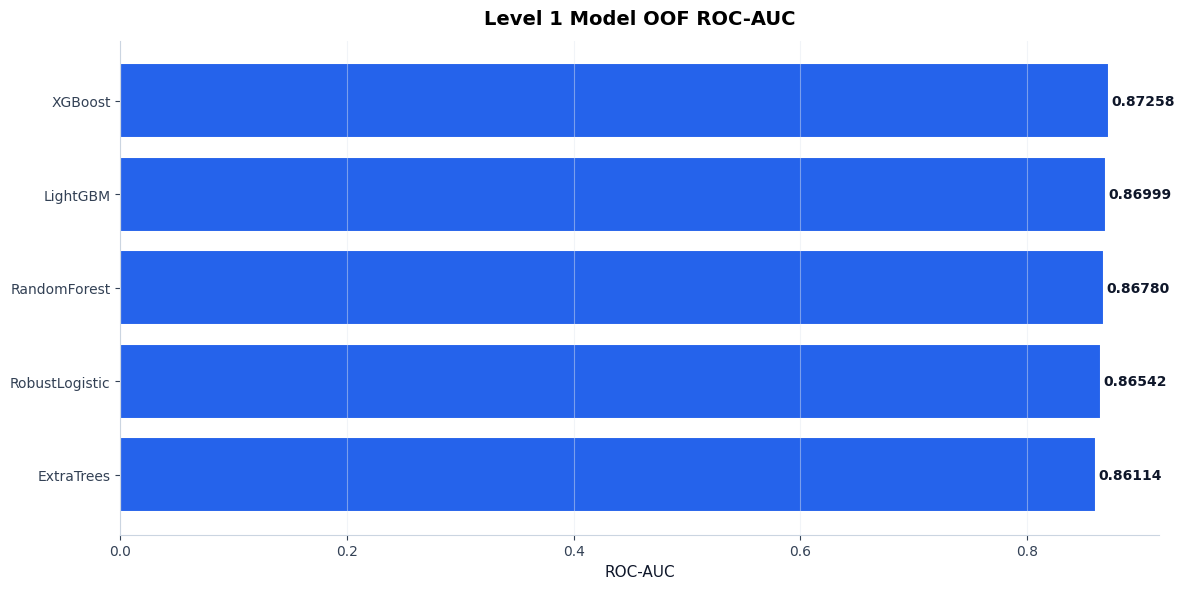

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = level1_summary.sort_values('OOF_ROC_AUC')
ax.barh(plot_df['Model'], plot_df['OOF_ROC_AUC'], color=COLORS['blue'], edgecolor='white', linewidth=1.5)
style_axis(ax, 'Level 1 Model OOF ROC-AUC', xlabel='ROC-AUC')
annotate_horizontal_bars(ax, plot_df['OOF_ROC_AUC'].values, offset=0.002, fmt='{:.5f}')
plt.tight_layout()
plt.show()


**Insight**

The final ensemble should not treat all models equally. Higher OOF models deserve more influence, but diversity is still useful when weaker models make different ranking errors.

### 9.2 Fold Stability by Model

This plot shows fold-level ROC-AUC across the repeated validation design.

The goal is to confirm the result is not coming from one lucky split.

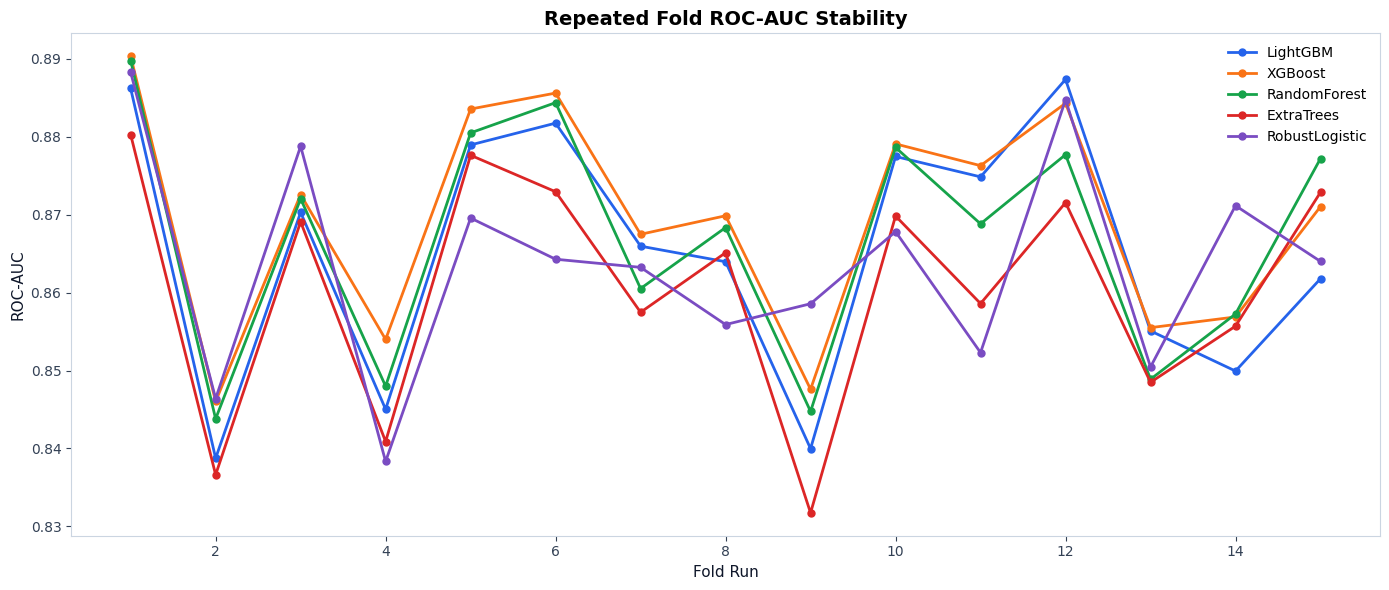

,mean,std,min,max
Model,,,,
XGBoost,0.869346,0.014368,0.846036,0.890345
RandomForest,0.866710,0.015227,0.843803,0.889783
LightGBM,0.865160,0.016383,0.838745,0.887361
RobustLogistic,0.863593,0.013932,0.838336,0.888291
ExtraTrees,0.860590,0.015257,0.831734,0.880285


In [28]:
fig, ax = plt.subplots(figsize=(14, 6))
model_color_cycle = [COLORS['blue'], COLORS['orange'], COLORS['green'], COLORS['red'], COLORS['purple'], COLORS['teal']]
for i, model_name in enumerate(model_names):
    temp = fold_df[fold_df['Model'] == model_name].reset_index(drop=True)
    ax.plot(temp.index + 1, temp['ROC_AUC'], marker='o', linewidth=2, markersize=5, label=model_name, color=model_color_cycle[i % len(model_color_cycle)])
ax.set_title('Repeated Fold ROC-AUC Stability')
ax.set_xlabel('Fold Run')
ax.set_ylabel('ROC-AUC')
ax.legend()
plt.tight_layout()
plt.show()

stability_summary = fold_df.groupby('Model')['ROC_AUC'].agg(['mean', 'std', 'min', 'max']).sort_values('mean', ascending=False)
display(stability_summary)

**Insight**

The mean, standard deviation, minimum, and maximum fold scores show whether model performance is reliable. Stable models are safer for final blending.

### 9.3 Base Model Accuracy Summary

ROC-AUC measures ranking quality, while accuracy measures threshold-based classification quality.

This table mirrors the fold-level ROC-AUC summary and reports threshold-optimized accuracy for each base model. The threshold is chosen inside each validation fold, so it is used for diagnosis only and not for the final submission.


,mean,std,min,max
Model,,,,
XGBoost,0.803424,0.016353,0.776978,0.830935
LightGBM,0.800906,0.018160,0.775180,0.839928
RandomForest,0.798871,0.014834,0.776978,0.830935
RobustLogistic,0.793116,0.014988,0.769784,0.816876
ExtraTrees,0.792998,0.014434,0.771583,0.823741


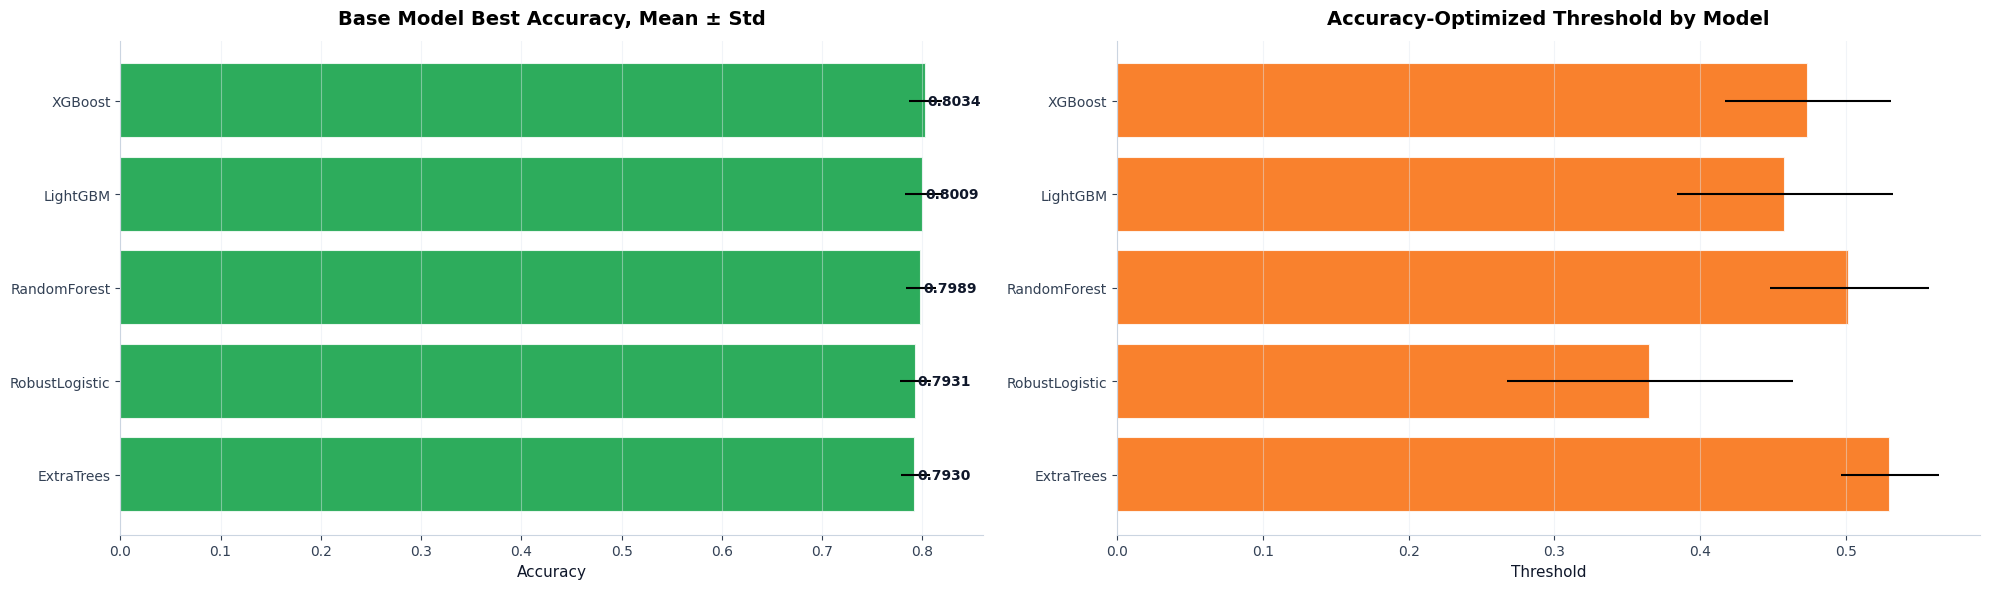

Insight: Accuracy is useful for understanding classification behavior, but the final submission keeps probabilities because ROC-AUC rewards ranking rather than a fixed decision threshold.


In [29]:
accuracy_summary = (
    fold_df
    .groupby('Model')['Best_Accuracy']
    .agg(['mean', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

display(accuracy_summary)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
acc_plot = accuracy_summary.reset_index().sort_values('mean')
axes[0].barh(acc_plot['Model'], acc_plot['mean'], xerr=acc_plot['std'].fillna(0), color=COLORS['green'], edgecolor='white', linewidth=1.5, alpha=0.9)
style_axis(axes[0], 'Base Model Best Accuracy, Mean ± Std', xlabel='Accuracy')
annotate_horizontal_bars(axes[0], acc_plot['mean'].values, offset=0.002, fmt='{:.4f}')

threshold_summary = (
    fold_df
    .groupby('Model')['Best_Accuracy_Threshold']
    .agg(['mean', 'std'])
    .reindex(accuracy_summary.index)
    .reset_index()
)
axes[1].barh(threshold_summary['Model'][::-1], threshold_summary['mean'][::-1], xerr=threshold_summary['std'][::-1].fillna(0), color=COLORS['orange'], edgecolor='white', linewidth=1.5, alpha=0.9)
style_axis(axes[1], 'Accuracy-Optimized Threshold by Model', xlabel='Threshold')

plt.tight_layout()
plt.show()

print('Insight: Accuracy is useful for understanding classification behavior, but the final submission keeps probabilities because ROC-AUC rewards ranking rather than a fixed decision threshold.')

### 9.4 Accuracy, Precision, Recall, and F1 Profile

A model can reach high accuracy by favoring the majority class. Precision, recall, and F1 expose that tradeoff.

This view shows whether a model is strong because it finds drafted players, avoids false positives, or simply matches the dominant class.


,Accuracy_At_050,Best_Accuracy,Precision_At_Best_Accuracy,Recall_At_Best_Accuracy,F1_At_Best_Accuracy
Model,,,,,
XGBoost,0.794554,0.803424,0.782350,0.901150,0.836876
LightGBM,0.793715,0.800906,0.778642,0.902651,0.835455
RandomForest,0.788803,0.798871,0.787918,0.880393,0.830285
RobustLogistic,0.779096,0.793116,0.762568,0.921710,0.833009
ExtraTrees,0.781490,0.792998,0.784208,0.874002,0.825419


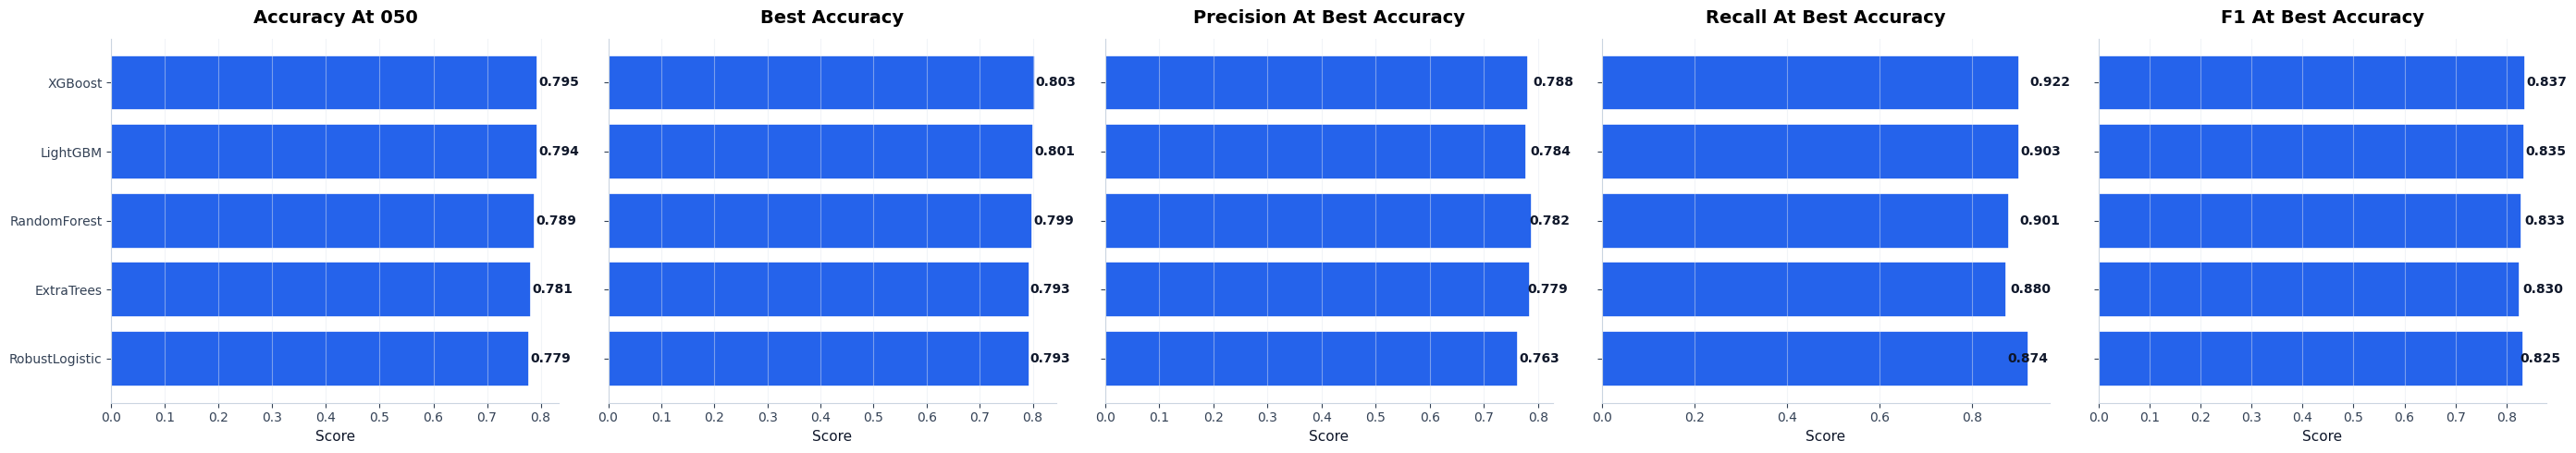

Insight: The model family should be judged by ranking first and classification balance second. A high-accuracy model with weak recall can still be less useful for a probability-ranked submission.


In [30]:
classification_summary = (
    fold_df
    .groupby('Model')[[
        'Accuracy_At_050',
        'Best_Accuracy',
        'Precision_At_Best_Accuracy',
        'Recall_At_Best_Accuracy',
        'F1_At_Best_Accuracy'
    ]]
    .mean()
    .sort_values('Best_Accuracy', ascending=False)
)

display(classification_summary)

metric_plot = classification_summary.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')
metrics = ['Accuracy_At_050', 'Best_Accuracy', 'Precision_At_Best_Accuracy', 'Recall_At_Best_Accuracy', 'F1_At_Best_Accuracy']
fig, axes = plt.subplots(1, len(metrics), figsize=(28, 5), sharey=True)
for ax, metric in zip(axes, metrics):
    temp = classification_summary[metric].sort_values()
    ax.barh(temp.index, temp.values, color=COLORS['blue'], edgecolor='white', linewidth=1.2)
    style_axis(ax, metric.replace('_', ' '), xlabel='Score')
    annotate_horizontal_bars(ax, temp.values, offset=0.002, fmt='{:.3f}')
plt.tight_layout()
plt.show()

print('Insight: The model family should be judged by ranking first and classification balance second. A high-accuracy model with weak recall can still be less useful for a probability-ranked submission.')

### 9.3 OOF Prediction Agreement

This heatmap shows how similar the base model predictions are.

A useful ensemble needs strong models that do not produce identical rankings.

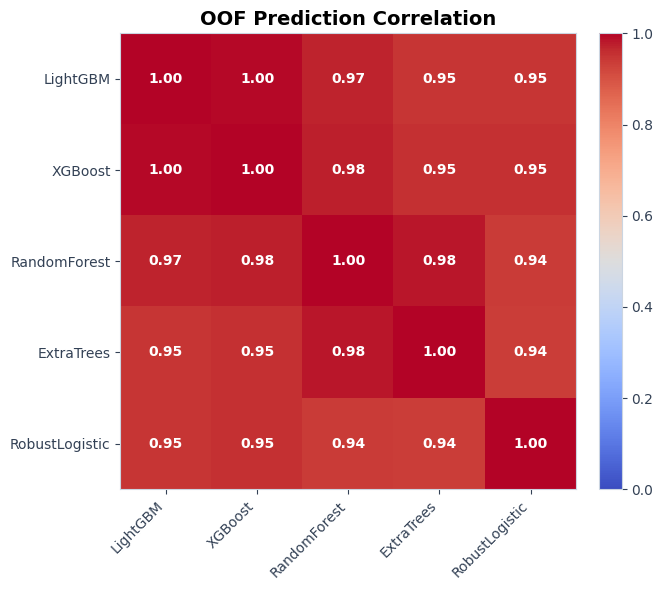

In [31]:
level1_pred_df = pd.DataFrame(level1_oof, columns=model_names)
agreement_corr = level1_pred_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(agreement_corr, cmap='coolwarm', vmin=0, vmax=1)
ax.set_xticks(range(len(model_names)))
ax.set_yticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_yticklabels(model_names)
for i in range(len(model_names)):
    for j in range(len(model_names)):
        ax.text(j, i, f'{agreement_corr.iloc[i, j]:.2f}', ha='center', va='center', color='white' if agreement_corr.iloc[i, j] > 0.65 else COLORS['navy'], fontweight='bold')
ax.set_title('OOF Prediction Correlation')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 9.4 ROC and Precision-Recall Curves by Model

These curves show how each base model ranks drafted players across thresholds.

ROC-AUC is the competition-aligned metric, while precision-recall helps inspect behavior under class imbalance.


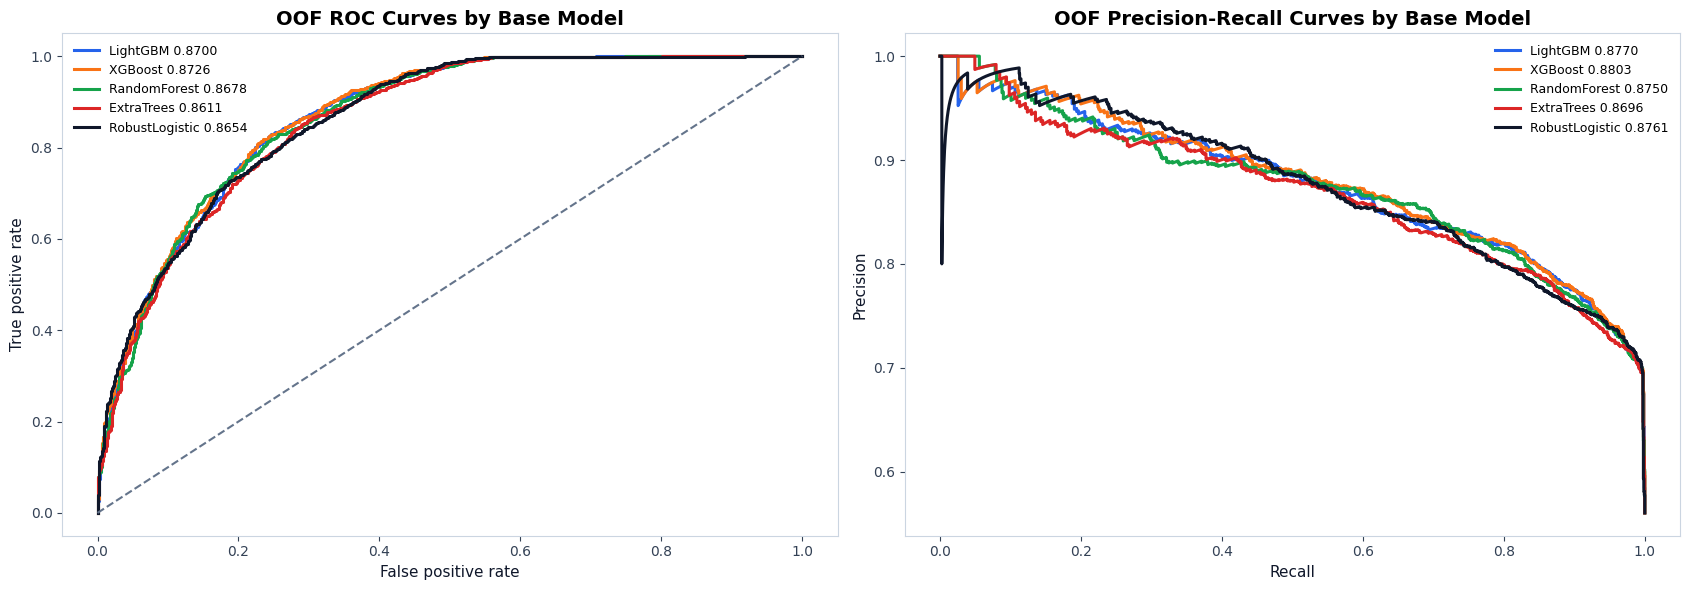

Insight: The best final blend should not only use the highest single model. It should combine models that rank players differently while keeping strong ROC behavior.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_model, level1_oof[:, i])
    auc_value = roc_auc_score(y_model, level1_oof[:, i])
    axes[0].plot(fpr, tpr, linewidth=2.2, label=f'{name} {auc_value:.4f}', color=list(COLORS.values())[i % len(COLORS)])
    precision, recall, _ = precision_recall_curve(y_model, level1_oof[:, i])
    ap_value = average_precision_score(y_model, level1_oof[:, i])
    axes[1].plot(recall, precision, linewidth=2.2, label=f'{name} {ap_value:.4f}', color=list(COLORS.values())[i % len(COLORS)])
axes[0].plot([0, 1], [0, 1], linestyle='--', color=COLORS['gray'])
axes[0].set_title('OOF ROC Curves by Base Model')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend(fontsize=9)
axes[1].set_title('OOF Precision-Recall Curves by Base Model')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Insight: The best final blend should not only use the highest single model. It should combine models that rank players differently while keeping strong ROC behavior.')


### 9.5 Model Prediction Correlation Heatmap

Model diversity matters in an ensemble.

If two models produce nearly identical rankings, they add little value to a blend.


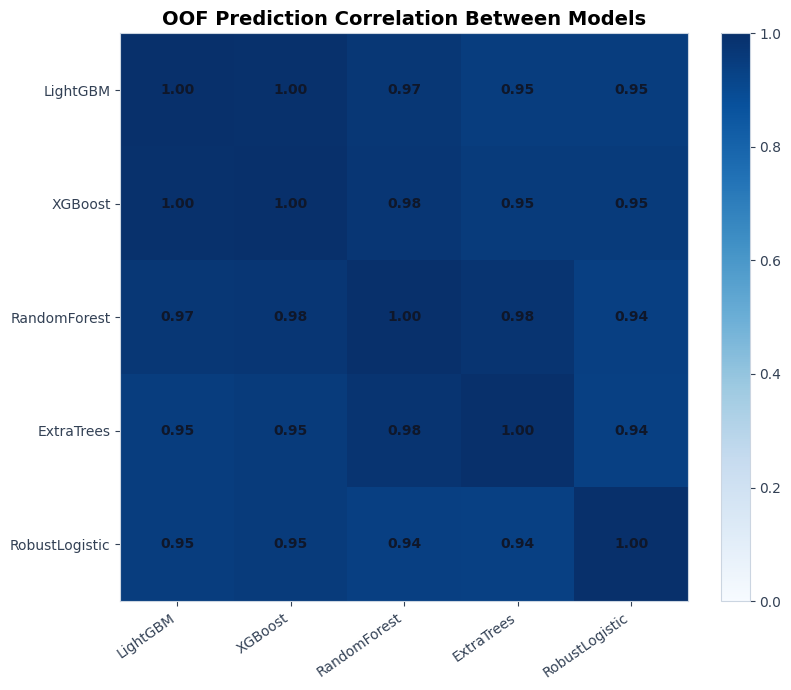

Insight: Lower correlation between two accurate models increases blend value. This is why the notebook tests no-LightGBM and robust-heavy blends instead of relying on a fixed ensemble.


In [33]:
model_pred_df = pd.DataFrame(level1_oof, columns=model_names)
model_corr = model_pred_df.corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(model_corr.values, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=35, ha='right')
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names)
for i in range(len(model_names)):
    for j in range(len(model_names)):
        ax.text(j, i, f'{model_corr.iloc[i, j]:.2f}', ha='center', va='center', color=COLORS['navy'], fontweight='bold')
ax.set_title('OOF Prediction Correlation Between Models')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print('Insight: Lower correlation between two accurate models increases blend value. This is why the notebook tests no-LightGBM and robust-heavy blends instead of relying on a fixed ensemble.')


### 9.6 Model Decile Quality Heatmap

This heatmap shows whether each model concentrates drafted players in the highest predicted-score deciles.

For ROC-AUC, ranking concentration is more important than a single threshold.


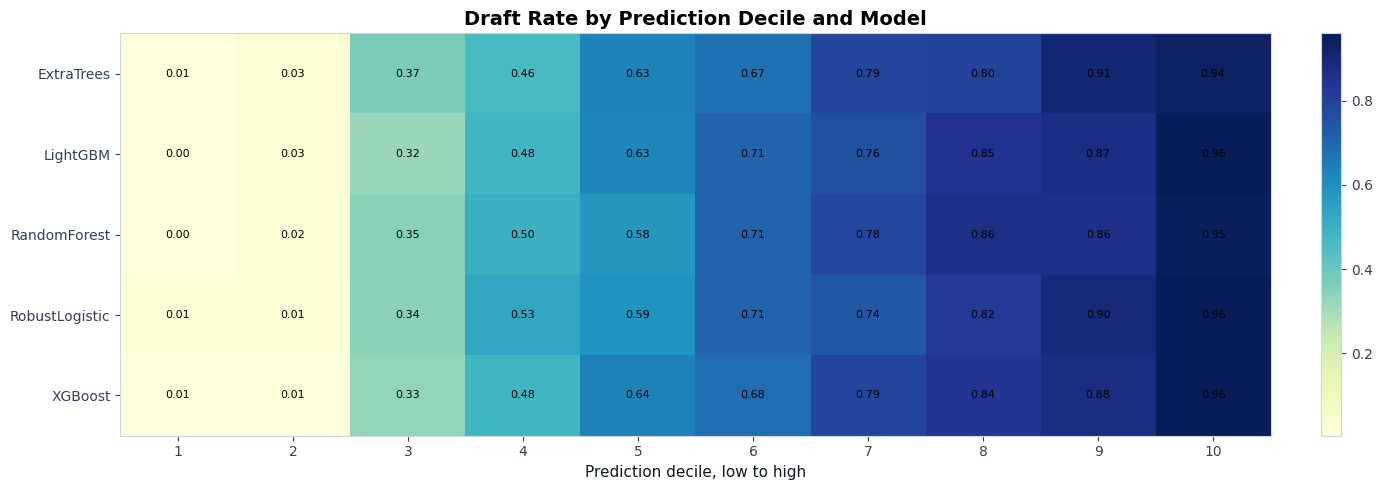

Insight: The model that creates the strongest monotonic lift across deciles is often more useful for ROC-AUC than a model with better-looking probability calibration.


In [34]:
decile_rows = []
for i, name in enumerate(model_names):
    temp = pd.DataFrame({'Prediction': level1_oof[:, i], 'Actual': y_model.values})
    temp['Decile'] = pd.qcut(temp['Prediction'].rank(method='first'), 10, labels=False) + 1
    rates = temp.groupby('Decile')['Actual'].mean()
    for decile, rate in rates.items():
        decile_rows.append({'Model': name, 'Decile': decile, 'Draft_Rate': rate})
decile_model_df = pd.DataFrame(decile_rows)
heat = decile_model_df.pivot(index='Model', columns='Decile', values='Draft_Rate')
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heat.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f'{heat.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Draft Rate by Prediction Decile and Model')
ax.set_xlabel('Prediction decile, low to high')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print('Insight: The model that creates the strongest monotonic lift across deciles is often more useful for ROC-AUC than a model with better-looking probability calibration.')


**Insight**

High correlation means models agree. Moderate disagreement is valuable because blending can correct individual model blind spots.

## 10. Leakage-Safe Stacking

The meta model is trained using a new cross-validation loop over level 1 OOF predictions.

This prevents the meta model from being evaluated on the same rows it was fitted on.

In [35]:
def train_meta_oof(level1_oof, level1_test, y):
    y = pd.Series(y).reset_index(drop=True)
    meta_oof_sum = np.zeros(len(y))
    meta_oof_count = np.zeros(len(y))
    splitter = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=2, random_state=SEED + 200)
    for train_idx, valid_idx in splitter.split(level1_oof, y):
        meta = LogisticRegression(C=0.7, solver='liblinear', class_weight='balanced', random_state=SEED)
        meta.fit(level1_oof[train_idx], y.iloc[train_idx])
        meta_oof_sum[valid_idx] += meta.predict_proba(level1_oof[valid_idx])[:, 1]
        meta_oof_count[valid_idx] += 1
    meta_oof = meta_oof_sum / np.maximum(meta_oof_count, 1)
    final_meta = LogisticRegression(C=0.7, solver='liblinear', class_weight='balanced', random_state=SEED)
    final_meta.fit(level1_oof, y)
    meta_test = final_meta.predict_proba(level1_test)[:, 1]
    meta_auc = roc_auc_score(y, meta_oof)
    return meta_oof, meta_test, meta_auc, final_meta

meta_oof, meta_test, meta_auc, final_meta = train_meta_oof(level1_oof, level1_test, y_model)
print(f'Meta OOF ROC-AUC: {meta_auc:.6f}')

Meta OOF ROC-AUC: 0.872912


**Insight**

The meta model only learns from predictions generated out of fold. Its validation score is therefore a true second-level OOF estimate, not an in-sample stacking score.

## 11. OOF Blend Optimization

The final model is selected using OOF predictions only.

This section compares single models, simple averages, rank averages, optimized probability weights, optimized rank weights, and the OOF meta model.

In [36]:
def rank_percentile(values):
    return pd.Series(values).rank(method='average', pct=True).values


def evaluate_candidate(name, oof_pred, test_pred, y, rows):
    rows.append({'Candidate': name, 'OOF_ROC_AUC': roc_auc_score(y, oof_pred), 'OOF_Prediction': oof_pred, 'Test_Prediction': test_pred})


def random_weight_search(preds, y, n_iter=6500, seed=SEED):
    rng = np.random.default_rng(seed)
    best_auc = -np.inf
    best_weights = None
    for _ in range(n_iter):
        weights = rng.dirichlet(np.ones(preds.shape[1]))
        blended = preds @ weights
        auc = roc_auc_score(y, blended)
        if auc > best_auc:
            best_auc = auc
            best_weights = weights
    return best_weights, best_auc

candidate_rows = []
for i, name in enumerate(model_names):
    evaluate_candidate(name, level1_oof[:, i], level1_test[:, i], y_model, candidate_rows)

mean_oof = level1_oof.mean(axis=1)
mean_test = level1_test.mean(axis=1)
evaluate_candidate('MeanProbabilityBlend', mean_oof, mean_test, y_model, candidate_rows)

rank_oof_matrix = np.column_stack([rank_percentile(level1_oof[:, i]) for i in range(level1_oof.shape[1])])
rank_test_matrix = np.column_stack([rank_percentile(level1_test[:, i]) for i in range(level1_test.shape[1])])
rank_mean_oof = rank_oof_matrix.mean(axis=1)
rank_mean_test = rank_test_matrix.mean(axis=1)
evaluate_candidate('MeanRankBlend', rank_mean_oof, rank_mean_test, y_model, candidate_rows)

best_prob_weights, best_prob_auc = random_weight_search(level1_oof, y_model, n_iter=6500, seed=SEED + 1)
optimized_prob_oof = level1_oof @ best_prob_weights
optimized_prob_test = level1_test @ best_prob_weights
evaluate_candidate('OptimizedProbabilityBlend', optimized_prob_oof, optimized_prob_test, y_model, candidate_rows)

best_rank_weights, best_rank_auc = random_weight_search(rank_oof_matrix, y_model, n_iter=6500, seed=SEED + 2)
optimized_rank_oof = rank_oof_matrix @ best_rank_weights
optimized_rank_test = rank_test_matrix @ best_rank_weights
evaluate_candidate('OptimizedRankBlend', optimized_rank_oof, optimized_rank_test, y_model, candidate_rows)

if 'LightGBM' in model_names and len(model_names) > 2:
    keep_idx = [i for i, name in enumerate(model_names) if name != 'LightGBM']
    no_lgb_oof = level1_oof[:, keep_idx]
    no_lgb_test = level1_test[:, keep_idx]
    no_lgb_weights, no_lgb_auc = random_weight_search(no_lgb_oof, y_model, n_iter=6500, seed=SEED + 3)
    evaluate_candidate('NoLightGBMOptimizedBlend', no_lgb_oof @ no_lgb_weights, no_lgb_test @ no_lgb_weights, y_model, candidate_rows)

preferred_names = [name for name in ['RobustLogistic', 'XGBoost', 'ExtraTrees'] if name in model_names]
if len(preferred_names) >= 2:
    preferred_idx = [model_names.index(name) for name in preferred_names]
    preferred_oof = level1_oof[:, preferred_idx]
    preferred_test = level1_test[:, preferred_idx]
    preferred_weights, preferred_auc = random_weight_search(preferred_oof, y_model, n_iter=6500, seed=SEED + 4)
    evaluate_candidate('RobustXGBTreeOptimizedBlend', preferred_oof @ preferred_weights, preferred_test @ preferred_weights, y_model, candidate_rows)

prob_rank_oof = 0.5 * rank_percentile(optimized_prob_oof) + 0.5 * rank_percentile(optimized_rank_oof)
prob_rank_test = 0.5 * rank_percentile(optimized_prob_test) + 0.5 * rank_percentile(optimized_rank_test)
evaluate_candidate('ProbabilityRankHybridBlend', prob_rank_oof, prob_rank_test, y_model, candidate_rows)

evaluate_candidate('OOFMetaModel', meta_oof, meta_test, y_model, candidate_rows)

candidate_table = pd.DataFrame([{k: v for k, v in row.items() if k not in ['OOF_Prediction', 'Test_Prediction']} for row in candidate_rows]).sort_values('OOF_ROC_AUC', ascending=False)
display(candidate_table)

best_idx = candidate_table.index[0]
best_candidate = candidate_rows[best_idx]
final_oof = best_candidate['OOF_Prediction']
final_test_pred = best_candidate['Test_Prediction']
final_choice_name = best_candidate['Candidate']
final_oof_auc = roc_auc_score(y_model, final_oof)
print(f'Final selected strategy: {final_choice_name}')
print(f'Final OOF ROC-AUC: {final_oof_auc:.6f}')


,Candidate,OOF_ROC_AUC
9,NoLightGBMOptimizedBlend,0.874653
7,OptimizedProbabilityBlend,0.874586
11,ProbabilityRankHybridBlend,0.874547
10,RobustXGBTreeOptimizedBlend,0.874429
8,OptimizedRankBlend,0.874398
5,MeanProbabilityBlend,0.873604
12,OOFMetaModel,0.872912
6,MeanRankBlend,0.872818
1,XGBoost,0.872585
0,LightGBM,0.869989


Final selected strategy: NoLightGBMOptimizedBlend
Final OOF ROC-AUC: 0.874653


**Insight**

The final strategy is not chosen manually. It is chosen from OOF evidence. This makes the final decision easier to defend and reduces the chance of selecting a weaker-looking model by habit.

### 11.1 Candidate Comparison Visual

This chart shows every final candidate and the selected strategy.

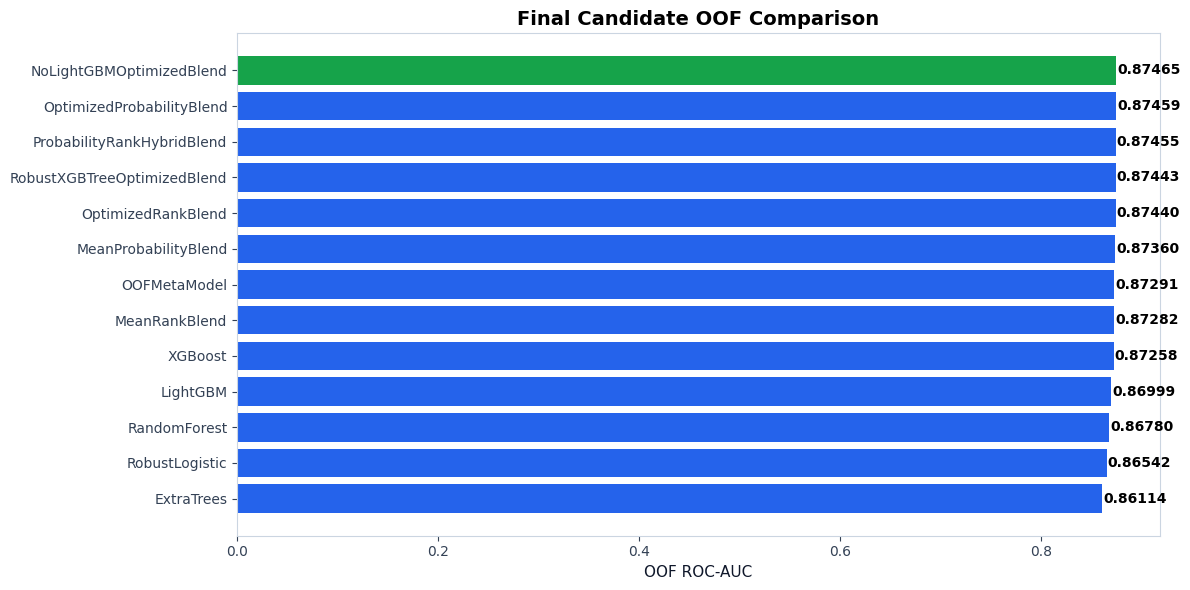

In [37]:
plot_df = candidate_table.sort_values('OOF_ROC_AUC')
colors = [COLORS['green'] if c == final_choice_name else COLORS['blue'] for c in plot_df['Candidate']]
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(plot_df['Candidate'], plot_df['OOF_ROC_AUC'], color=colors)
ax.set_title('Final Candidate OOF Comparison')
ax.set_xlabel('OOF ROC-AUC')
for i, value in enumerate(plot_df['OOF_ROC_AUC']):
    ax.text(value + 0.001, i, f'{value:.5f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

The selected final candidate must be the strongest OOF strategy, unless there is a clear stability reason to choose otherwise. This keeps the final submission aligned with validation evidence.

### 11.2 Optimized Blend Weights

This chart shows how much each level 1 model contributes to the optimized blends.

Weights are tuned using OOF predictions only.

,Model,OptimizedProbabilityWeight,OptimizedRankWeight
0,LightGBM,0.048818,0.016017
1,XGBoost,0.484984,0.468951
2,RandomForest,0.196952,0.207603
3,ExtraTrees,0.007950,0.022597
4,RobustLogistic,0.261296,0.284833


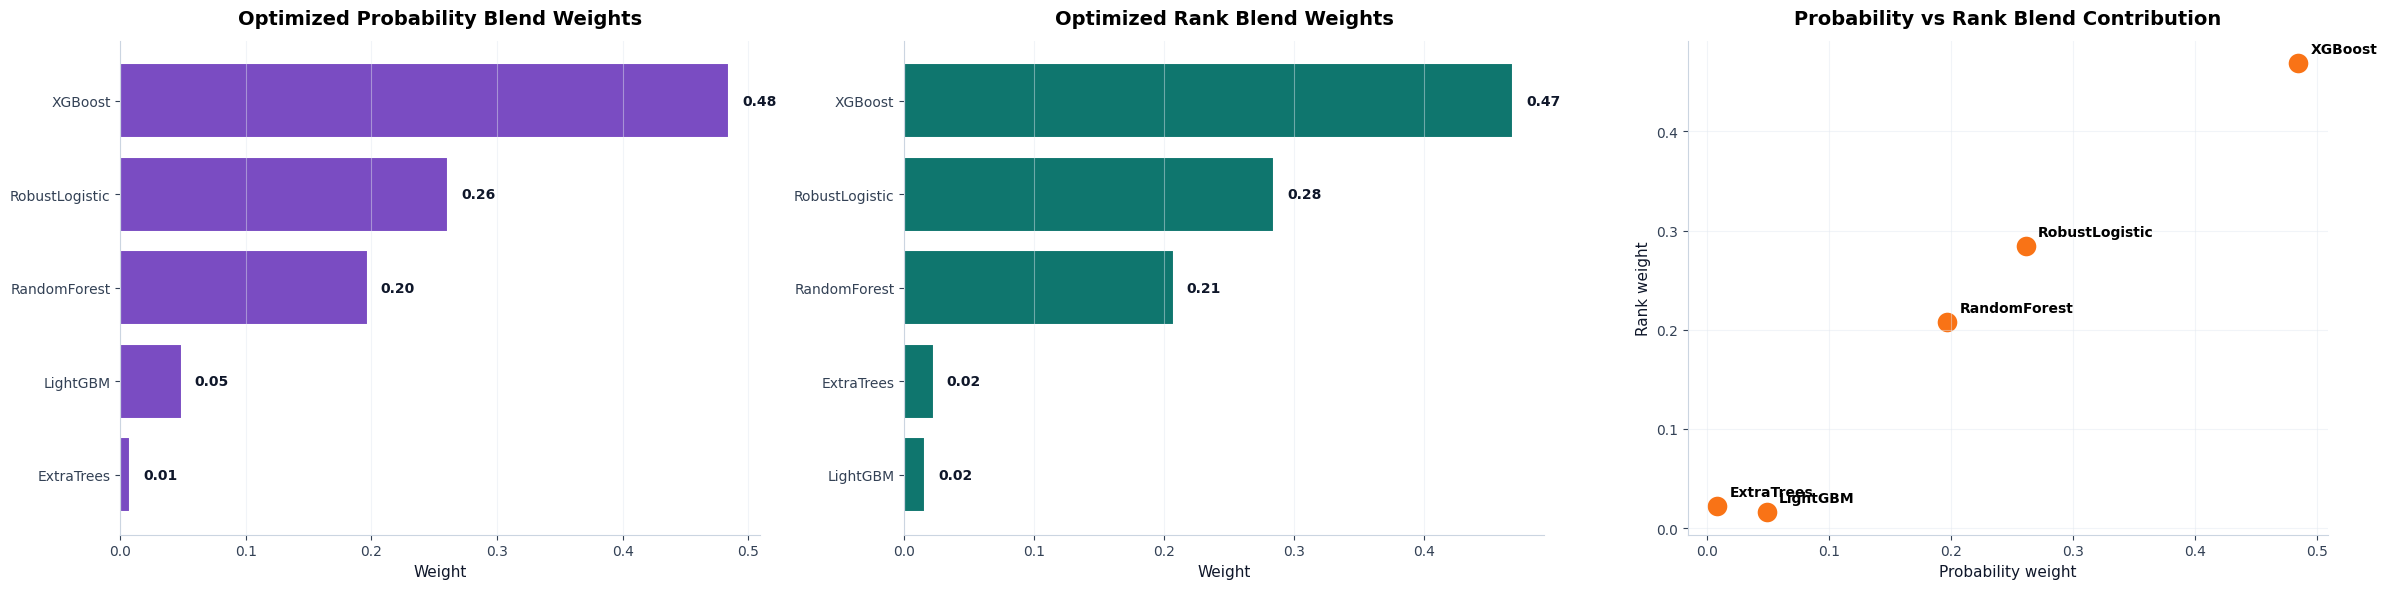

Insight: Blend weights are selected from OOF predictions only. A model can receive lower weight even when it is useful if another model already captures a similar ranking pattern.


In [38]:
weight_df = pd.DataFrame({
    'Model': model_names,
    'OptimizedProbabilityWeight': best_prob_weights,
    'OptimizedRankWeight': best_rank_weights
})

weight_long = weight_df.melt(id_vars='Model', var_name='Blend_Type', value_name='Weight')
display(weight_df)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
prob_sorted = weight_df.sort_values('OptimizedProbabilityWeight')
rank_sorted = weight_df.sort_values('OptimizedRankWeight')

axes[0].barh(prob_sorted['Model'], prob_sorted['OptimizedProbabilityWeight'], color=COLORS['purple'], edgecolor='white', linewidth=1.5)
style_axis(axes[0], 'Optimized Probability Blend Weights', xlabel='Weight')
annotate_horizontal_bars(axes[0], prob_sorted['OptimizedProbabilityWeight'].values, offset=0.01, fmt='{:.2f}')

axes[1].barh(rank_sorted['Model'], rank_sorted['OptimizedRankWeight'], color=COLORS['teal'], edgecolor='white', linewidth=1.5)
style_axis(axes[1], 'Optimized Rank Blend Weights', xlabel='Weight')
annotate_horizontal_bars(axes[1], rank_sorted['OptimizedRankWeight'].values, offset=0.01, fmt='{:.2f}')

axes[2].scatter(weight_df['OptimizedProbabilityWeight'], weight_df['OptimizedRankWeight'], s=260, color=COLORS['orange'], edgecolor='white', linewidth=2)
for _, row in weight_df.iterrows():
    axes[2].text(row['OptimizedProbabilityWeight'] + 0.01, row['OptimizedRankWeight'] + 0.01, row['Model'], fontweight='bold')
style_axis(axes[2], 'Probability vs Rank Blend Contribution', xlabel='Probability weight', ylabel='Rank weight', grid_axis='both')

plt.tight_layout()
plt.show()

print('Insight: Blend weights are selected from OOF predictions only. A model can receive lower weight even when it is useful if another model already captures a similar ranking pattern.')


### 11.3 Candidate Strategy Comparison Dashboard

This dashboard compares all final strategy candidates.

It makes the final model choice transparent and prevents manual selection of a weaker candidate.


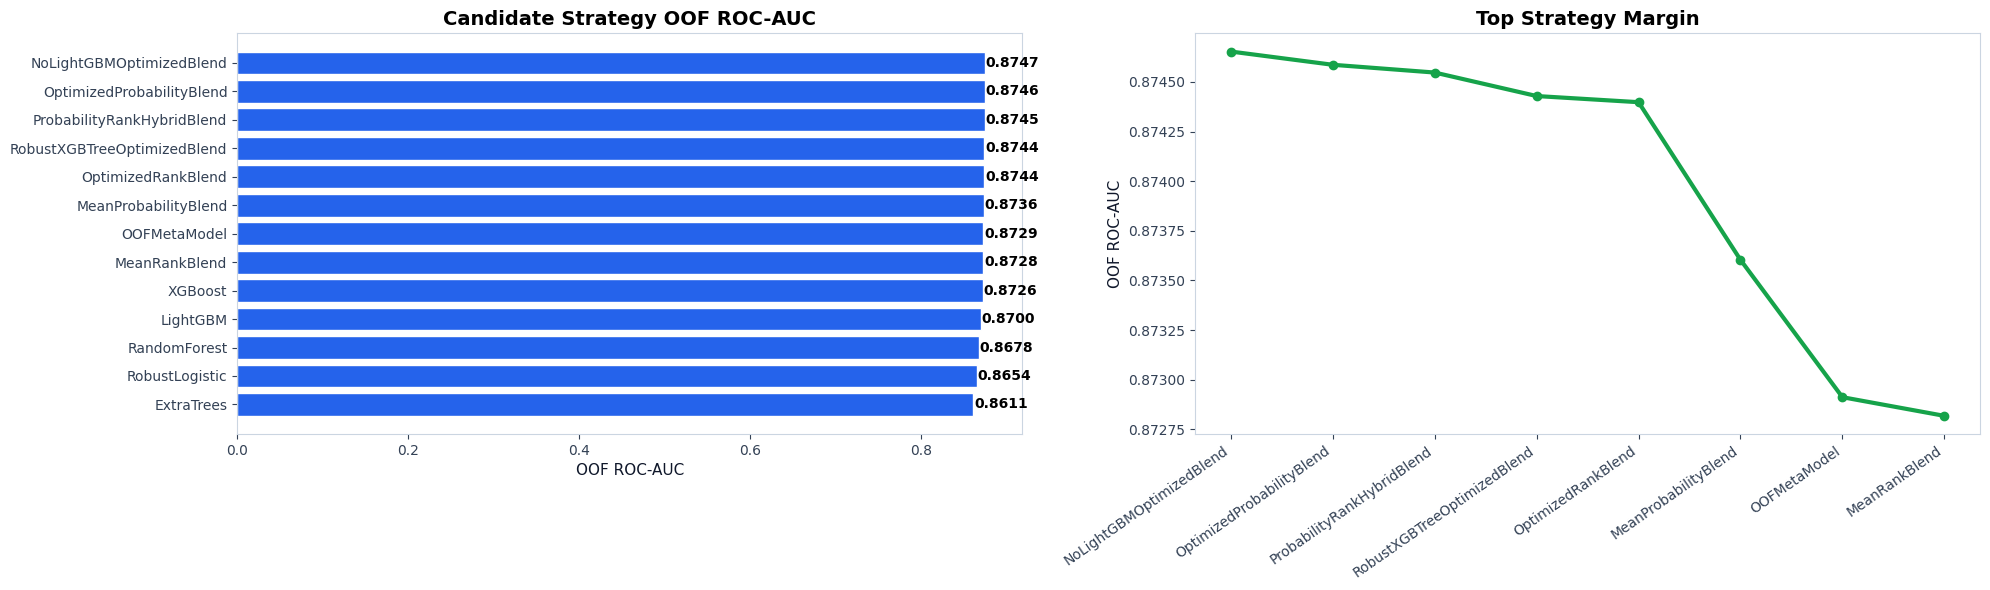

Insight: The final submission is produced by the best OOF strategy, not by a manually preferred model. This protects the workflow from choosing a weaker final blend.


In [39]:
candidate_plot = candidate_table.sort_values('OOF_ROC_AUC')
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
axes[0].barh(candidate_plot['Candidate'], candidate_plot['OOF_ROC_AUC'], color=COLORS['blue'], edgecolor='white')
axes[0].set_title('Candidate Strategy OOF ROC-AUC')
axes[0].set_xlabel('OOF ROC-AUC')
for y_pos, value in enumerate(candidate_plot['OOF_ROC_AUC']):
    axes[0].text(value + 0.001, y_pos, f'{value:.4f}', va='center', fontweight='bold')

best_display = candidate_table.head(8).copy()
axes[1].plot(range(len(best_display)), best_display['OOF_ROC_AUC'], marker='o', linewidth=3, color=COLORS['green'])
axes[1].set_xticks(range(len(best_display)))
axes[1].set_xticklabels(best_display['Candidate'], rotation=35, ha='right')
axes[1].set_title('Top Strategy Margin')
axes[1].set_ylabel('OOF ROC-AUC')
plt.tight_layout()
plt.show()

print('Insight: The final submission is produced by the best OOF strategy, not by a manually preferred model. This protects the workflow from choosing a weaker final blend.')


### 11.4 Final Strategy Distribution Compared with Base Models

This plot checks whether the selected final strategy has a useful score spread.

A stronger ranking model should separate the high-score and low-score population without collapsing predictions into a narrow band.


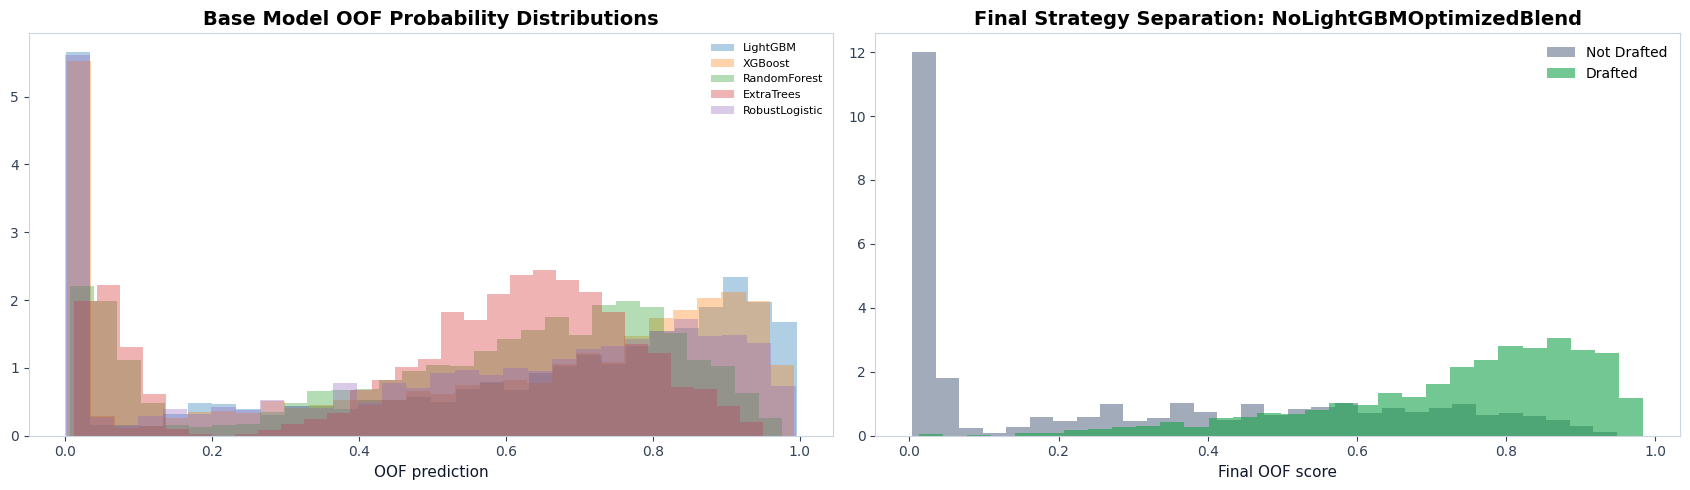

Insight: The final score does not need perfect probability calibration to perform well on ROC-AUC. It needs a stable ordering that places drafted players above non-drafted players.


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
for i, name in enumerate(model_names):
    axes[0].hist(level1_oof[:, i], bins=30, alpha=0.35, density=True, label=name)
axes[0].set_title('Base Model OOF Probability Distributions')
axes[0].set_xlabel('OOF prediction')
axes[0].legend(fontsize=8)

axes[1].hist(final_oof[y_model.values == 0], bins=30, alpha=0.6, density=True, color=COLORS['gray'], label='Not Drafted')
axes[1].hist(final_oof[y_model.values == 1], bins=30, alpha=0.6, density=True, color=COLORS['green'], label='Drafted')
axes[1].set_title(f'Final Strategy Separation: {final_choice_name}')
axes[1].set_xlabel('Final OOF score')
axes[1].legend()
plt.tight_layout()
plt.show()

print('Insight: The final score does not need perfect probability calibration to perform well on ROC-AUC. It needs a stable ordering that places drafted players above non-drafted players.')


**Insight**

The optimized weights reveal which models add ranking value. Rank-based blending can help when probability scales differ across model families.

## 12. Ablation Study

The ablation study measures how each feature block affects validation quality.

The study is leakage-safe because each stage still fits preprocessing inside each fold.

In [41]:
def run_quick_cv_stage(options, model_name='LightGBM'):
    splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 500)
    oof = np.zeros(len(X_model))
    for fold_number, (train_idx, valid_idx) in enumerate(splitter.split(X_model, y_model), start=1):
        X_train_raw = X_model.iloc[train_idx].reset_index(drop=True)
        X_valid_raw = X_model.iloc[valid_idx].reset_index(drop=True)
        y_train = y_model.iloc[train_idx].reset_index(drop=True)
        X_train_matrix, X_valid_matrix, X_test_matrix, selected_cols = prepare_fold_matrices(X_train_raw, y_train, X_valid_raw, X_test_model, options, SEED + 500 + fold_number)
        stage_models = make_models(SEED + 500 + fold_number)
        if model_name in stage_models:
            model = clone(stage_models[model_name])
        else:
            model = ExtraTreesClassifier(n_estimators=400, max_depth=8, min_samples_leaf=7, random_state=SEED + 500 + fold_number, n_jobs=-1, class_weight='balanced')
        model.fit(X_train_matrix, y_train)
        oof[valid_idx] = predict_probability(model, X_valid_matrix)
    return roc_auc_score(y_model, oof)

ablation_configs = [
    ('Base numeric features only', {'include_missing': False, 'include_ranks': False, 'include_frequency': False, 'include_position_deltas': False, 'include_zscores': False, 'include_target_encoding': False, 'max_features': 80, 'corr_threshold': 0.985, 'knn_neighbors': 7}),
    ('Missing indicators', {'include_missing': True, 'include_ranks': False, 'include_frequency': False, 'include_position_deltas': False, 'include_zscores': False, 'include_target_encoding': False, 'max_features': 80, 'corr_threshold': 0.985, 'knn_neighbors': 7}),
    ('Ranks and frequency', {'include_missing': True, 'include_ranks': True, 'include_frequency': True, 'include_position_deltas': False, 'include_zscores': False, 'include_target_encoding': False, 'max_features': 80, 'corr_threshold': 0.985, 'knn_neighbors': 7}),
    ('Position deltas', {'include_missing': True, 'include_ranks': True, 'include_frequency': True, 'include_position_deltas': True, 'include_zscores': False, 'include_target_encoding': False, 'max_features': 80, 'corr_threshold': 0.985, 'knn_neighbors': 7}),
    ('Position z-scores', {'include_missing': True, 'include_ranks': True, 'include_frequency': True, 'include_position_deltas': True, 'include_zscores': True, 'include_target_encoding': False, 'max_features': 80, 'corr_threshold': 0.985, 'knn_neighbors': 7}),
    ('OOF target encoding', {'include_missing': True, 'include_ranks': True, 'include_frequency': True, 'include_position_deltas': True, 'include_zscores': True, 'include_target_encoding': True, 'max_features': 80, 'corr_threshold': 0.985, 'knn_neighbors': 7})
]

ablation_rows = []
for name, config in ablation_configs:
    score = run_quick_cv_stage(config)
    ablation_rows.append({'Stage': name, 'OOF_ROC_AUC': score})

ablation_rows.append({'Stage': 'Best level 1 model', 'OOF_ROC_AUC': level1_summary['OOF_ROC_AUC'].max()})
ablation_rows.append({'Stage': 'Best final strategy', 'OOF_ROC_AUC': final_oof_auc})

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df)

,Stage,OOF_ROC_AUC
0,Base numeric features only,0.860588
1,Missing indicators,0.861167
2,Ranks and frequency,0.861858
3,Position deltas,0.865466
4,Position z-scores,0.865241
5,OOF target encoding,0.866279
6,Best level 1 model,0.872585
7,Best final strategy,0.874653


### 12.1 Ablation Study Visual

This chart shows how the score changes as new blocks are added.

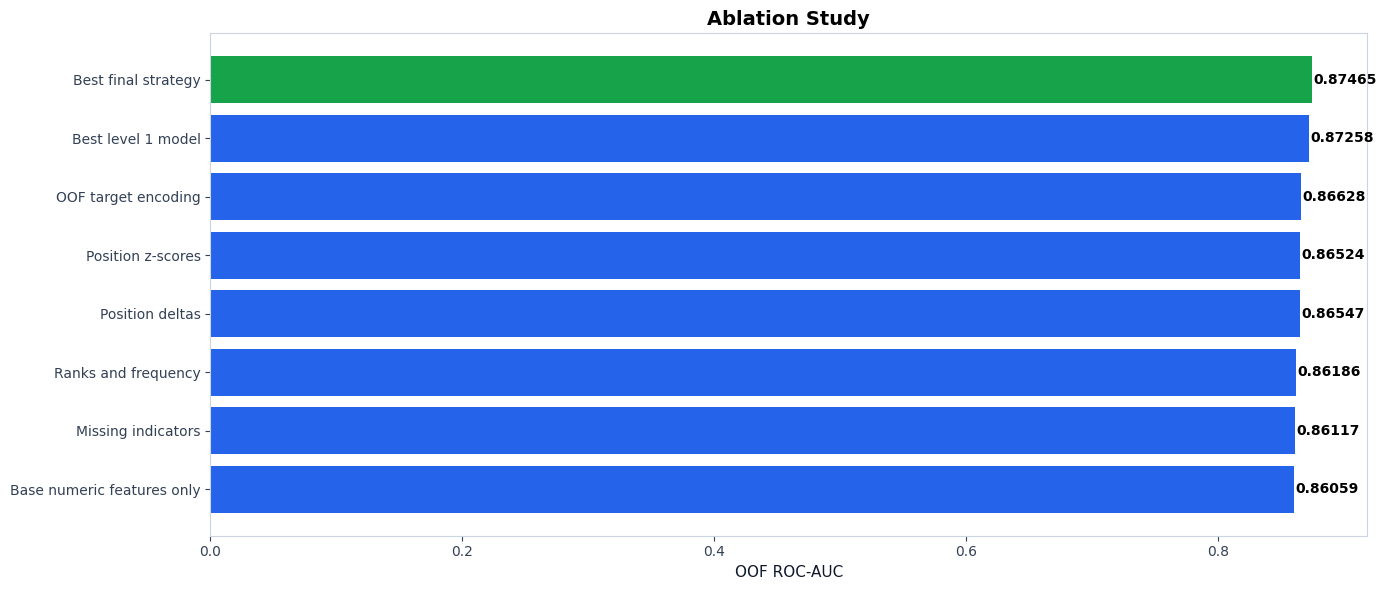

In [42]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = [COLORS['green'] if s == 'Best final strategy' else COLORS['blue'] for s in ablation_df['Stage']]
ax.barh(ablation_df['Stage'], ablation_df['OOF_ROC_AUC'], color=colors)
ax.set_title('Ablation Study')
ax.set_xlabel('OOF ROC-AUC')
for i, value in enumerate(ablation_df['OOF_ROC_AUC']):
    ax.text(value + 0.001, i, f'{value:.5f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

The ablation table explains which blocks add value and which blocks should be treated carefully. If target encoding does not improve OOF score, the final configuration can safely leave it out.

## 13. Stability Diagnostics

This section summarizes repeated validation stability across all base models and the final candidate.

The goal is to prove that the result is not driven by one lucky split.

,Model,mean,std,min,max
4,XGBoost,0.869346,0.014368,0.846036,0.890345
2,RandomForest,0.866710,0.015227,0.843803,0.889783
1,LightGBM,0.865160,0.016383,0.838745,0.887361
3,RobustLogistic,0.863593,0.013932,0.838336,0.888291
0,ExtraTrees,0.860590,0.015257,0.831734,0.880285


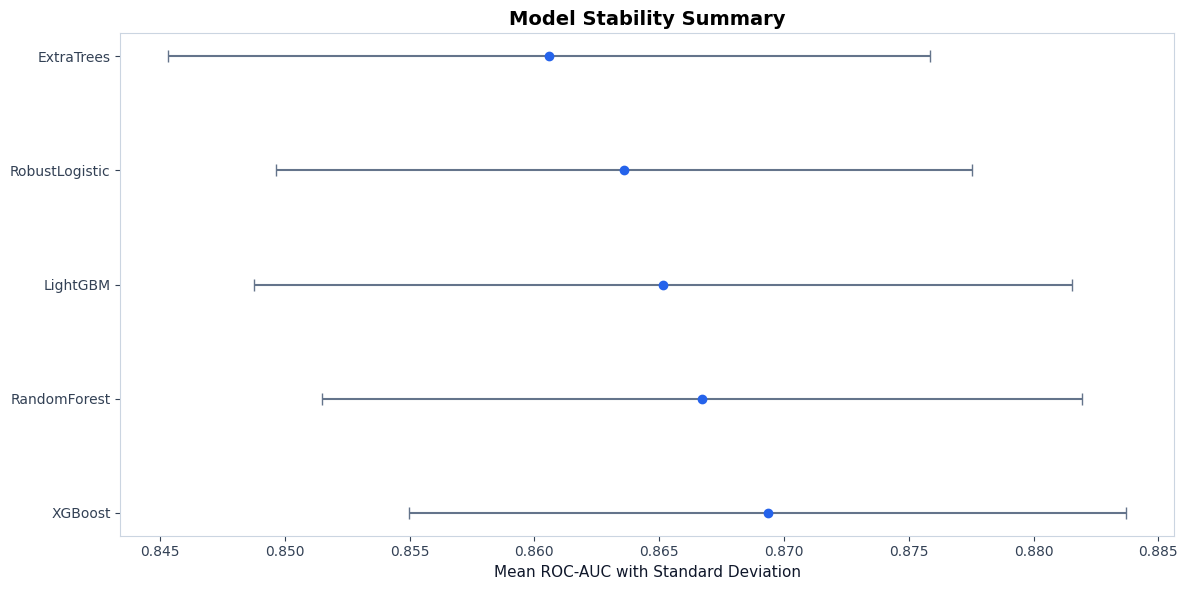

In [43]:
final_stability = fold_df.groupby('Model')['ROC_AUC'].agg(['mean', 'std', 'min', 'max']).reset_index()
final_stability = final_stability.sort_values('mean', ascending=False)
display(final_stability)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(final_stability['mean'], final_stability['Model'], xerr=final_stability['std'], fmt='o', color=COLORS['blue'], ecolor=COLORS['gray'], capsize=4)
ax.set_title('Model Stability Summary')
ax.set_xlabel('Mean ROC-AUC with Standard Deviation')
plt.tight_layout()
plt.show()

**Insight**

A tight standard deviation supports a stable model. A wide range means the model is sensitive to split composition and should receive lower ensemble trust.

## 14. Feature Selection Study

The main pipeline uses fold-local feature selection to avoid keeping too many weak features.

This section compares different feature counts using fold-safe selection.

In [44]:
feature_count_rows = []
for max_features in [50, 80, 120, None]:
    config = dict(main_options)
    config['max_features'] = max_features
    score = run_quick_cv_stage(config)
    label = 'All filtered features' if max_features is None else f'Top {max_features}'
    feature_count_rows.append({'Feature_Set': label, 'OOF_ROC_AUC': score})

feature_count_df = pd.DataFrame(feature_count_rows).sort_values('OOF_ROC_AUC', ascending=False)
display(feature_count_df)

,Feature_Set,OOF_ROC_AUC
1,Top 80,0.865241
3,All filtered features,0.864425
0,Top 50,0.863812
2,Top 120,0.863731


### 14.1 Feature Count Visual

This chart compares smaller and larger feature sets.

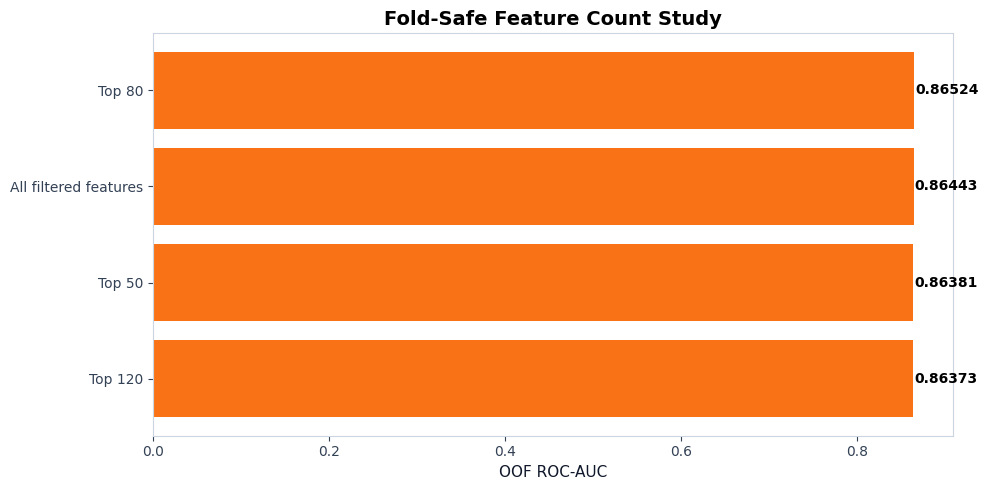

In [45]:
plot_df = feature_count_df.sort_values('OOF_ROC_AUC')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_df['Feature_Set'], plot_df['OOF_ROC_AUC'], color=COLORS['orange'])
ax.set_title('Fold-Safe Feature Count Study')
ax.set_xlabel('OOF ROC-AUC')
for i, value in enumerate(plot_df['OOF_ROC_AUC']):
    ax.text(value + 0.001, i, f'{value:.5f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Feature Count Decision Insight**

The feature-count study is a diagnostic run, not the only source of the final model choice.

If Top 80 is stronger in the LightGBM-only feature-count experiment, that means LightGBM prefers a tighter representation. The final pipeline can still use Top 120 when the ensemble benefits from additional features across linear, tree, boosting, and rank-based blending components.

The selected feature count should therefore be justified by the final OOF candidate comparison, not by a single-model diagnostic alone.


**Insight**

The feature count study helps avoid overfitting. If a smaller feature set performs similarly, it is often the safer practical choice.

## 15. Feature Explanation

This section explains which features repeatedly mattered across folds.

Importance is aggregated from models trained only on fold training data, which makes it safer than fitting one model on all training rows and interpreting that model in isolation.

### 15.1 Aggregated Fold Importance

This chart shows the top features across tree-based models and repeated folds.

,Feature,Importance
0,Age_Missing,0.103788
1,Age_Missing_Position_Z,0.078820
2,Age_Missing_Position_Delta,0.059678
3,Age_Adjusted_Burst_Missing,0.045070
4,Year,0.033125
5,Age_Missing_Position_Ratio,0.028876
6,Year_Position_Z,0.024200
7,Year_Position_Delta,0.020401
8,Sprint_40yd_Position_Z,0.016869
9,Year_Position_Type_Delta,0.016344


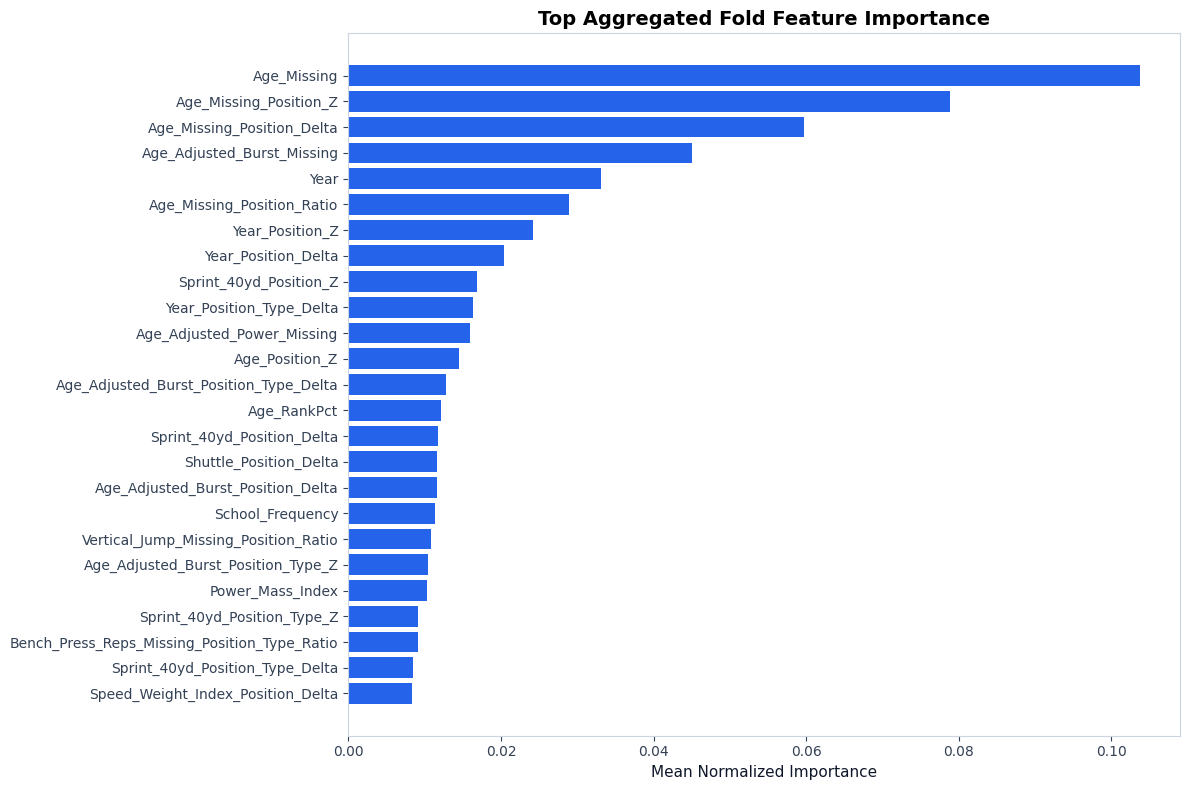

In [46]:
if len(importance_df) > 0:
    feature_importance_summary = importance_df.groupby('Feature')['Importance'].mean().sort_values(ascending=False).head(25).reset_index()
else:
    feature_importance_summary = pd.DataFrame(columns=['Feature', 'Importance'])

display(feature_importance_summary)

fig, ax = plt.subplots(figsize=(12, 8))
if len(feature_importance_summary) > 0:
    plot_df = feature_importance_summary.sort_values('Importance')
    ax.barh(plot_df['Feature'], plot_df['Importance'], color=COLORS['blue'])
    ax.set_title('Top Aggregated Fold Feature Importance')
    ax.set_xlabel('Mean Normalized Importance')
else:
    ax.text(0.5, 0.5, 'No tree importance available', ha='center', va='center')
    ax.axis('off')
plt.tight_layout()
plt.show()

**Insight**

The best features should make domain sense. Position-relative athletic measures, missingness patterns, and composite speed-power features are more trustworthy than identifier-derived features.

### 15.2 Feature Selection Frequency

This visualization shows how often features survive fold-local feature selection.

A feature selected across many folds is more stable than a feature that appears only once.

,Feature,Selection_Frequency
0,Age_Missing,0.008333
1,Height_Weight_Ratio_Position_Type_Z,0.008333
2,Bench_Press_Reps_Position_Delta,0.008333
3,Height_Position_Type_Delta,0.008333
4,Speed_Weight_Index_Player_Type_Delta,0.008333
5,BMI_Position_Type_Delta,0.008333
6,Jump_Efficiency_Position_Delta,0.008333
7,Size_Index_Position_Z,0.008333
8,Bench_Press_Reps_Position_Type_Ratio,0.008333
9,BMI_Position_Delta,0.008333


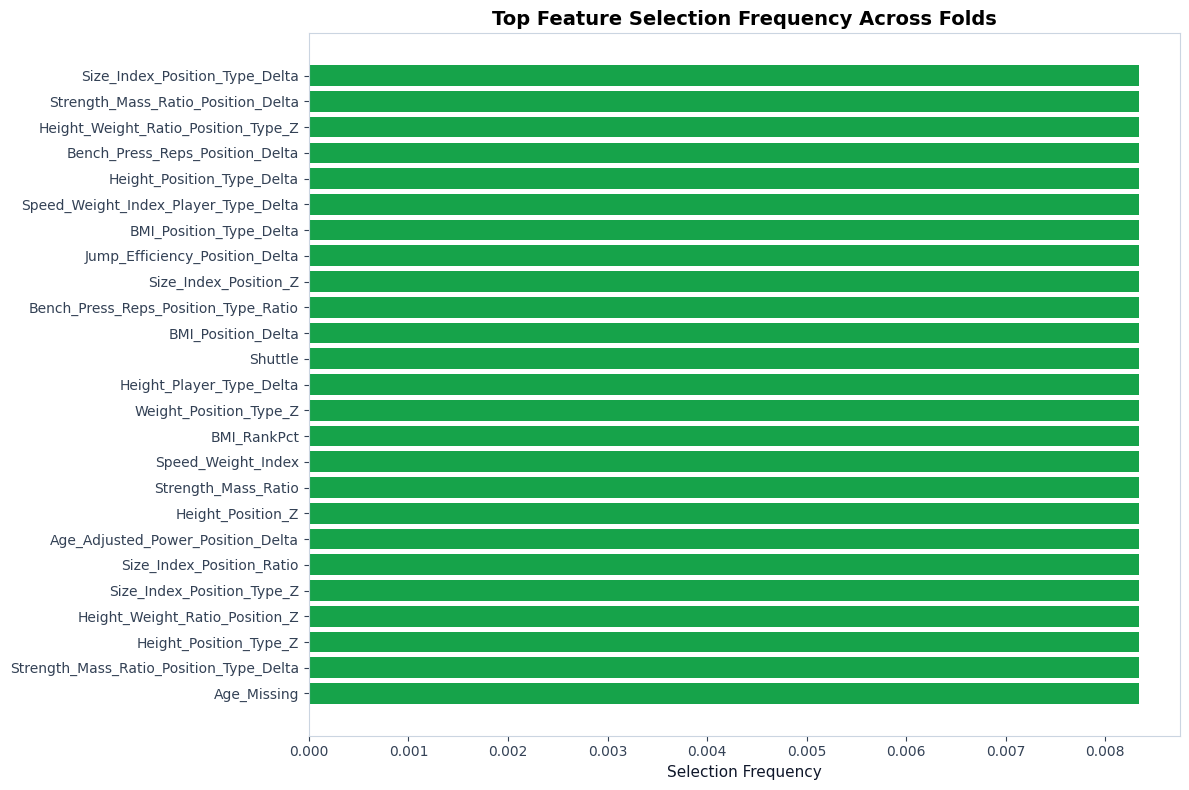

In [47]:
selection_freq = selected_feature_df['Feature'].value_counts(normalize=True).head(25).reset_index()
selection_freq.columns = ['Feature', 'Selection_Frequency']
display(selection_freq)

fig, ax = plt.subplots(figsize=(12, 8))
plot_df = selection_freq.sort_values('Selection_Frequency')
ax.barh(plot_df['Feature'], plot_df['Selection_Frequency'], color=COLORS['green'])
ax.set_title('Top Feature Selection Frequency Across Folds')
ax.set_xlabel('Selection Frequency')
plt.tight_layout()
plt.show()

**Missingness Feature Interpretation**

If `Age_Missing` or another missingness flag appears near the top of the feature explanation, it should not be treated automatically as leakage.

In scouting data, missingness can carry practical meaning:

- Some players do not complete every measurement.
- Some positions emphasize different workouts.
- Some prospects have incomplete public profiles.
- Missing age or workout information can correlate with scouting visibility, eligibility context, or data availability.

The notebook treats missingness as a modeling signal, but it is created inside the fold-safe pipeline and does not use the target label directly.


**Insight**

Selection frequency is a useful stability signal. It shows whether a feature is consistently useful under different validation splits.

### 15.3 Permutation Importance on a Clean Holdout Fold

Permutation importance measures the performance drop after shuffling a feature on validation data.

The model and preprocessing are fitted only on the training part of the holdout fold.

,Feature,Permutation_Importance
2,Age_Missing_Position_Z,0.047370
0,Age_Missing,0.032529
5,Year,0.028316
7,Year_Position_Z,0.008153
12,Sprint_40yd_Position_Z,0.005449
20,Age_Position_Z,0.004010
23,Sprint_40yd_Position_Type_Delta,0.003882
13,Sprint_40yd_Position_Delta,0.002471
6,Year_Position_Delta,0.002289
108,Explosiveness_Index_Position_Z,0.002075


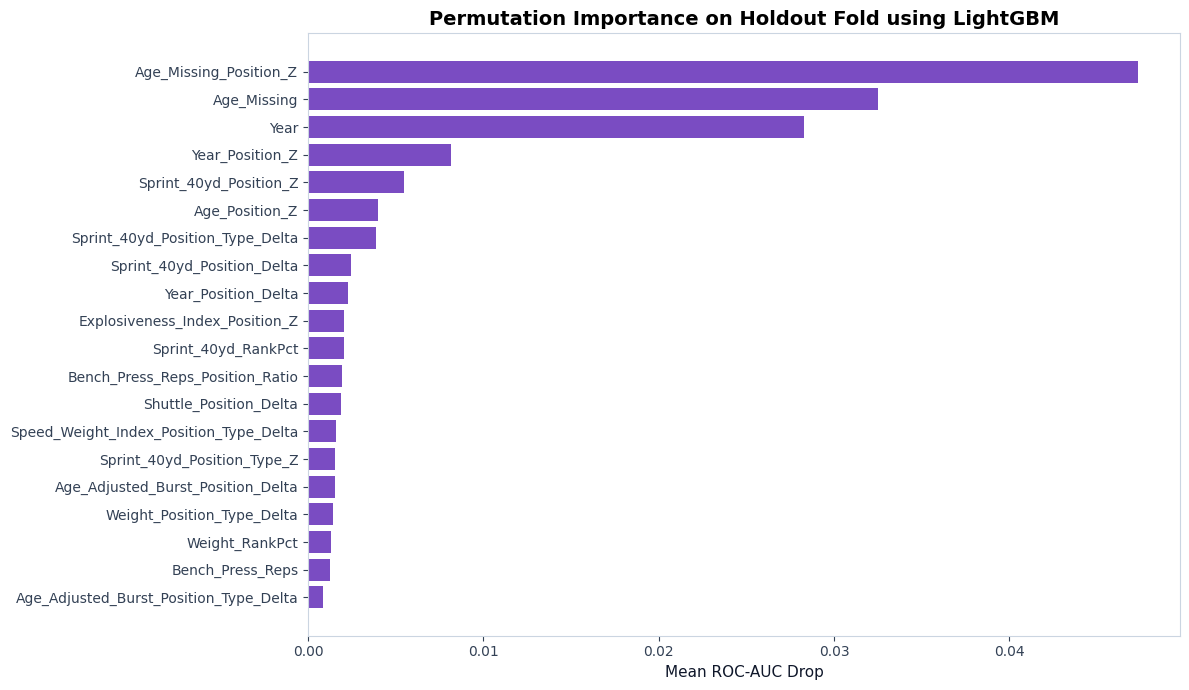

In [48]:
perm_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 900)
perm_train_idx, perm_valid_idx = next(perm_split.split(X_model, y_model))
X_perm_train_raw = X_model.iloc[perm_train_idx].reset_index(drop=True)
X_perm_valid_raw = X_model.iloc[perm_valid_idx].reset_index(drop=True)
y_perm_train = y_model.iloc[perm_train_idx].reset_index(drop=True)
y_perm_valid = y_model.iloc[perm_valid_idx].reset_index(drop=True)
X_perm_train, X_perm_valid, X_perm_test, perm_cols = prepare_fold_matrices(X_perm_train_raw, y_perm_train, X_perm_valid_raw, X_test_model, main_options, SEED + 901)
perm_models = make_models(SEED + 901)
perm_model_name = 'LightGBM' if 'LightGBM' in perm_models else list(perm_models.keys())[0]
perm_model = clone(perm_models[perm_model_name])
perm_model.fit(X_perm_train, y_perm_train)
perm_result = permutation_importance(perm_model, X_perm_valid, y_perm_valid, scoring='roc_auc', n_repeats=8, random_state=SEED + 902, n_jobs=-1)
perm_df = pd.DataFrame({'Feature': perm_cols, 'Permutation_Importance': perm_result.importances_mean}).sort_values('Permutation_Importance', ascending=False).head(20)
display(perm_df)

fig, ax = plt.subplots(figsize=(12, 7))
plot_df = perm_df.sort_values('Permutation_Importance')
ax.barh(plot_df['Feature'], plot_df['Permutation_Importance'], color=COLORS['purple'])
ax.set_title(f'Permutation Importance on Holdout Fold using {perm_model_name}')
ax.set_xlabel('Mean ROC-AUC Drop')
plt.tight_layout()
plt.show()

**Insight**

Permutation importance is more practical than raw gain alone because it tests how much a feature matters on unseen validation rows.

### 15.4 Optional SHAP Explanation

SHAP gives a deeper view of feature direction and magnitude for tree models.

If SHAP is available, the notebook shows the top explanation plot for a validation sample.

In [49]:
if HAS_SHAP and perm_model_name in ['LightGBM', 'XGBoost', 'RandomForest', 'ExtraTrees']:
    try:
        shap_sample = X_perm_valid.sample(min(250, len(X_perm_valid)), random_state=SEED)
        explainer = shap.TreeExplainer(perm_model)
        shap_values = explainer.shap_values(shap_sample)
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[-1]
        else:
            shap_values_to_plot = shap_values
        shap.summary_plot(shap_values_to_plot, shap_sample, max_display=20, show=True)
    except Exception as shap_error:
        print(f'SHAP explanation skipped: {shap_error}')
else:
    print('SHAP explanation skipped because a compatible setup is not available.')

SHAP explanation skipped because a compatible setup is not available.


**Insight**

SHAP helps explain whether a feature pushes a prediction upward or downward. This is useful when presenting the model to a technical reviewer who wants more than a score.

## 16. Train-Test Drift Analysis

This section checks whether the feature distribution in train differs from test.

Drift does not mean the feature is unusable. It means the model should use robust transformations such as ranks, frequencies, fold-safe group statistics, and position-relative features.


### 16.1 Numeric Drift with KS and PSI

KS checks distribution difference. PSI estimates population shift.

Both are computed using train as the reference distribution.

,Feature,KS_Statistic,PSI
0,Year,0.140925,0.108356
7,Broad_Jump,0.048620,0.026418
5,Vertical_Jump,0.018033,0.025446
6,Bench_Press_Reps,0.051560,0.018676
8,Agility_3cone,0.041116,0.014631
9,Shuttle,0.036977,0.014303
4,Sprint_40yd,0.023393,0.009930
2,Height,0.021113,0.008485
3,Weight,0.033086,0.007257
1,Age,0.029068,0.004956


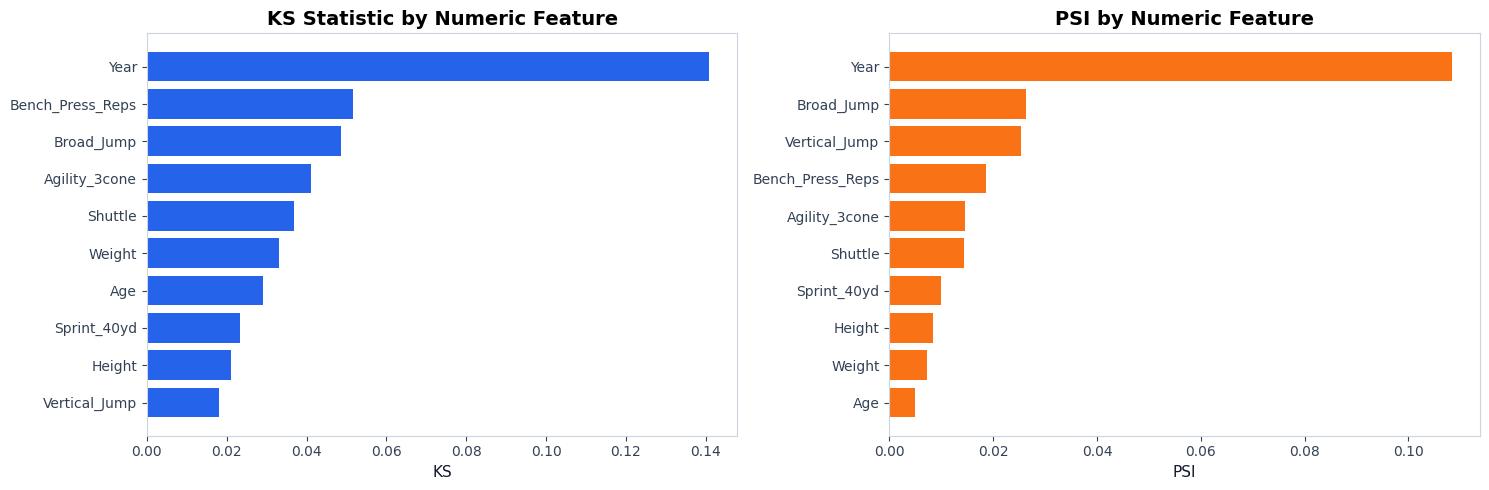

In [50]:
def psi_score(train_values, test_values, bins=10):
    train_values = pd.Series(train_values).dropna().astype(float)
    test_values = pd.Series(test_values).dropna().astype(float)
    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan
    quantiles = np.unique(np.quantile(train_values, np.linspace(0, 1, bins + 1)))
    if len(quantiles) <= 2:
        return np.nan
    train_counts = pd.cut(train_values, bins=quantiles, include_lowest=True, duplicates='drop').value_counts(normalize=True).sort_index()
    test_counts = pd.cut(test_values, bins=quantiles, include_lowest=True, duplicates='drop').value_counts(normalize=True).reindex(train_counts.index).fillna(0)
    train_share = train_counts.replace(0, 0.0001)
    test_share = test_counts.replace(0, 0.0001)
    return float(((test_share - train_share) * np.log(test_share / train_share)).sum())

drift_cols = [c for c in RAW_NUMERIC_COLS if c in train.columns and c in test.columns]
drift_rows = []
for col in drift_cols:
    ks_value = ks_2samp(train[col].dropna(), test[col].dropna()).statistic if HAS_SCIPY and train[col].notna().sum() > 0 and test[col].notna().sum() > 0 else np.nan
    psi_value = psi_score(train[col], test[col])
    drift_rows.append({'Feature': col, 'KS_Statistic': ks_value, 'PSI': psi_value})

drift_df = pd.DataFrame(drift_rows).sort_values('PSI', ascending=False)
display(drift_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(drift_df.sort_values('KS_Statistic')['Feature'], drift_df.sort_values('KS_Statistic')['KS_Statistic'], color=COLORS['blue'])
axes[0].set_title('KS Statistic by Numeric Feature')
axes[0].set_xlabel('KS')
axes[1].barh(drift_df.sort_values('PSI')['Feature'], drift_df.sort_values('PSI')['PSI'], color=COLORS['orange'])
axes[1].set_title('PSI by Numeric Feature')
axes[1].set_xlabel('PSI')
plt.tight_layout()
plt.show()

**Insight**

High drift features need careful treatment. Position-relative features and rank features help reduce the risk of relying only on raw values whose test distribution may shift.

### 16.2 Categorical Coverage and Rare Categories

This section compares categorical coverage between train and test.

Rare or unseen categories can weaken encoding quality, so the fold pipeline uses fallback values.

,Feature,Train_Unique,Test_Unique,Overlap,Unseen_Test_Categories,Rare_Train_Categories
0,School,246,147,146,1,175
1,Player_Type,3,3,3,0,0
2,Position_Type,7,6,6,0,1
3,Position,20,18,18,0,2


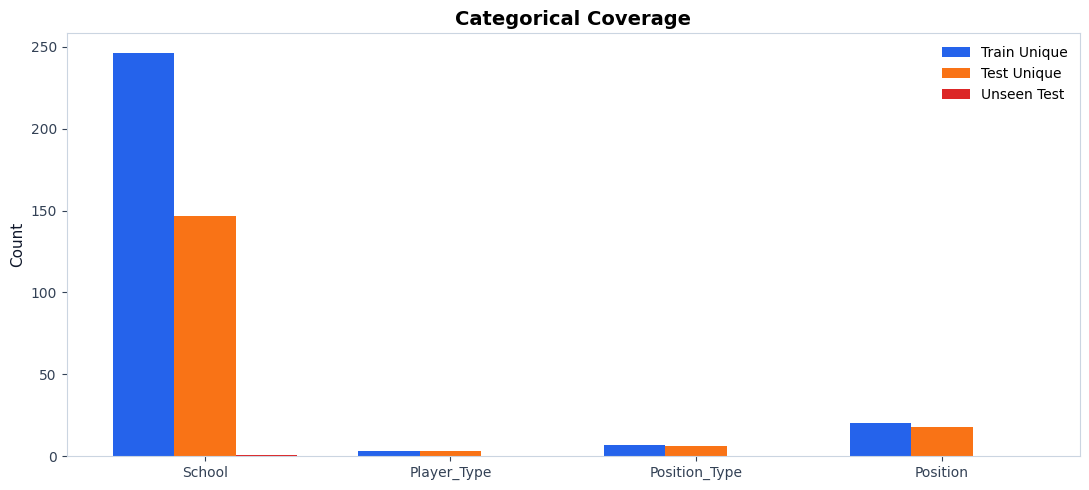

In [51]:
cat_drift_rows = []
for col in [c for c in CATEGORICAL_COLS if c in train.columns and c in test.columns]:
    train_set = set(train[col].dropna().astype(str))
    test_set = set(test[col].dropna().astype(str))
    overlap = len(train_set.intersection(test_set))
    unseen = len(test_set - train_set)
    train_rare = (train[col].astype(str).value_counts(normalize=True) < 0.005).sum()
    cat_drift_rows.append({'Feature': col, 'Train_Unique': len(train_set), 'Test_Unique': len(test_set), 'Overlap': overlap, 'Unseen_Test_Categories': unseen, 'Rare_Train_Categories': train_rare})

cat_drift_df = pd.DataFrame(cat_drift_rows)
display(cat_drift_df)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cat_drift_df))
width = 0.25
ax.bar(x - width, cat_drift_df['Train_Unique'], width, label='Train Unique', color=COLORS['blue'])
ax.bar(x, cat_drift_df['Test_Unique'], width, label='Test Unique', color=COLORS['orange'])
ax.bar(x + width, cat_drift_df['Unseen_Test_Categories'], width, label='Unseen Test', color=COLORS['red'])
ax.set_xticks(x)
ax.set_xticklabels(cat_drift_df['Feature'])
ax.set_title('Categorical Coverage')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

**Insight**

Fallback handling is necessary for unseen schools or rare positions. Frequency encoding and target encoding both use training-fold fallbacks to stay stable.

## 17. Calibration Diagnostics

ROC-AUC measures ranking. Calibration measures probability trust.

A model can rank well while its probabilities are too high or too low. This section reports both visual and numeric calibration diagnostics.

,Metric,Value
0,Brier Score,0.137103
1,Log Loss,0.417370
2,Calibration Slope,1.103889
3,Calibration Intercept,0.036135


,Mean_Predicted_Probability,Observed_Draft_Rate,Absolute_Gap
0,0.011780,0.007168,0.004612
1,0.036998,0.010791,0.026206
2,0.289837,0.294964,0.005127
3,0.472434,0.525180,0.052746
4,0.595394,0.600719,0.005326
5,0.690675,0.697842,0.007167
6,0.761912,0.776978,0.015067
7,0.819063,0.834532,0.015469
8,0.872858,0.884892,0.012034
9,0.933105,0.971223,0.038118


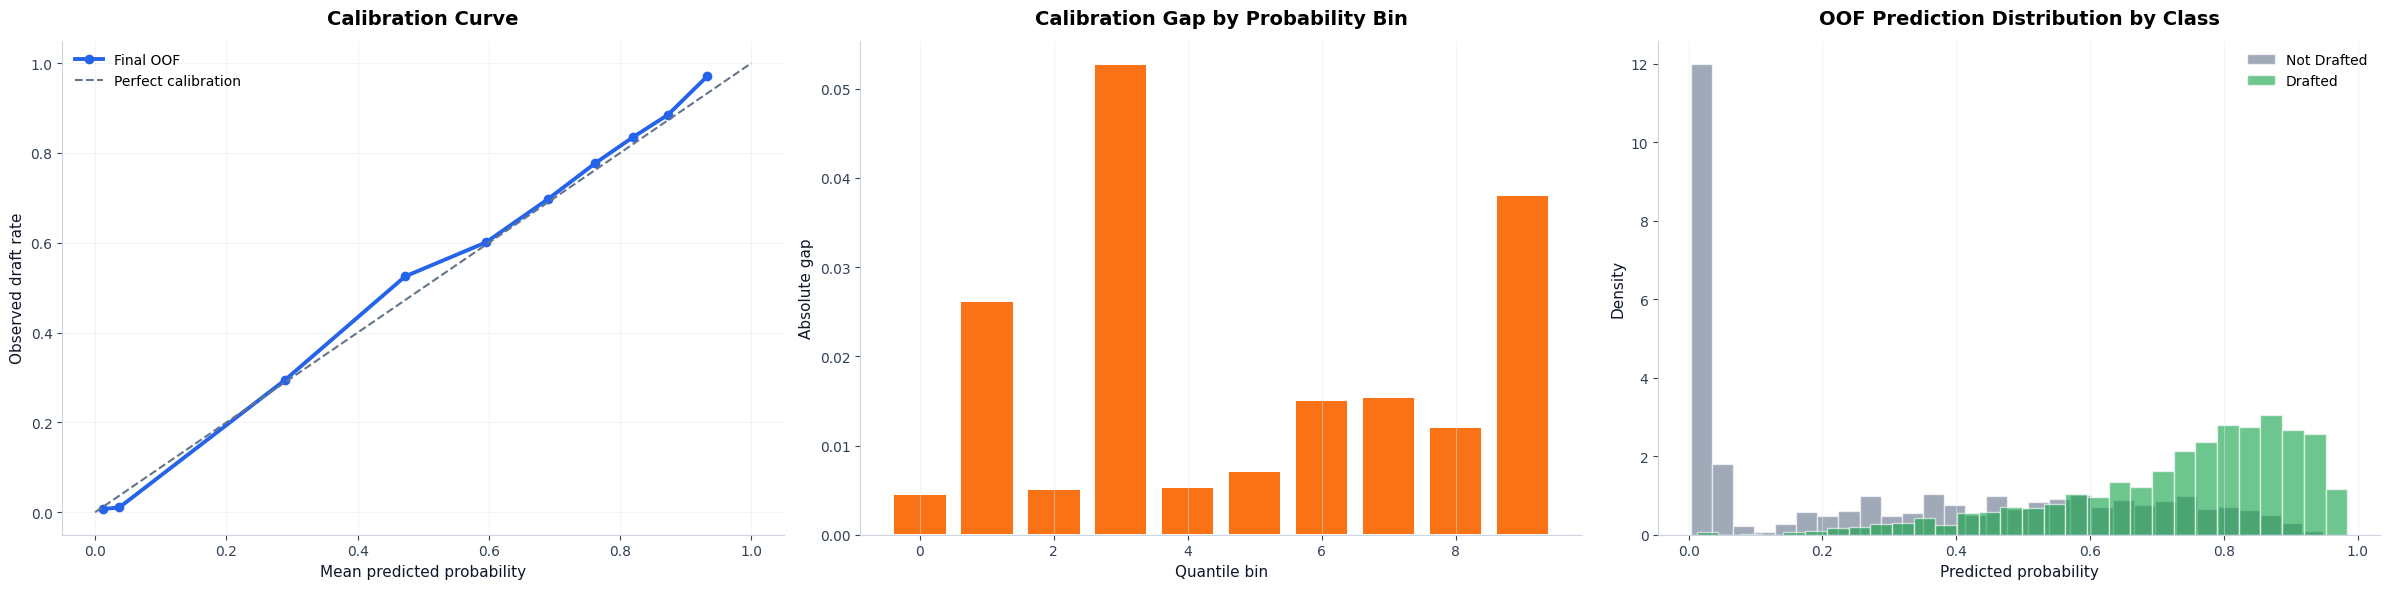

Insight: The final prediction is strongest as a ranking signal. Calibration slope 1.10 and intercept 0.04 show that probabilities should be interpreted with care if exact probability meaning is required.


In [52]:
def safe_clip_prob(p):
    return np.clip(p, 1e-6, 1 - 1e-6)

calibration_prob = safe_clip_prob(final_oof)
brier = brier_score_loss(y_model, calibration_prob)
ll = log_loss(y_model, calibration_prob)
logit_pred = np.log(calibration_prob / (1 - calibration_prob)).reshape(-1, 1)
cal_model = LogisticRegression(solver='lbfgs')
cal_model.fit(logit_pred, y_model)
calibration_slope = float(cal_model.coef_[0][0])
calibration_intercept = float(cal_model.intercept_[0])

calibration_metrics = pd.DataFrame({
    'Metric': ['Brier Score', 'Log Loss', 'Calibration Slope', 'Calibration Intercept'],
    'Value': [brier, ll, calibration_slope, calibration_intercept]
})
display(calibration_metrics)

prob_true, prob_pred = calibration_curve(y_model, calibration_prob, n_bins=10, strategy='quantile')
calibration_bins = pd.DataFrame({'Mean_Predicted_Probability': prob_pred, 'Observed_Draft_Rate': prob_true})
calibration_bins['Absolute_Gap'] = (calibration_bins['Observed_Draft_Rate'] - calibration_bins['Mean_Predicted_Probability']).abs()

display(calibration_bins)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].plot(prob_pred, prob_true, marker='o', linewidth=2.8, color=COLORS['blue'], label='Final OOF')
axes[0].plot([0, 1], [0, 1], linestyle='--', color=COLORS['gray'], label='Perfect calibration')
style_axis(axes[0], 'Calibration Curve', xlabel='Mean predicted probability', ylabel='Observed draft rate', grid_axis='both')
axes[0].legend()

axes[1].bar(range(len(calibration_bins)), calibration_bins['Absolute_Gap'], color=COLORS['orange'], edgecolor='white', linewidth=1.4)
style_axis(axes[1], 'Calibration Gap by Probability Bin', xlabel='Quantile bin', ylabel='Absolute gap')

axes[2].hist(calibration_prob[y_model.values == 0], bins=30, alpha=0.62, density=True, color=COLORS['gray'], label='Not Drafted', edgecolor='white')
axes[2].hist(calibration_prob[y_model.values == 1], bins=30, alpha=0.62, density=True, color=COLORS['green'], label='Drafted', edgecolor='white')
style_axis(axes[2], 'OOF Prediction Distribution by Class', xlabel='Predicted probability', ylabel='Density')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Insight: The final prediction is strongest as a ranking signal. Calibration slope {calibration_slope:.2f} and intercept {calibration_intercept:.2f} show that probabilities should be interpreted with care if exact probability meaning is required.')


**Insight**

ROC-AUC is the main decision metric because it measures ordering. Calibration is a different question: whether a score of 0.70 behaves like a true 70 percent probability.

The calibration diagnostics show that the model is more reliable as a ranking model than as a perfectly calibrated probability estimator. This is acceptable for ROC-AUC submission, but exact probability interpretation would require an additional calibration layer such as Platt scaling or isotonic regression fitted inside CV.


## 18. Error Analysis

This section inspects cases where OOF predictions disagree with the true label.

The goal is to understand model behavior, not only report a score.

In [53]:
analysis_df = train.copy().reset_index(drop=True)
analysis_df['OOF_Prediction'] = final_oof
analysis_df['Prediction_Rank'] = pd.Series(final_oof).rank(pct=True).values
positive_rate = y_model.mean()
threshold = np.quantile(final_oof, 1 - positive_rate)
analysis_df['Predicted_Label'] = (analysis_df['OOF_Prediction'] >= threshold).astype(int)
analysis_df['Error_Type'] = 'Correct'
analysis_df.loc[(analysis_df[TARGET] == 0) & (analysis_df['Predicted_Label'] == 1), 'Error_Type'] = 'High-Confidence False Positive'
analysis_df.loc[(analysis_df[TARGET] == 1) & (analysis_df['Predicted_Label'] == 0), 'Error_Type'] = 'High-Confidence False Negative'

error_summary = analysis_df['Error_Type'].value_counts().reset_index()
error_summary.columns = ['Error_Type', 'Count']
display(error_summary)

top_false_positives = analysis_df[analysis_df['Error_Type'] == 'High-Confidence False Positive'].sort_values('OOF_Prediction', ascending=False).head(10)
top_false_negatives = analysis_df[analysis_df['Error_Type'] == 'High-Confidence False Negative'].sort_values('OOF_Prediction', ascending=True).head(10)

display(top_false_positives[[ID_COL, 'Year', 'School', 'Position', 'Position_Type', 'OOF_Prediction', TARGET]].head(10))
display(top_false_negatives[[ID_COL, 'Year', 'School', 'Position', 'Position_Type', 'OOF_Prediction', TARGET]].head(10))

,Error_Type,Count
0,Correct,2187
1,High-Confidence False Negative,297
2,High-Confidence False Positive,297


,Id,Year,School,Position,Position_Type,OOF_Prediction,Drafted
2574,2574,2018,Florida St.,OLB,line_backer,0.948898,0.0
2591,2591,2018,Texas,CB,defensive_back,0.946503,0.0
2542,2542,2017,Mississippi,WR,backs_receivers,0.927031,0.0
2704,2704,2019,San Diego St.,OT,offensive_lineman,0.924875,0.0
2180,2180,2014,Alabama,OLB,line_backer,0.916166,0.0
2295,2295,2015,LSU,OT,offensive_lineman,0.915073,0.0
2188,2188,2014,Virginia Tech,DE,defensive_lineman,0.904579,0.0
2362,2362,2016,Ohio St.,SS,defensive_back,0.901531,0.0
2091,2091,2013,Arkansas,OG,offensive_lineman,0.900747,0.0
2696,2696,2019,Mississippi,QB,backs_receivers,0.899915,0.0


,Id,Year,School,Position,Position_Type,OOF_Prediction,Drafted
55,55,2010,Iowa,OT,offensive_lineman,0.012276,1.0
85,85,2010,LSU,RB,backs_receivers,0.016980,1.0
79,79,2010,LSU,SS,defensive_back,0.026481,1.0
736,736,2015,Alabama,OLB,line_backer,0.078977,1.0
138,138,2012,Oklahoma,WR,backs_receivers,0.144918,1.0
11,11,2009,Cincinnati,P,kicking_specialist,0.169027,1.0
119,119,2011,Oregon,ILB,line_backer,0.170153,1.0
70,70,2010,South Florida,DE,defensive_lineman,0.173439,1.0
32,32,2009,North Carolina,WR,backs_receivers,0.185069,1.0
151,151,2012,Georgia,K,kicking_specialist,0.185533,1.0


### 18.1 Error Type Visual

This chart summarizes false positives and false negatives using an OOF-derived threshold.

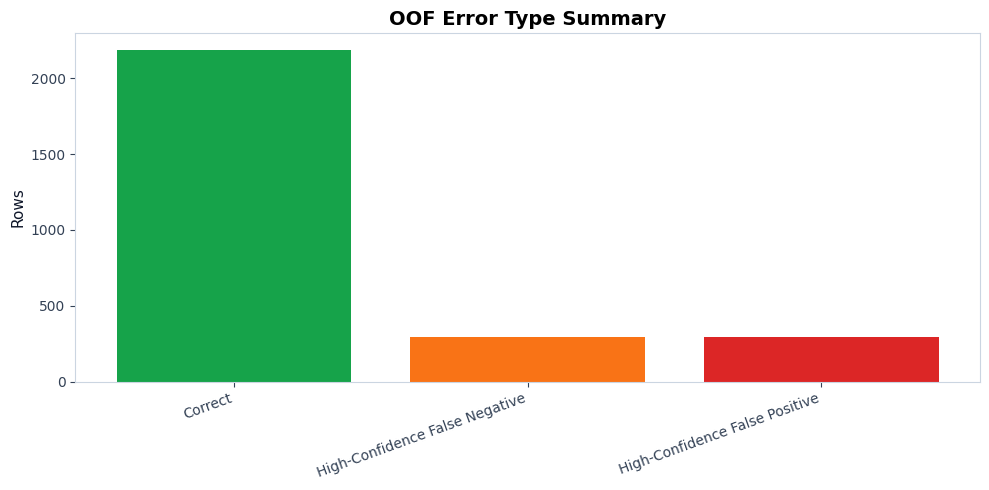

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))
color_map = {'Correct': COLORS['green'], 'High-Confidence False Positive': COLORS['red'], 'High-Confidence False Negative': COLORS['orange']}
ax.bar(error_summary['Error_Type'], error_summary['Count'], color=[color_map.get(v, COLORS['blue']) for v in error_summary['Error_Type']])
ax.set_title('OOF Error Type Summary')
ax.set_ylabel('Rows')
ax.set_xticklabels(error_summary['Error_Type'], rotation=20, ha='right')
plt.tight_layout()
plt.show()

**Insight**

The error tables reveal three practical patterns:

1. The model is more likely to miss on players with strong measurable athletic profiles who were not drafted.
2. The model can under-rank some drafted players when their measured profile is weaker or incomplete.
3. This is expected because the real draft decision also depends on film grade, injuries, team needs, interviews, role fit, off-field context, and scouting information that is not available in the tabular data.

This means the model is useful for ranking measurable draft likelihood, not for fully replicating the complete scouting decision.


## 19. Final Submission

The notebook creates one file only: `submission.csv`.

The file matches the sample submission columns and ID order. Predictions are probabilities between 0 and 1.

In [55]:
submission = sample_submission.copy()
submission[TARGET] = np.clip(final_test_pred, 0, 1)

if not submission[ID_COL].equals(sample_submission[ID_COL]):
    raise ValueError('Submission IDs do not match sample submission IDs.')
if list(submission.columns) != list(sample_submission.columns):
    raise ValueError('Submission columns do not match sample submission columns.')
if not submission[TARGET].between(0, 1).all():
    raise ValueError('Submission predictions must be between 0 and 1.')
if submission[TARGET].nunique() <= 5:
    raise ValueError('Submission predictions have too few unique values.')

for extra_file in ['submission_ranked_probability.csv', 'submission_binary.csv']:
    if os.path.exists(extra_file):
        os.remove(extra_file)

submission.to_csv('submission.csv', index=False)
print('Final submission file created: submission.csv')
print(f'Submission shape: {submission.shape}')
display(submission.head())

Final submission file created: submission.csv
Submission shape: (696, 2)


,Id,Drafted
0,2781,0.666602
1,2782,0.760884
2,2783,0.933373
3,2784,0.602782
4,2785,0.856018


**Insight**

Only one file is produced to avoid delivery confusion. The `Drafted` column contains probabilities because ROC-AUC depends on ranking quality.

### 19.1 Final Submission Distribution

This plot checks whether the final test probabilities have a useful spread.

A flat or nearly constant distribution would be a warning sign.

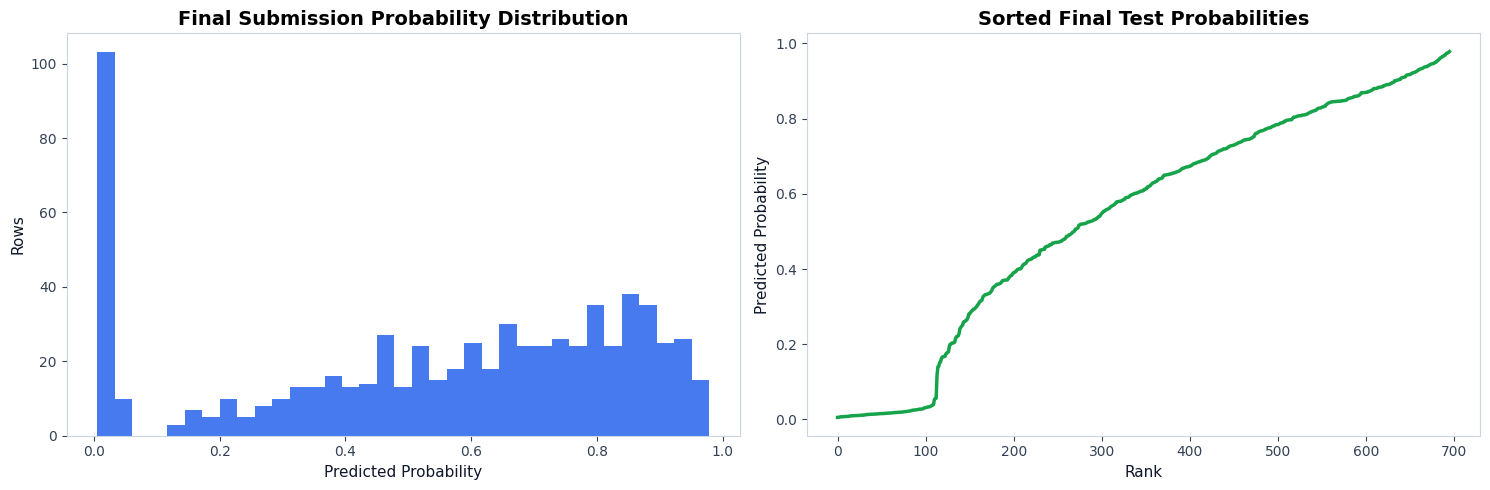

,Drafted_Probability
count,696.000000
mean,0.544841
std,0.303926
min,0.005212
25%,0.338362
50%,0.609640
75%,0.805754
max,0.978384


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(submission[TARGET], bins=35, color=COLORS['blue'], alpha=0.85)
axes[0].set_title('Final Submission Probability Distribution')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Rows')
axes[1].plot(np.sort(submission[TARGET].values), color=COLORS['green'], linewidth=2.5)
axes[1].set_title('Sorted Final Test Probabilities')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Predicted Probability')
plt.tight_layout()
plt.show()

submission_stats = submission[TARGET].describe().to_frame('Drafted_Probability')
display(submission_stats)

### 19.2 Submission Ranking Audit

The final file is evaluated by ranking quality.

This audit checks the shape of the final probabilities and the stability of the highest-ranked players.


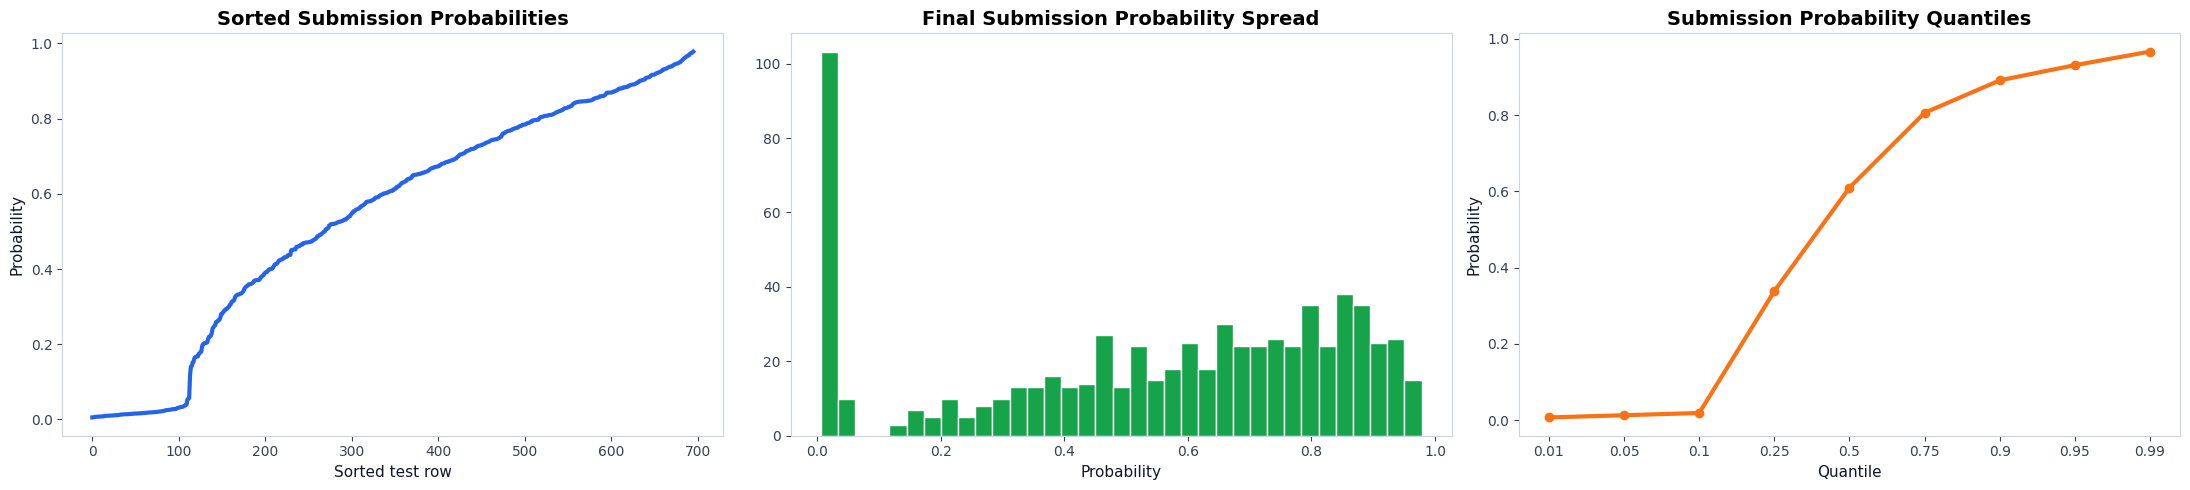

,Id,Drafted,Rank,Percentile
286,3067,0.978384,1.0,1.000000
566,3347,0.976219,2.0,0.998563
503,3284,0.974478,3.0,0.997126
403,3184,0.974229,4.0,0.995690
249,3030,0.972273,5.0,0.994253
350,3131,0.968608,6.0,0.992816
220,3001,0.967889,7.0,0.991379
454,3235,0.966092,8.0,0.989943
376,3157,0.965704,9.0,0.988506
375,3156,0.963167,10.0,0.987069


Insight: A useful ROC-AUC submission should preserve ranking spread. The final file keeps one probability column aligned to the sample submission contract.


In [57]:
submission_audit = submission.copy()
submission_audit['Rank'] = submission_audit[TARGET].rank(ascending=False, method='first')
submission_audit['Percentile'] = submission_audit[TARGET].rank(pct=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
axes[0].plot(np.sort(submission_audit[TARGET].values), color=COLORS['blue'], linewidth=3)
axes[0].set_title('Sorted Submission Probabilities')
axes[0].set_xlabel('Sorted test row')
axes[0].set_ylabel('Probability')

axes[1].hist(submission_audit[TARGET], bins=35, color=COLORS['green'], edgecolor='white')
axes[1].set_title('Final Submission Probability Spread')
axes[1].set_xlabel('Probability')

quantiles = submission_audit[TARGET].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
axes[2].plot(quantiles.index.astype(str), quantiles.values, marker='o', linewidth=3, color=COLORS['orange'])
axes[2].set_title('Submission Probability Quantiles')
axes[2].set_xlabel('Quantile')
axes[2].set_ylabel('Probability')

plt.tight_layout()
plt.show()

display(submission_audit.sort_values(TARGET, ascending=False).head(10))

print('Insight: A useful ROC-AUC submission should preserve ranking spread. The final file keeps one probability column aligned to the sample submission contract.')


**Insight**

A healthy submission should show ranked separation across test players. This supports ROC-AUC because the best candidates receive higher probabilities than weaker candidates.

## 20. Validation Safety and Score Discipline

This section explains the final modeling policy used in this notebook.

The workflow prioritizes a score that can be defended technically. Any transformation that learns from the data is fitted inside the training fold only. The final model is selected from OOF evidence, and the final output stays a single probability-based `submission.csv` file.


,Design area,Policy used in this notebook,Why it matters
0,Validation,5 folds x 3 repeats with averaged OOF predictions,Prevents lucky split decisions and repeated-CV...
1,Preprocessing,"Imputation, group statistics, ranks, encodings...",Prevents validation rows from influencing fitt...
2,Feature selection,Fold-local selection with final feature count ...,Reduces overfitting while keeping enough signa...
3,Stacking,Meta model receives OOF level 1 predictions an...,Prevents in-sample stacking inflation
4,Blend weights,Optimized using OOF predictions only,Keeps final model choice tied to validation ev...
5,Final submission,One probability file named submission.csv alig...,Avoids confusion during submission
6,Metric priority,"ROC-AUC first, accuracy second, calibration as...",Matches the ranking nature of the task


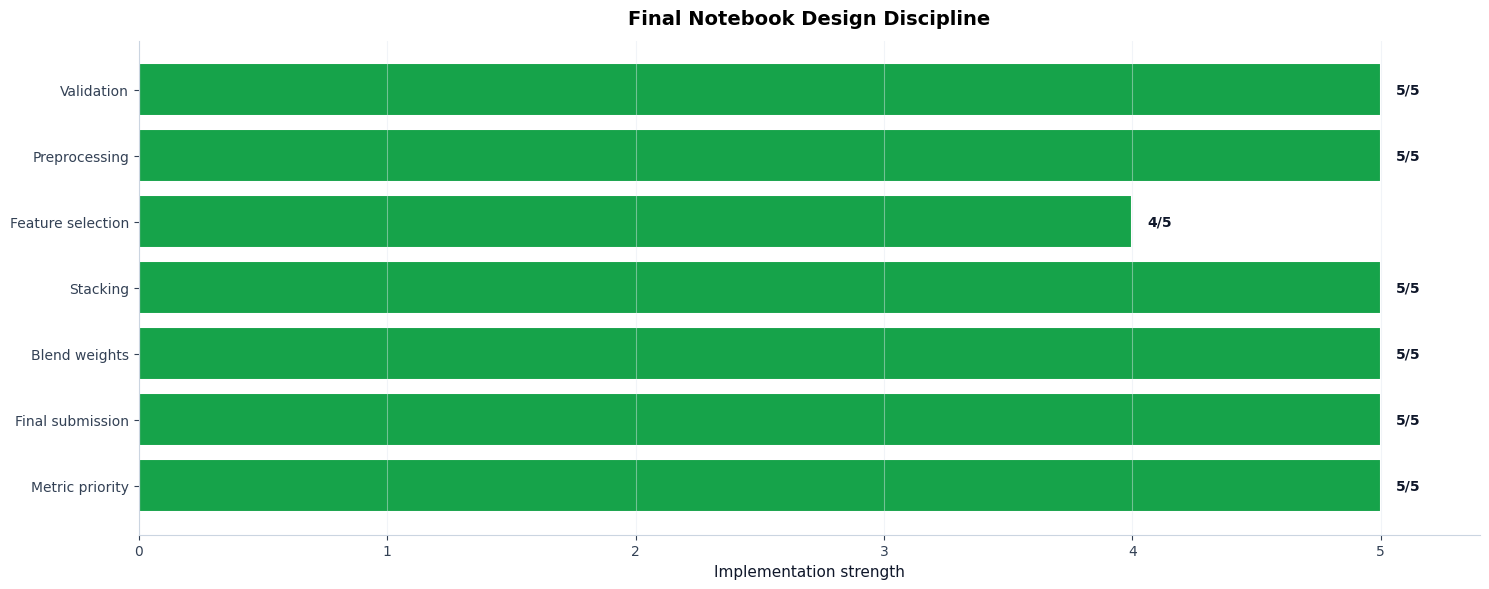

Insight: The notebook favors validation safety and traceable model selection. This reduces score inflation risk and makes the final result easier to defend in a technical review.


In [58]:
decision_policy = pd.DataFrame({
    'Design area': [
        'Validation',
        'Preprocessing',
        'Feature selection',
        'Stacking',
        'Blend weights',
        'Final submission',
        'Metric priority'
    ],
    'Policy used in this notebook': [
        f'{N_SPLITS} folds x {N_REPEATS} repeats with averaged OOF predictions',
        'Imputation, group statistics, ranks, encodings, scaling, and selection are fitted inside folds',
        'Fold-local selection with final feature count justified by OOF candidate performance',
        'Meta model receives OOF level 1 predictions and is evaluated through a separate OOF loop',
        'Optimized using OOF predictions only',
        'One probability file named submission.csv aligned to sample_submission',
        'ROC-AUC first, accuracy second, calibration as probability-quality audit'
    ],
    'Why it matters': [
        'Prevents lucky split decisions and repeated-CV overwrite bias',
        'Prevents validation rows from influencing fitted preprocessing',
        'Reduces overfitting while keeping enough signal for the ensemble',
        'Prevents in-sample stacking inflation',
        'Keeps final model choice tied to validation evidence',
        'Avoids confusion during submission',
        'Matches the ranking nature of the task'
    ]
})

display(decision_policy)

fig, ax = plt.subplots(figsize=(15, 6))
policy_strength = [5, 5, 4, 5, 5, 5, 5]
ax.barh(decision_policy['Design area'][::-1], policy_strength[::-1], color=COLORS['green'], edgecolor='white', linewidth=1.5)
style_axis(ax, 'Final Notebook Design Discipline', xlabel='Implementation strength')
ax.set_xlim(0, 5.4)
for i, value in enumerate(policy_strength[::-1]):
    ax.text(value + 0.06, i, f'{value}/5', va='center', fontweight='bold', color=COLORS['navy'])
plt.tight_layout()
plt.show()

print('Insight: The notebook favors validation safety and traceable model selection. This reduces score inflation risk and makes the final result easier to defend in a technical review.')


## 21. Final Decision Box

This section summarizes the selected final solution and explains why it was selected.

The final choice is not selected manually. It is selected by the highest OOF ROC-AUC among the candidate strategies built inside this notebook.

This matters because the competition metric rewards ranking quality, and OOF validation is the only safe way to compare ranking strategies before submission.


In [59]:
final_decision = pd.DataFrame({
    'Item': [
        'Best final strategy',
        'Final OOF ROC-AUC',
        'Base model count',
        'Repeated CV design',
        'Feature selection policy',
        'Target encoding policy',
        'Submission file',
        'Submission format'
    ],
    'Value': [
        final_choice_name,
        f'{final_oof_auc:.6f}',
        len(model_names),
        f'{N_SPLITS} folds x {N_REPEATS} repeats with averaged OOF predictions',
        f'Fold-local top {main_options.get("max_features")} selection',
        'Disabled in final config unless ablation proves value',
        'submission.csv',
        'Probability ranking aligned to sample submission'
    ]
})
display(final_decision)

,Item,Value
0,Best final strategy,NoLightGBMOptimizedBlend
1,Final OOF ROC-AUC,0.874653
2,Base model count,5
3,Repeated CV design,5 folds x 3 repeats with averaged OOF predictions
4,Feature selection policy,Fold-local top 120 selection
5,Target encoding policy,Disabled in final config unless ablation prove...
6,Submission file,submission.csv
7,Submission format,Probability ranking aligned to sample submission


**Insight**

The final version is selected because it combines score-focused validation, fold-safe preprocessing, controlled feature count, OOF-based blending, and a single clean submission file.

## 22. Runtime Summary

The final section records practical project details.

This helps another reviewer understand the scale of the workflow and reproduce the output.

In [60]:
runtime_seconds = time.time() - start_time
runtime_summary = pd.DataFrame({
    'Metric': [
        'Train rows',
        'Test rows',
        'Original train columns',
        'Original test columns',
        'Base models',
        'Validation folds used',
        'Final OOF ROC-AUC',
        'Submission rows',
        'Submission columns',
        'Runtime seconds'
    ],
    'Value': [
        len(train),
        len(test),
        train.shape[1],
        test.shape[1],
        len(model_names),
        N_SPLITS * N_REPEATS,
        f'{final_oof_auc:.6f}',
        submission.shape[0],
        submission.shape[1],
        f'{runtime_seconds:.1f}'
    ]
})
display(runtime_summary)

,Metric,Value
0,Train rows,2781
1,Test rows,696
2,Original train columns,16
3,Original test columns,15
4,Base models,5
5,Validation folds used,15
6,Final OOF ROC-AUC,0.874653
7,Submission rows,696
8,Submission columns,2
9,Runtime seconds,558.0


**Final Insight**

The workflow combines leakage-safe preprocessing, averaged repeated OOF predictions, fold-local feature selection, OOF-only blend selection, calibration diagnostics, drift checks, error analysis, and a single clean submission file.

The result is a complete modeling notebook that explains both performance and model behavior.
